# Train-Free Glioblastoma Segmentation in MRI with TDA
Anton François & Raphaël Tinarrage

Le git: https://github.com/antonfrancois/gliomaSegmentation_TDA

Les animations: https://www.youtube.com/playlist?list=PL_FkltNTtklAxtaMrQB5UCbobxRsiw8sE 

**Organization:**
- Example on image
- Batch images
- Images that satisfy the model
- Boxplots
- Study model

**Ideas:**
- Improve Step 1 with `max_tree` https://scikit-image.org/docs/stable/auto_examples/developers/plot_max_tree.html
- Refaire animation on 2D template
- $0$-$1$ normalization
- `suggest_t` on contour

# Functions

In [1]:
# TDA
import persim, cripser

# Image
import scipy, skimage
import matplotlib as mpl

# Anton
from parse_brats_for_raph import *
import nibabel as nib
import vedo

# Misc
import itertools
import pandas as pd
import glob, ast

# Comments
import sys, time, datetime

def ChronometerStart(msg='Start... '):
    start_time = time.time()
    sys.stdout.write(msg); sys.stdout.flush()
    return start_time
def ChronometerStop(start_time, method='ms', linebreak='\n'):
    elapsed_time_secs = time.time() - start_time
    if method == 'ms':
        msg = 'Execution time: '+repr(round(elapsed_time_secs*1000))+' ms.'+linebreak
    if method == 's':
        msg = 'Execution time: '+repr(round(elapsed_time_secs))+' s.'+linebreak
    sys.stdout.write(msg); sys.stdout.flush()    
def ChronometerTick(start_time, i, i_total, msg):    
    elapsed_time_secs = time.time() - start_time
    expected_time_secs = (i_total-i-1)/(i+1)*elapsed_time_secs
    msg1 = 'It '+repr(i+1)+'/'+repr(i_total)+'. '
    msg2 = 'Duration %s ' % datetime.timedelta(seconds=round(elapsed_time_secs))
    msg3 = 'Expected remaining time %s.' % datetime.timedelta(seconds=round(expected_time_secs))
    sys.stdout.write('\r'+msg+msg1+msg2+msg3)
    if i>=i_total-1: sys.stdout.write('\n')
        
''' FUNCTIONS TO PROCESS IMAGES '''

def argmax_image(img):
    return np.unravel_index(img.argmax(), img.shape)

def GetConnectedComponent(img, pos, t):
    '''
    Get the connected component of the voxel pos = (x,y,z) at time t.
    The output is a binary image.
    Background value of img must be 0 (as conventional).
    '''
    imt = (img>=t)*1
    if imt[pos[0],pos[1],pos[2]]==0: # The voxel pos is not active at time t
        CC = img*0
    else:    
        labels = skimage.measure.label(imt, background=0)
        labeltumor = labels[pos[0],pos[1],pos[2]]
        CC = (labels == labeltumor)*1
        if labeltumor==0: print('Problem! The label is background :(')
    return CC

def get_largest_CC(img, t, verbose=False):    
    if verbose: start_time = ChronometerStart('Get largest connected component... ')
    imgt = (img>=t)*1
    Labels = skimage.measure.label(imgt, background=0)
    nlabels = np.max(Labels)
    CardinalLabels = [0]+[np.sum(Labels==i) for i in range(1,nlabels)]
    ilabel = np.argmax(CardinalLabels)
    CC = (Labels==ilabel)*1    
    if verbose: ChronometerStop(start_time, method='s')
    return CC

def SEN(seg_1,seg_2, verbose=False):
    prod_seg = seg_1 * seg_2
    if seg_1.sum()==0: sen = 1
    else:              sen = prod_seg.sum() / seg_1.sum()
    return sen

def GetSensitivities(seg_1,seg_2, verbose=False):
    sens = {l:SEN((seg_1==l)*1, (seg_2==l)*1, verbose=False) for l in [1,2,4]}
    sens[0] = SEN((seg_1>0)*1, (seg_2>0)*1, verbose=False)
    return sens

def ACC(seg_1,seg_2, verbose=False):
    prod_seg = seg_1 * seg_2
    prod_seg_complement = (1-seg_1) * (1-seg_2)
    acc = (prod_seg.sum()+prod_seg_complement.sum())/np.prod(np.shape(seg_1))
    return acc

def GetAccuracies(seg_1,seg_2, verbose=False):
    accs = {l:ACC((seg_1==l)*1, (seg_2==l)*1, verbose=False) for l in [1,2,4]}
    accs[0] = ACC((seg_1>0)*1, (seg_2>0)*1, verbose=False)
    return accs

def DICE(seg_1,seg_2, verbose=False):
    prod_seg = seg_1 * seg_2
    sum_seg = seg_1 + seg_2
    if sum_seg.sum()==0: dice = 1
    else: dice = 2 * prod_seg.sum() / sum_seg.sum()
    if verbose:
        # Non-symmetric scores
        diceleft  = prod_seg.sum() / seg_1.sum()
        diceright = prod_seg.sum() / seg_2.sum()
        print('Sørensen–Dice coefficient: ',round(dice,3), round(diceleft,3), round(diceright,3))
    return dice

def GetDICEs(seg_1,seg_2, verbose=False):
    dices = {l:DICE((seg_1==l)*1, (seg_2==l)*1, verbose=False) for l in [1,2,4]}
    dices[0] = DICE((seg_1>0)*1, (seg_2>0)*1, verbose=False)
    if verbose: print('Sørensen–Dice coefficients:', {l:round(dices[l],3) for l in [1,2,4]})
    return dices 

def OpenBRATS(i,verbose=False):
    '''
    i must be between 0 and 1249 included
    '''
#     indices_BRATS2021 = list(range(707))+list(range(708,1089))+list(range(1090,1099))+list(range(1100,1253))
#         #images that I can open on my laptop
#     if i<0 or 1>=1250:
#         print('Error in OpenBRATS! i = ', i)
#         return None
#     else:    
#    n_image = indices_BRATS2021[i]

    n_image=i
    # Open t1ce
    pb = parse_brats(brats_list=None,brats_folder='2021',modality='t1ce')
    img_t1ce, _ = pb(n_image,to_torch=False)
    # Open flair
    pb = parse_brats(brats_list=None,brats_folder='2021',modality='flair')
    img_flair, seg_medecin = pb(n_image,to_torch=False)
    seg_medecin = seg_medecin.get_fdata()
    if verbose: print(pb.brats_list[n_image])
    return pb, img_flair, img_t1ce, seg_medecin
    
''' MAIN ALGORITHM '''

def Preprocess(img_flair,img_t1ce,sigma,normalize='max',do_enhance=[False,False],radius_ball=1):
    '''
    do_enhance can be True, False, or a list [True,True], [True, False], ...
    '''
    # Enhance image
    mask = (img_flair!=0)
    if do_enhance==True:
        img_flair = skimage.filters.rank.enhance_contrast(img_flair,footprint=skimage.morphology.ball(radius_ball), mask=mask)
        img_t1ce = skimage.filters.rank.enhance_contrast(img_t1ce,footprint=skimage.morphology.ball(radius_ball), mask=mask)
    elif do_enhance is not False:
        if do_enhance[0]:
            img_flair = skimage.filters.rank.enhance_contrast(img_flair,footprint=skimage.morphology.ball(radius_ball), mask=mask)
        if do_enhance[1]:
            img_t1ce = skimage.filters.rank.enhance_contrast(img_t1ce,footprint=skimage.morphology.ball(radius_ball), mask=mask)

    # Normalize images
    if normalize=='max':
        img_flair = img_flair/np.max(img_flair)
        img_t1ce = img_t1ce/np.max(img_t1ce)
    else:
        img_flair = img_flair/255
        img_t1ce = img_t1ce/255
    
    # N4 Bias Field Correction
    # see https://simpleitk.readthedocs.io/en/master/link_N4BiasFieldCorrection_docs.html
    
    # Gaussian smoothing
    if sigma>0:
        img_flair = scipy.ndimage.gaussian_filter(img_flair, sigma=sigma)    
        img_t1ce = scipy.ndimage.gaussian_filter(img_t1ce, sigma=sigma)
            
    return img_flair, img_t1ce

def suggest_t(img, N=100, dt_threshold=1, seg_medecin=None, verbose=False, plot=False):
    T = np.linspace(0,1,N)

    # Build suggestion curve
    if verbose: start_time = ChronometerStart('Suggest t... ')
    S = np.array([np.sum(img>t) for t in T])
    S_dt = (S[:-1] - S[1:])                #finite differences
    S_dt_norm = S_dt*len(S_dt)/S_dt.sum()  #S_dt_norm has integral 1, i.e., np.sum(S_dt_norm)/len(S_dt) = 1
    if verbose: ChronometerStop(start_time, method='s')
        
    # Find optimal t
    best_i = np.where(S_dt_norm>dt_threshold)[0][-1] #last value for which S_dt_norm>dt_threshold
    best_t = T[best_i+1]

    if plot:
        fig, ax = plt.subplots(1, 1, figsize = (8,2))
        plt.plot(T,S/np.max(S)*np.max(S_dt_norm),c='black', label='_nolegend_')
        plt.plot(T[0:-1],S_dt_norm, c='black', label='_nolegend_')
        plt.scatter(T[0:-1],S_dt_norm,c='black',s=10, label='_nolegend_')
        plt.axhline(dt_threshold, c='blue', label='dt_threshold') 
        plt.axvline(best_t, c='pink', label='best t')
        if seg_medecin is not None:
            groundtruth_t = np.min(img[seg_medecin>0])
            plt.axvline(groundtruth_t, c='red', label='groundtruth t')
        plt.ylim(0,np.max(S_dt_norm[1::])*1.1)
        plt.title('Suggest t, dt_threshold = '+repr(dt_threshold)); plt.legend(); plt.show()

    return best_t

def Step1(img_flair,seg_medecin=None,method='suggest_t',dt_threshold=1,verbose=True,plot=True):
    '''
    method can be 'suggest_t', 'medecin' or 'medecin_hull'
    '''        
    if method=='suggest_t':
        # Find best t
        t = suggest_t(img_flair, dt_threshold=dt_threshold, seg_medecin=seg_medecin, verbose=verbose, plot=plot)

        # Extract CC
        seg_union = get_largest_CC(img_flair, t, verbose=verbose)

        # Fill CC with holes
        if verbose: start_time = ChronometerStart('Fill the holes... ')
        seg_union = scipy.ndimage.binary_fill_holes(seg_union)
        if verbose: ChronometerStop(start_time, method='s')
            
        # Smooth via binary closing
        iterations = 0
        if iterations>0: seg_union = scipy.ndimage.morphology.binary_closing(seg_union, iterations=iterations)

    elif method=='medecin': seg_union = (seg_medecin>0)*1

    elif method=='medecin_hull': 
        # Take convex hull of seg_union
        seg_union = (seg_medecin>0)*1
        if verbose: start_time = ChronometerStart('Take convex hull... ')
        seg_union = (seg_medecin>0)*1
        seg_union = skimage.morphology.convex_hull_image(seg_union)
        seg_union = seg_union*1
        if verbose: ChronometerStop(start_time, method='s')

    return seg_union

# def Step2(img_t1ce,seg_union,H2_features_max=5,verbose=True,plot=True):
#     # Compute PH2
#     if verbose: start_time = ChronometerStart('Compute diagram... ')
#     seg_union_t1ce = img_t1ce*seg_union
#     barcode = cripser.computePH(1-seg_union_t1ce,maxdim=3) # Compute diagram
#     H2 = [list(bar[1::]) for bar in barcode if bar[0]==2 and bar[2]<1] # Only non-infinite bars
#     H2 = [bar for _,bar in sorted(zip([bar[1]-bar[0] for bar in H2],H2))[::-1]] # Sort list H2 by persistence
#     if verbose: ChronometerStop(start_time, method='s')
        
#     if verbose: print('H2 diagram:', H2[0:H2_features_max])

#     # If empty diagram
#     if len(H2)==0: return seg_union_t1ce*0
        
#     # Plot diagram
#     if plot:
#         fig, ax = plt.subplots(1,1, figsize=(4,4))
#         persim.plot_diagrams([np.array([barcode[0][1:3]]), np.array([barcode[0][1:3]]), np.array([bar[1:3] for bar in barcode if bar[0]==3-1])])
#         plt.title('Persistence diagram of t1ce segmented',fontsize=10)

#     # Compute width of the holes of H2-features
#     i_max = min(H2_features_max,len(H2)) #number of top bars to parse
#     length_holes = []
#     for i in range(i_max):
#         bar = H2[i]
#         pos = np.array(bar[2:5]).astype(int)
#         t = bar[0]+0.0001
#         seg_contour = GetConnectedComponent(seg_union_t1ce, pos, 1-t)
#         seg_contour_filled = scipy.ndimage.binary_fill_holes(seg_contour)
#         length_holes.append( np.sum(seg_contour_filled-seg_contour) )
#     if verbose: print('Width of the holes:', {i:length_holes[i] for i in range(i_max)})
    
#     # Select the largest hole
#     i = np.argmax(length_holes)
#     bar = H2[i]
#     pos = np.array(bar[2:5]).astype(int)
#     t = bar[0]+0.0001
#     seg_contour = GetConnectedComponent(seg_union_t1ce, pos, 1-t)

#     # Plot
#     if plot: patch = plt.Circle((bar[0],bar[1]), 0.01,fill=False); ax.add_patch(patch)
#     return seg_contour

# def Step3(seg_union, seg_contour, alpha_boundary=.85,verbose=True):               
#     # 3rd step: - Classify components
#         # 1 - RED, TC  -> NECROSE INACTIVE, TUMORUS CORE
#         # 2 - BLUE, ED -> INFILTRATION, OEDEME
#         # 4 - ORANGE, ET -> NECROSE ACTIVE, ENHANCING TUMOR
#     seg_union_nocontour = seg_union - seg_contour
#     seg_nocontour_components = []
#     labels = skimage.measure.label(seg_union_nocontour, background=0)

#     N = 0 # select components with cardinal at least N
#     components = [(labels==i)*1 for i in range(1,np.max(labels)+1)]
#     components = [component for component in components if np.sum(component)>N]

#     # Classify components: TC or WT
#     seg_final = seg_contour.copy()*4 # define seg_final
#     for component in components:
#         componentdilated = scipy.ndimage.binary_dilation(component,iterations=1)
#         componentcontour = componentdilated - component
#         meanvalue = np.mean(seg_contour[np.where(componentcontour>0)])
#         if meanvalue<alpha_boundary: #sort du masque Segmentation, label 2
#             seg_final[component>0] = 2
#         else: #label 1
#             seg_final[component>0] = 1
            
#     return seg_final

''' FUNCTIONS TO PLOT '''

from matplotlib.colors import ListedColormap

# Own colormap for segmentations
cmap_segs = ListedColormap([[0,0,0,0],'tab:red','tab:blue','tab:orange'])
DLT_KW_IMAGE = dict(cmap='gray',origin='lower',vmin=0,vmax=1)
DLT_KW_SEG= dict(cmap=cmap_segs,interpolation='nearest',origin='lower')
                 
def make_3d_flat(img_3D,pos):
    ''' 
    Take a 'brain' 3D image, take 3 slices and make a long 2D image of it.
    '''
    crop = 20 #parameter
    # Cut slices
    D,H,W = img_3D.shape
    im0 = img_3D[:,:,pos[2]].T #image_slice(img_3D,slice[2],2).T
    im1 = img_3D[:,pos[1],:].T#image_slice(img_3D,slice[1],1).T
    im2 = img_3D[pos[0],:,:].T#image_slice(img_3D,slice[0],0).T
    # Crop and pad slices
    long_img = np.zeros((D,D+H+H-int(3.5*crop)))
    long_img[:D,:D-crop] = im0[:,crop//2:-crop//2]
    long_img[(D-W)//2:(D-W)//2 + W,D-int(1.7*crop):D+H-int(2.7*crop)] = im1[::-1,crop//2:-crop//2]
    long_img[(D-W)//2:(D-W)//2 + W,D+H-int(3*crop):] = im2[::-1,crop//2:]
    return long_img

def PlotSegmentation(pb,img,seg=None,pos=None,figsize=(15,5)):
    if pos is None: pos = argmax_image(img_flair)
    fig = plt.figure(figsize=figsize); ax = fig.add_subplot(1,1,1)
    ax.imshow(make_3d_flat(img,pos),cmap='gray',alpha=0.5,origin='upper')
    if seg is None: seg = img*0
    ax.imshow(make_3d_flat(seg,pos),**DLT_KW_SEG)
    ax.text(235,15,pb.brats_list[i],c='white',fontsize=20)
    plt.axis('off')
    
def PlotSuperlevelSets(image, pos=None, Times=None):
    if Times==None: Times = [0,0.05,0.3,0.5,1]

    if pos==None: 
        if image[0,0,0]==0: pos = argmax_image(image)
        else: pos = argmax_image(1-image)
    im = image[:,:,pos[2]]

    fig = plt.figure(figsize=(15,15)) # Notice the equal aspect ratio
    ax = [fig.add_subplot(1,len(Times),i+1) for i in range(len(Times))]
    ax.reverse()
    for i in range(len(Times)):
        t = Times[i]
        imt = np.zeros(np.shape(im)); imt[im<t] = 1; imt[im>=t] = 0
        ax[i].imshow(imt,origin='lower',vmin=0,vmax=1,cmap='gray')
        ax[i].set_title('t = '+repr(Times[::-1][i]), fontsize=17.5); 
        ax[i].axis('off'); ax[i].set_aspect('equal')
    fig.subplots_adjust(wspace=0.05, hspace=0)
    
def PlotSublevelSets(image, pos=None, Times=None):
    if Times==None: Times = [0,0.05,0.3,0.5,1]

    if pos==None: 
        if image[0,0,0]==0: pos = argmax_image(image)
        else: pos = argmax_image(1-image)
    im = image[:,:,pos[2]]

    fig = plt.figure(figsize=(15,15)) # Notice the equal aspect ratio
    ax = [fig.add_subplot(1,len(Times),i+1) for i in range(len(Times))]
    for i in range(len(Times)):
        t = Times[i]
        imt = np.zeros(np.shape(im)); imt[im>t] = 1; imt[im<=t] = 0
        ax[i].imshow(imt,origin='lower',vmin=0,vmax=1,cmap='gray')
        ax[i].set_title('t = '+repr(t), fontsize=17.5); 
        ax[i].axis('off'); ax[i].set_aspect('equal')
    fig.subplots_adjust(wspace=0.05, hspace=0)    
    
def BoxplotSegmentation(dic, suptitle=None):
    Titles = ['WT', 'TC', 'ED', 'ET']
    Labels = [0,1,2,4]
    DICEs_list = list(dic.values())

    plt.figure(figsize =(4*4, 2),constrained_layout=True)
    for k in range(len(Labels)):
        label = Labels[k]
        scores = [dic[i][label] for i in dic]
        ax = plt.subplot(1,len(Labels),k+1)
        ax.boxplot(scores, showmeans=True, notch = True)
        title = Titles[k]+', mean='+repr(round(np.mean(scores),2))+', med='+repr(round(np.median(scores),2))
        ax.title.set_text(title)
        ax.set_ylim(-0.01,1)
    if suptitle is not None: plt.suptitle(suptitle)

In [2]:
' New functions (Step2 and Step 3) - 06/10/2023'

# def Step2_variation(img_t1ce,seg_union,H2_features_max=5,verbose=True,plot=True):
def Step2(img_t1ce,seg_union,H2_features_max=5,verbose=True,plot=True):
    # Compute PH2
    if verbose: start_time = ChronometerStart('Compute diagram... ')
    seg_union_t1ce = img_t1ce*seg_union
    barcode = cripser.computePH(1-seg_union_t1ce,maxdim=3) # Compute diagram
    H2 = [list(bar[1::]) for bar in barcode if bar[0]==2 and bar[2]<1] # Only non-infinite bars
    H2 = [bar for _,bar in sorted(zip([bar[1]-bar[0] for bar in H2],H2))[::-1]] # Sort list H2 by persistence
    if verbose: ChronometerStop(start_time, method='s')
        
    if verbose: print('H2 diagram:', H2[0:H2_features_max])

    # If empty diagram
    if len(H2)==0: return seg_union_t1ce*0
        
    # Plot diagram
    if plot:
        fig, ax = plt.subplots(1,1, figsize=(4,4))
        persim.plot_diagrams([np.array([barcode[0][1:3]]), np.array([barcode[0][1:3]]), np.array([bar[1:3] for bar in barcode if bar[0]==3-1])])
        plt.title('Persistence diagram of t1ce segmented',fontsize=10)

    # Compute width of the holes of H2-features
    i_max = min(H2_features_max,len(H2)) #number of top bars to parse
    length_holes = []
    for i in range(i_max):
        # Get H2-cycle
        bar = H2[i]
        pos = np.array(bar[2:5]).astype(int)
        t = bar[0]+0.0001
        seg_contour = GetConnectedComponent(seg_union_t1ce, pos, 1-t)
        
        # Identify inside voxels
        seg_complement = 1 - seg_contour
        labels = skimage.measure.label(seg_complement, background=0)
        components = [(labels==i)*1 for i in range(1,np.max(labels)+1)]
        components_len = [np.sum(component) for component in components]

        imax_comp = np.argmax(components_len)
        components.pop(imax_comp) #remove ED (background) from components
        
        length_holes.append( np.sum( [np.sum(component) for component in components] ) )
    if verbose: print('Width of the holes:', {i:length_holes[i] for i in range(i_max)})
    
    # Select the largest hole
    i = np.argmax(length_holes)
    bar = H2[i]
    pos = np.array(bar[2:5]).astype(int)
    t = bar[0]+0.0001
    seg_contour = GetConnectedComponent(seg_union_t1ce, pos, 1-t)

    # Plot
    if plot: patch = plt.Circle((bar[0],bar[1]), 0.01,fill=False); ax.add_patch(patch)
    return seg_contour

#def Step3_variation(seg_union, seg_contour,verbose=True):               
def Step3(seg_union, seg_contour,verbose=True):               
    # 3rd step: - Classify components
        # 1 - RED, TC  -> NECROSE INACTIVE, TUMORUS CORE
        # 2 - BLUE, ED -> INFILTRATION, OEDEME
        # 4 - ORANGE, ET -> NECROSE ACTIVE, ENHANCING TUMOR
    seg_complement = 1 - seg_contour
    labels = skimage.measure.label(seg_complement, background=0)

    components = [(labels==i)*1 for i in range(1,np.max(labels)+1)]
    components_len = [np.sum(component) for component in components]
    imax_comp = np.argmax(components_len)
    
    # Classify components: TC or WT
    seg_final = seg_contour.copy()*4                        #define seg_final
    seg_final[(components[imax_comp]*seg_union)>0] = 2      #add ED
    components.pop(imax_comp)                               #remove ED (background) from components
    for component in components: seg_final[component>0] = 1 #add TC
                
    return seg_final

# 20231221 New verify model (sphere-shaped) - new figures article

In [78]:
' Benchmark - Verification of the model '

dilatation = 0
do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur

# VerifyModel = dict()
pb = parse_brats(brats_list=None,brats_folder='2021',modality='flair')
i_list = range(len(pb.brats_list))

# dilatation_3D_totest = range(0,2+1)
# dilatation_3D_totest = range(0,3+1)
dilatation_3D_totest = range(0,4+1)
RatioComponentsWidth = {dilatation_3D:dict() for dilatation_3D in dilatation_3D_totest}


msg = 'Verify model... '
start_time = ChronometerStart(msg)
for i in i_list:
    for dilatation_3D in dilatation_3D_totest:
        # Open image
        pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)

        # Get segmentation classes
        seg_TC = (seg_medecin==1)*1 #TC
        seg_ED = (seg_medecin==2)*1 #ED
        seg_ET = (seg_medecin==4)*1 #ET
        seg_WT = (seg_medecin>0)*1  #WT    

        # Dilate 3D
    #     dilatation_3D = 2
        if dilatation_3D>0: 
            seg_ET = skimage.morphology.binary_dilation(seg_ET, footprint=skimage.morphology.ball(dilatation_3D))
            seg_TC_erode = skimage.morphology.binary_erosion(seg_TC, footprint=skimage.morphology.ball(dilatation_3D))

        # Verify model
        seg_complement = 1 - seg_ET
        labels = skimage.measure.label(seg_complement, background=0)
        components = [(labels==j)*1 for j in range(1,np.max(labels)+1)]  # Remove ET
        components_len = [np.sum(component) for component in components]
        components_len.pop(np.argmax(components_len))                    # Remove background (contains ED)
        inner_components_len = sum(components_len)

        if np.sum(seg_TC_erode)>0: RatioComponentsWidth[dilatation_3D][i] = inner_components_len/np.sum(seg_TC_erode)
        else:                      RatioComponentsWidth[dilatation_3D][i] = np.nan

    ChronometerTick(start_time, i, len(i_list), msg)       
        
# # Gather results
# df = pd.DataFrame.from_dict(VerifyModel, orient='index')
# df.to_csv('results/VerifyModel_dilatation'+str(dilatation)+'_len'+repr(len(df))+'.csv')

Verify model... It 1251/1251. Duration 4:34:06 Expected remaining time 0:00:00.


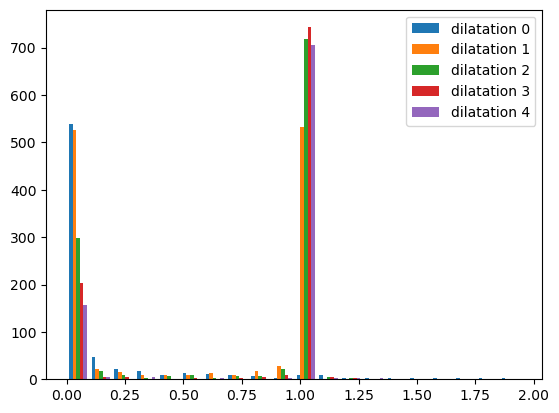

In [80]:
# Plot 
values = [list(RatioComponentsWidth[dilatation_3D].values()) for dilatation_3D in dilatation_3D_totest]
values = [[v for v in val if v<2] for val in values]
plt.hist(values,20)
plt.legend(['dilatation '+repr(dilatation_3D) for dilatation_3D in dilatation_3D_totest]);

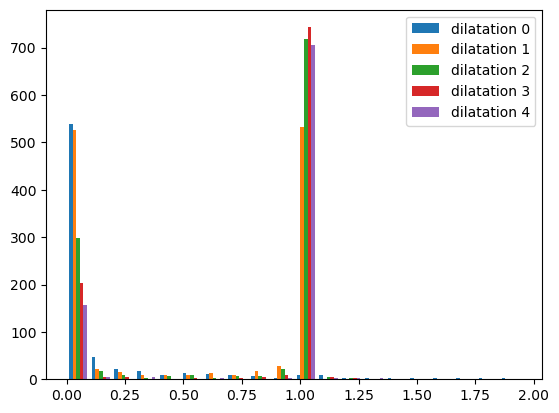

In [153]:
' Benchmark - Get argmax in FLAIR and T1ce '

do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur

pb = parse_brats(brats_list=None,brats_folder='2021',modality='flair')
i_list = range(len(pb.brats_list))

dilatation_3D_totest = range(0,4+1)
argmax_FLAIR = dict()
argmax_T1ce  = dict()

msg = 'Verify model... '
start_time = ChronometerStart(msg)
for i in i_list:
    # Open image
    pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
    img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma,normalize,do_enhance)
        
    # Verify if argmax is in ET (should be 1 for ET, >0 for WT)
    argmax_FLAIR[i] = seg_medecin[argmax_image(img_flair)]      
    argmax_T1ce[i]  = seg_medecin[argmax_image( img_t1ce*(seg_medecin>0) )]      

    ChronometerTick(start_time, i, len(i_list), msg)

Verify model... It 1251/1251. Duration 0:19:17 Expected remaining time 0:00:00.


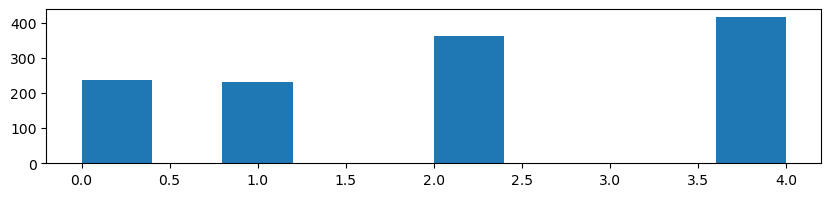

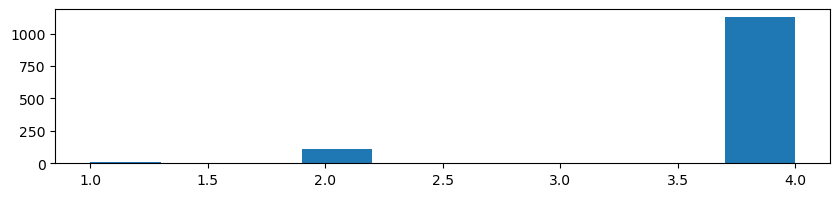

In [194]:
plt.figure(figsize=(10,2)); plt.hist(argmax_FLAIR.values())
plt.figure(figsize=(10,2)); plt.hist(argmax_T1ce.values());

Found results/TDAseg_scores_[False, 'max', 1, 1, 1, None, 3]_len1251.csv
Brains satisfying the model: 390 = 31.175 %
WT - TDA - whole dataset:     $0.711\pm0.283$, median 0.827
WT - U-net - whole dataset:   $0.868\pm0.123$, median 0.906
WT - TDA - model satisfied:   $0.788\pm0.229$, median 0.873
WT - U-net - model satisfied: $0.9\pm0.08$, median 0.924
TC - TDA - whole dataset:     $0.369\pm0.358$, median 0.28
TC - U-net - whole dataset:   $0.73\pm0.282$, median 0.85
TC - TDA - model satisfied:   $0.591\pm0.317$, median 0.717
TC - U-net - model satisfied: $0.874\pm0.13$, median 0.917
ED - TDA - whole dataset:     $0.477\pm0.306$, median 0.538
ED - U-net - whole dataset:   $0.821\pm0.154$, median 0.872
ED - TDA - model satisfied:   $0.612\pm0.267$, median 0.713
ED - U-net - model satisfied: $0.842\pm0.133$, median 0.882
ET - TDA - whole dataset:     $0.457\pm0.305$, median 0.498
ET - U-net - whole dataset:   $0.815\pm0.202$, median 0.88
ET - TDA - model satisfied:   $0.658\pm0.241$, medi

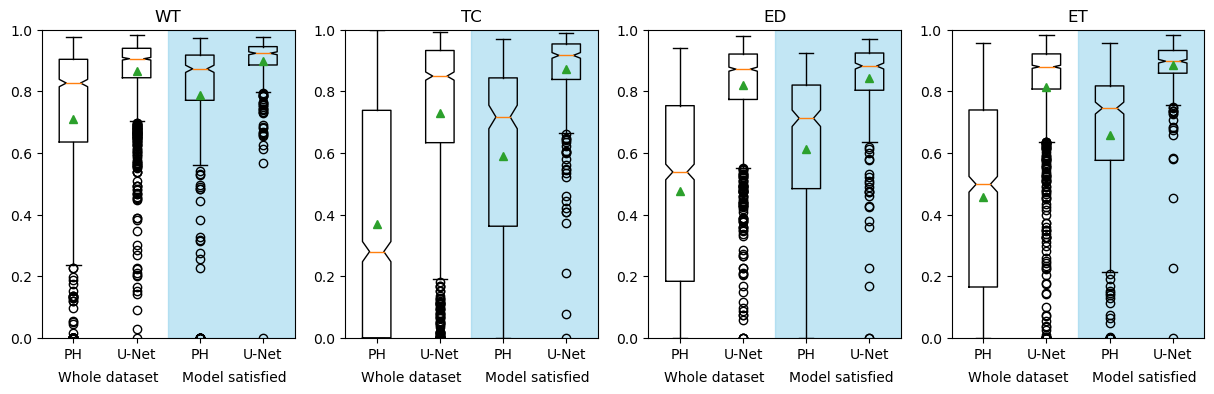

In [197]:
' Visualize new scores '

' Open dataframe '

# Open our segmentations

do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur
dt_threshold = 1       # Step 1, threshold for suggest_t
H2_features_max = 1    # Step 2, number of H2 bars to consider
alpha_boundary = None  # Step 3, parameter to consider inside/outside
radius_ball = 3        # Step 2, dilation parameter

parameters = [do_enhance,normalize,sigma,dt_threshold,H2_features_max,alpha_boundary,radius_ball]
files = glob.glob('results/TDAseg_scores_*')
files = [file for file in files if file[0:len('results/TDAseg_scores_')+len(str(parameters))]=='results/TDAseg_scores_'+str(parameters)]
files_length = [int(file[len('results/TDAseg_scores_')+len(str(parameters))+4:-4]) for file in files]
ind = np.argmax(files_length)
file, i_min = files[ind], files_length[ind]
print('Found', file)
df_parameters1 = pd.read_csv(file)
    
# Open U-net

df_parameters2 = pd.read_csv('results/summary_cmp_unet_pp.csv')
names = {name:True for name in df_parameters1['brats_name']}
    
' Open model '    
    
# Model 1

# thresh_score = 0.0           # lower bound on the scores
# thresh_smallTC = 50          # upper bound on the ratio WT/TC, which should be small
# thresh_WTconnected = 10      # lower bound on the ratio first/second largest CC, should be high
# admissible_argmax = [4]      # seg values that argmax can take ([1] for TC, [1,2,4] for WT)

thresh_score = 0.0           # lower bound on the scores
thresh_smallTC = 50          # upper bound on the ratio WT/TC, which should be small
thresh_WTconnected = 10      # lower bound on the ratio first/second largest CC, should be high
# admissible_argmax = [1,2,4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT) in FLAIR
admissible_argmax_FLAIR = [1,4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT) in FLAIR
admissible_argmax_T1ce = [4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT) in FLAIR


df_VerifyModel = pd.read_csv('results/VerifyModel_20231114_dilation3_len1251.csv')
names_verify_model = {name:False for name in df_VerifyModel['brats_name']}
for i in range(len(df_VerifyModel)):
    names_verify_model[df_VerifyModel['brats_name'][i]] =                                             \
                           (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>=thresh_score) \
                       and df_VerifyModel['nonempty'][i]==True                                        \
                       and df_VerifyModel['smallTC'][i]<=thresh_smallTC                               \
                       and df_VerifyModel['WTconnected'][i]>=thresh_WTconnected                       \
                       and df_VerifyModel['boundary_TC'][i] > 0.5 \
                       and df_VerifyModel['boundary_ET'][i] < 0.5 \
                       and RatioComponentsWidth[radius_ball][i]>=1 \
                       and argmax_FLAIR[i] in admissible_argmax_FLAIR \
                       and argmax_T1ce[i]  in admissible_argmax_T1ce \
#                        and df_VerifyModel['mean_ET_t1ce'][i] > 1.2*max(df_VerifyModel['mean_TC_t1ce'][i],df_VerifyModel['mean_ED_t1ce'][i])
#                        and df_VerifyModel['argmax'][i] in admissible_argmax \
                         
#df_VerifyModel['argmax'] refers to ARGMAX IN FLAIR    
    
print('Brains satisfying the model:' , np.sum(list(names_verify_model.values())), '=', \
      round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel)*100,3), '%')
    
# # Model 2

# thresh_score = 0.0           # lower bound on the scores
# thresh_smallTC = 50          # upper bound on the ratio WT/TC, which should be small
# thresh_WTconnected = 10      # lower bound on the ratio first/second largest CC, should be high
# admissible_argmax = [0,4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT)

# df_VerifyModel = pd.read_csv('results/VerifyModel_20231114_dilation3_len1251.csv')
# names_verify_model = {name:False for name in df_VerifyModel['brats_name']}
# for i in range(len(df_VerifyModel)):
#     names_verify_model[df_VerifyModel['brats_name'][i]] =                                             \
#                            (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>thresh_score) \
#                        and df_VerifyModel['nonempty'][i]==True                                        \
#                        and df_VerifyModel['smallTC'][i]<=thresh_smallTC                               \
#                        and df_VerifyModel['WTconnected'][i]>=thresh_WTconnected                       \
#                        and df_VerifyModel['argmax'][i] in admissible_argmax \
#                        and df_VerifyModel['boundary_TC'][i] > 0.75 \
#                        and df_VerifyModel['boundary_ET'][i] < 0.5 
# print('Brains satisfying the model:' , np.sum(list(names_verify_model.values())), '=', \
#       round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel)*100,3), '%')
    
' Plot '

import matplotlib.patches

fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(15, 4))
segmentation_labels = ['WT','TC','ED','ET']
for label_i, label in enumerate(segmentation_labels):
    seg_1       = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))
                                     if names[df_parameters1['brats_name'][i]]]
    seg_2       = [df_parameters2.iloc[i][label+'_unet'] for i in range(len(df_parameters2)) \
                                     if names[df_parameters2['brats_name'][i]]]
    seg_1_model = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))    \
                                     if names[df_parameters1['brats_name'][i]]            \
                                    and names_verify_model[df_parameters1['brats_name'][i]] ]
    seg_2_model = [df_parameters2.iloc[i][label+'_unet'] for i in range(len(df_parameters2))      \
                                     if names[df_parameters2['brats_name'][i]]            \
                                    and names_verify_model[df_parameters2['brats_name'][i]] ]
    
    axs[label_i].boxplot([seg_1,seg_2,seg_1_model,seg_2_model], notch=True, showmeans=True);
    axs[label_i].set_title(label)
    axs[label_i].set_ylim(0,1); 
    axs[label_i].set_xlim(0.5,4.5)
    axs[label_i].set_xticklabels(['PH','U-Net','PH', 'U-Net'])
    axs[label_i].set_yticks([0,0.2,0.4,0.6,0.8,1])
#     if label_i in [0,2]: 
#         axs[label_i].yaxis.tick_right()
#         axs[label_i].set_yticklabels([])
    axs[label_i].add_patch(matplotlib.patches.Rectangle((2.5, 0), 2.5, 1,color='skyblue',alpha=0.5))
    axs[label_i].text(1.55, -0.15, 'Whole dataset', horizontalalignment='center', verticalalignment='bottom')
    axs[label_i].text(3.55, -0.15, 'Model satisfied', horizontalalignment='center', verticalalignment='bottom')
    
    # Print scores
    for i_seg, seg in enumerate([seg_1,seg_2,seg_1_model,seg_2_model]):
        msg = '$'+repr(round(np.mean(seg),3))+"\\"+'pm'+repr(round(np.std(seg),3))+'$, median '+repr(round(np.median(seg),3))
        if i_seg==0:   msg = label+' - TDA - whole dataset:     '    +msg
        elif i_seg==1: msg = label+' - U-net - whole dataset:   '    +msg
        elif i_seg==2: msg = label+' - TDA - model satisfied:   '    +msg
        elif i_seg==3: msg = label+' - U-net - model satisfied: '    +msg
        print(msg)
        
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2, hspace=0)
plt.savefig("results/scores_BraTS_article_20231221.pdf", format="pdf", bbox_inches="tight");

In [198]:
' Print compare with U-net '

better_at_least_once = [False for i in range(len(seg_2_model))]

segmentation_labels = ['WT','TC','ED','ET']
for label_i, label in enumerate(segmentation_labels):
    seg_1_model = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))    \
                                     if names[df_parameters1['brats_name'][i]]            \
                                    and names_verify_model[df_parameters1['brats_name'][i]] ]
    seg_2_model = [df_parameters2.iloc[i][label+'_unet'] for i in range(len(df_parameters2))      \
                                     if names[df_parameters2['brats_name'][i]]            \
                                    and names_verify_model[df_parameters2['brats_name'][i]] ]
    for i in range(len(seg_2_model)):
        if seg_1_model[i]>=seg_2_model[i]:
            better_at_least_once[i] = True
    count = sum([seg_1_model[i]>=seg_2_model[i] for i in range(len(seg_2_model))])
    print(label, '- TDA outperfroms U-Net', count, 'times')

count = sum(better_at_least_once)
print('At least once, TDA outperfroms U-Net', count, 'times out of', len(seg_2_model), 'i.e.', repr(round(count/len(seg_2_model)*100,2))+'%')

WT - TDA outperfroms U-Net 100 times
TC - TDA outperfroms U-Net 61 times
ED - TDA outperfroms U-Net 63 times
ET - TDA outperfroms U-Net 38 times
At least once, TDA outperfroms U-Net 147 times out of 389 i.e. 37.79%


NEW:

OLD:
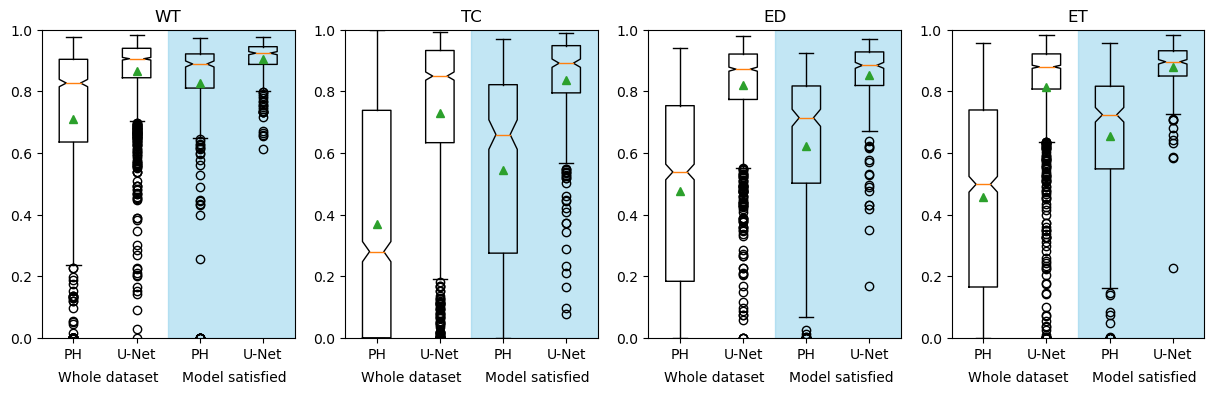

# Scores for article (old, see above for most recent)

Found results/TDAseg_scores_[False, 'max', 1, 1, 1, None, 3]_len1251.csv
Brains satisfying the model: 319 = 25.5 %
WT - TDA - whole dataset:     $0.711\pm0.283$, median 0.827
WT - U-net - whole dataset:   $0.868\pm0.123$, median 0.906
WT - TDA - model satisfied:   $0.827\pm0.182$, median 0.889
WT - U-net - model satisfied: $0.905\pm0.061$, median 0.924
TC - TDA - whole dataset:     $0.369\pm0.358$, median 0.28
TC - U-net - whole dataset:   $0.73\pm0.282$, median 0.85
TC - TDA - model satisfied:   $0.546\pm0.323$, median 0.66
TC - U-net - model satisfied: $0.838\pm0.162$, median 0.892
ED - TDA - whole dataset:     $0.477\pm0.306$, median 0.538
ED - U-net - whole dataset:   $0.821\pm0.154$, median 0.872
ED - TDA - model satisfied:   $0.623\pm0.25$, median 0.714
ED - U-net - model satisfied: $0.854\pm0.109$, median 0.885
ET - TDA - whole dataset:     $0.457\pm0.305$, median 0.498
ET - U-net - whole dataset:   $0.815\pm0.202$, median 0.88
ET - TDA - model satisfied:   $0.655\pm0.223$, medi

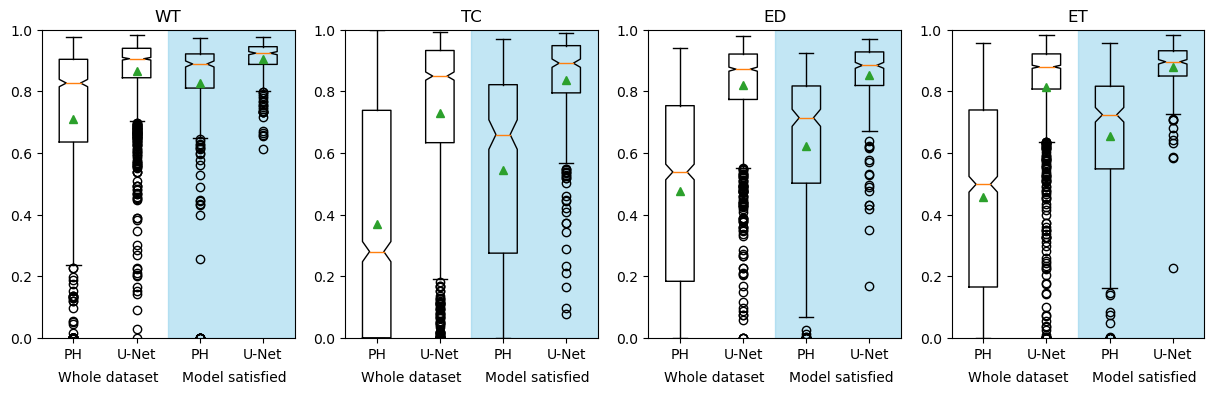

In [195]:
' Open dataframe '

# Open our segmentations

do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur
dt_threshold = 1       # Step 1, threshold for suggest_t
H2_features_max = 1    # Step 2, number of H2 bars to consider
alpha_boundary = None  # Step 3, parameter to consider inside/outside
radius_ball = 3        # Step 2, dilation parameter

parameters = [do_enhance,normalize,sigma,dt_threshold,H2_features_max,alpha_boundary,radius_ball]
files = glob.glob('results/TDAseg_scores_*')
files = [file for file in files if file[0:len('results/TDAseg_scores_')+len(str(parameters))]=='results/TDAseg_scores_'+str(parameters)]
files_length = [int(file[len('results/TDAseg_scores_')+len(str(parameters))+4:-4]) for file in files]
ind = np.argmax(files_length)
file, i_min = files[ind], files_length[ind]
print('Found', file)
df_parameters1 = pd.read_csv(file)
    
# Open U-net

df_parameters2 = pd.read_csv('results/summary_cmp_unet_pp.csv')
names = {name:True for name in df_parameters1['brats_name']}
    
' Open model '    
    
# Model 1

thresh_score = 0.0           # lower bound on the scores
thresh_smallTC = 50          # upper bound on the ratio WT/TC, which should be small
thresh_WTconnected = 10      # lower bound on the ratio first/second largest CC, should be high
admissible_argmax = [4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT)

df_VerifyModel = pd.read_csv('results/VerifyModel_20231114_dilation3_len1251.csv')
names_verify_model = {name:False for name in df_VerifyModel['brats_name']}
for i in range(len(df_VerifyModel)):
    names_verify_model[df_VerifyModel['brats_name'][i]] =                                             \
                           (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>=thresh_score) \
                       and df_VerifyModel['nonempty'][i]==True                                        \
                       and df_VerifyModel['smallTC'][i]<=thresh_smallTC                               \
                       and df_VerifyModel['WTconnected'][i]>=thresh_WTconnected                       \
                       and df_VerifyModel['argmax'][i] in admissible_argmax \
                       and df_VerifyModel['boundary_TC'][i] > 0.5 \
                       and df_VerifyModel['boundary_ET'][i] < 0.5 \
#                        and df_VerifyModel['mean_ET_t1ce'][i] > 1.2*max(df_VerifyModel['mean_TC_t1ce'][i],df_VerifyModel['mean_ED_t1ce'][i])
                         
print('Brains satisfying the model:' , np.sum(list(names_verify_model.values())), '=', \
      round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel)*100,3), '%')
    
# # Model 2

# thresh_score = 0.0           # lower bound on the scores
# thresh_smallTC = 50          # upper bound on the ratio WT/TC, which should be small
# thresh_WTconnected = 10      # lower bound on the ratio first/second largest CC, should be high
# admissible_argmax = [0,4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT)

# df_VerifyModel = pd.read_csv('results/VerifyModel_20231114_dilation3_len1251.csv')
# names_verify_model = {name:False for name in df_VerifyModel['brats_name']}
# for i in range(len(df_VerifyModel)):
#     names_verify_model[df_VerifyModel['brats_name'][i]] =                                             \
#                            (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>thresh_score) \
#                        and df_VerifyModel['nonempty'][i]==True                                        \
#                        and df_VerifyModel['smallTC'][i]<=thresh_smallTC                               \
#                        and df_VerifyModel['WTconnected'][i]>=thresh_WTconnected                       \
#                        and df_VerifyModel['argmax'][i] in admissible_argmax \
#                        and df_VerifyModel['boundary_TC'][i] > 0.75 \
#                        and df_VerifyModel['boundary_ET'][i] < 0.5 
# print('Brains satisfying the model:' , np.sum(list(names_verify_model.values())), '=', \
#       round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel)*100,3), '%')
    
' Plot '

import matplotlib.patches

fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(15, 4))
segmentation_labels = ['WT','TC','ED','ET']
for label_i, label in enumerate(segmentation_labels):
    seg_1       = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))
                                     if names[df_parameters1['brats_name'][i]]]
    seg_2       = [df_parameters2.iloc[i][label+'_unet'] for i in range(len(df_parameters2)) \
                                     if names[df_parameters2['brats_name'][i]]]
    seg_1_model = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))    \
                                     if names[df_parameters1['brats_name'][i]]            \
                                    and names_verify_model[df_parameters1['brats_name'][i]] ]
    seg_2_model = [df_parameters2.iloc[i][label+'_unet'] for i in range(len(df_parameters2))      \
                                     if names[df_parameters2['brats_name'][i]]            \
                                    and names_verify_model[df_parameters2['brats_name'][i]] ]
    
    axs[label_i].boxplot([seg_1,seg_2,seg_1_model,seg_2_model], notch=True, showmeans=True);
    axs[label_i].set_title(label)
    axs[label_i].set_ylim(0,1); 
    axs[label_i].set_xlim(0.5,4.5)
    axs[label_i].set_xticklabels(['PH','U-Net','PH', 'U-Net'])
    axs[label_i].set_yticks([0,0.2,0.4,0.6,0.8,1])
#     if label_i in [0,2]: 
#         axs[label_i].yaxis.tick_right()
#         axs[label_i].set_yticklabels([])
    axs[label_i].add_patch(matplotlib.patches.Rectangle((2.5, 0), 2.5, 1,color='skyblue',alpha=0.5))
    axs[label_i].text(1.55, -0.15, 'Whole dataset', horizontalalignment='center', verticalalignment='bottom')
    axs[label_i].text(3.55, -0.15, 'Model satisfied', horizontalalignment='center', verticalalignment='bottom')
    
    # Print scores
    for i_seg, seg in enumerate([seg_1,seg_2,seg_1_model,seg_2_model]):
        msg = '$'+repr(round(np.mean(seg),3))+"\\"+'pm'+repr(round(np.std(seg),3))+'$, median '+repr(round(np.median(seg),3))
        if i_seg==0:   msg = label+' - TDA - whole dataset:     '    +msg
        elif i_seg==1: msg = label+' - U-net - whole dataset:   '    +msg
        elif i_seg==2: msg = label+' - TDA - model satisfied:   '    +msg
        elif i_seg==3: msg = label+' - U-net - model satisfied: '    +msg
        print(msg)
        
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2, hspace=0)
plt.savefig("results/scores_BraTS_article.pdf", format="pdf", bbox_inches="tight");

# Illustration for article - local transformations TDA

/home/raph/GoogleDrive/Professionnel/TDA+Brains/Code Python/parse_brats_for_raph.py:77: UserWarning: It is not recommended to set brats_list to None with BraTS2021database. It can lead to errors because ventricule segmentations where not made for all data.
  warnings.warn("It is not recommended to set brats_list to None with BraTS2021"
/home/raph/GoogleDrive/Professionnel/TDA+Brains/Code Python/parse_brats_for_raph.py:77: UserWarning: It is not recommended to set brats_list to None with BraTS2021database. It can lead to errors because ventricule segmentations where not made for all data.
  warnings.warn("It is not recommended to set brats_list to None with BraTS2021"


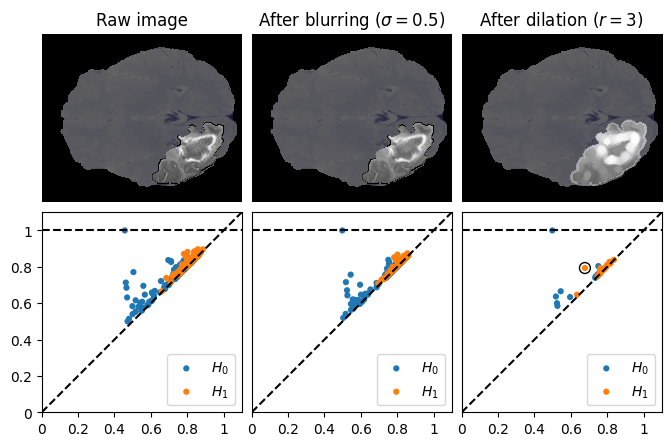

In [349]:
verbose = False

# Open image
i = 2
pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
pos = argmax_image(img_t1ce)

# Define slice
s = -2
img = img_t1ce[:,:,pos[2]+s]*(seg_medecin[:,:,pos[2]+s]>0)
img_raw = img_t1ce[:,:,pos[2]+s]#*(img_t1ce[:,:,pos[2]+s]>0)*(seg_medecin[:,:,pos[2]+s]==0)
img_raw[img_raw==0]=np.nan; img_raw[seg_medecin[:,:,pos[2]+s]>0] = np.nan; 

def ComputeDiagramAndPlot_img():
    # First ax, brain
    xmin, ymin = 40, 25
    ax0.imshow(1-img[xmin:-xmin,ymin:-ymin], cmap='Greys'); ax0.axis('off')
    ax0.imshow(img_raw[xmin:-xmin,ymin:-ymin],alpha=0.4,cmap='Purples')
    
    # Second ax, diagram
    if verbose: start_time = ChronometerStart('Compute diagram... ')
    barcode = cripser.computePH(1-img,maxdim=1) # Compute diagram
    if verbose: ChronometerStop(start_time, method='s')
    b = [np.array([bar[1:3] for bar in barcode if bar[0]==i]) for i in range(2)]; b[0][-1][1]=1
    persim.plot_diagrams(b, ax=ax, diagonal=False)
    ax.set_xlim(0,1.1); ax.set_ylim(0,1.1); 
    ax.plot([0,1.1],[1,1],ls='dashed',c='black'); ax.plot([0,1.1],[0,1.1],ls='dashed',c='black')
    ax.set_xlabel(''); ax.set_ylabel('');  
    ax.set_xticks([0,0.2,0.4,0.6,0.8,1]);ax.set_xticklabels([0,0.2,0.4,0.6,0.8,1])
    ax.set_yticks([0,0.2,0.4,0.6,0.8,1]);ax.set_yticklabels([0,0.2,0.4,0.6,0.8,1])

# Plot
fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(8, 2/3*8))
fig.subplots_adjust(wspace=0.05, hspace=-0.1)

# Plot raw image
ax0 = axs[0,0]
ax = axs[1,0]
ComputeDiagramAndPlot_img()
ax0.set_title('Raw image')

# Plot after blur
sigma = .5
# img = scipy.ndimage.gaussian_filter(img, sigma=sigma)    
pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
img_t1ce = scipy.ndimage.gaussian_filter(img_t1ce, sigma=sigma)   
img = img_t1ce[:,:,pos[2]+s]*(seg_medecin[:,:,pos[2]+s]>0)

ax0 = axs[0,1]
ax = axs[1,1]
ComputeDiagramAndPlot_img(); ax.set_yticks([])
ax0.set_title('After blurring ($\sigma=0.5$)')

# Plot after dilation
radius_ball = 3
img = skimage.morphology.dilation(img, footprint=skimage.morphology.disk(radius_ball), out=None, shift_x=False, shift_y=False)

ax0 = axs[0,2]
ax = axs[1,2]
ComputeDiagramAndPlot_img(); ax.set_yticks([]);
ax0.set_title('After dilation ($r=3$)')
ax.add_patch(plt.Circle((0.6775, 0.7935028), 0.03, color='black', fill=False));

plt.savefig("Images/local_transformations_TDA.pdf", format="pdf", bbox_inches="tight");

# Example on image

In [28]:
i = 9

/home/raph/GoogleDrive/Professionnel/TDA+Brains/Code Python/parse_brats_for_raph.py:77: UserWarning: It is not recommended to set brats_list to None with BraTS2021database. It can lead to errors because ventricule segmentations where not made for all data.
  warnings.warn("It is not recommended to set brats_list to None with BraTS2021"


Suggest t... Execution time: 1 s.


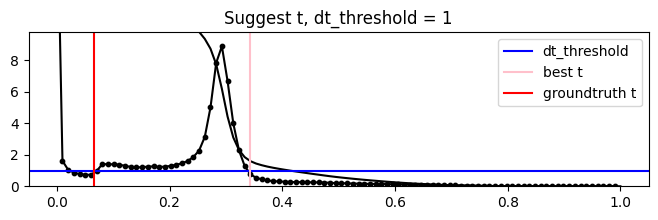

Get largest connected component... Execution time: 1 s.
Fill the holes... Execution time: 0 s.
Compute diagram... Execution time: 23 s.
H2 diagram: [[0.6527448145941059, 0.9107330647259229, 175.0, 130.0, 66.0, 166.0, 125.0, 66.0], [0.6388046299023713, 0.8147524699444825, 162.0, 163.0, 106.0, 161.0, 173.0, 95.0]]
Width of the holes: {0: 47316, 1: 342}
Sørensen–Dice coefficients: {1: 0.957, 2: 0.717, 4: 0.801}


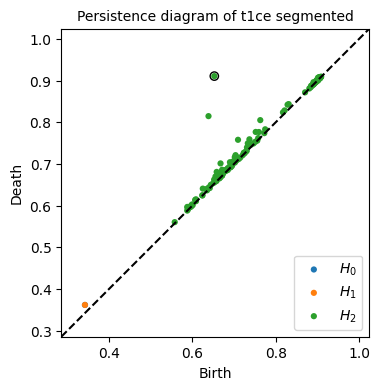

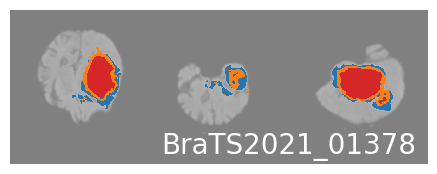

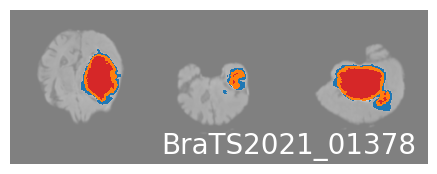

In [29]:
' Full segmentation - with dilation '

verbose, plot = True, True
# verbose, plot = False, False

# Parameters
do_enhance = False         # Preprocess, apply enhancement or not
normalize = 'max'          # Preprocess, divide by max or 255
sigma = 1                  # Preprocess, Gaussian blur
dt_threshold = 1           # Step 1, threshold for suggest_t
H2_features_max = 2        # Step 2, number of H2 bars to consider
alpha_boundary = None      # Step 3, parameter to consider inside/outside
radius_ball = 3            # Step 2, dilation parameter

# Open image
pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma=sigma,normalize=normalize,do_enhance=do_enhance)
    
# Segmentation
seg_union   = Step1(img_flair,dt_threshold=dt_threshold,seg_medecin=seg_medecin,verbose=verbose,plot=plot)

if radius_ball==0: 
    seg_contour = Step2(img_t1ce,seg_union,H2_features_max=H2_features_max,verbose=verbose,plot=plot)
    seg_final   = Step3(seg_union,seg_contour,verbose=verbose)
else:
    img_t1ce_dilation = skimage.morphology.dilation(img_t1ce, footprint=skimage.morphology.ball(radius_ball), out=None, shift_x=False, shift_y=False)
    seg_contour = Step2(img_t1ce_dilation,seg_union,H2_features_max=H2_features_max,verbose=verbose,plot=plot)
    seg_final_dilation   = Step3(seg_union,seg_contour,verbose=verbose)
    
    # ED
    seg_final = seg_union.copy()*2    
    # ET
    im = img_t1ce_dilation*seg_contour; im[im==0]=1
    seg_ET_erode = seg_contour*(img_t1ce>np.min(im))*1
    seg_final[seg_ET_erode>0] = 4
    # TC
    seg_TC_erode = skimage.morphology.dilation((seg_final_dilation==1)*1, footprint=skimage.morphology.ball(radius_ball))*seg_union
    seg_final[seg_TC_erode>0] = 1

# Plot
GetDICEs(seg_final,seg_medecin,verbose=True);
PlotSegmentation(pb,img_flair,seg_final,figsize=(6,2))
PlotSegmentation(pb,img_flair,seg_medecin,figsize=(6,2))

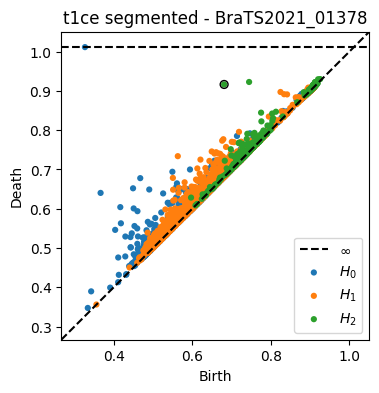

In [33]:
' Save pdf for Anton '

plot = True
# seg_union = (seg_medecin>0)*1
radius_ball = 5
seg_union_dilated = skimage.morphology.dilation(seg_union, footprint=skimage.morphology.ball(radius_ball), out=None, shift_x=False, shift_y=False)
seg_union_t1ce = img_t1ce*seg_union_dilated
barcode = cripser.computePH(1-seg_union_t1ce,maxdim=3) # Compute diagram
H2 = [list(bar[1::]) for bar in barcode if bar[0]==2 and bar[2]<1] # Only non-infinite bars
H2 = [bar for _,bar in sorted(zip([bar[1]-bar[0] for bar in H2],H2))[::-1]] # Sort list H2 by persistence

fig = plt.figure(figsize=(4,4)); ax = fig.add_subplot(1,1,1)
dim_max = int(max([bar[0] for bar in barcode]))
persim.plot_diagrams([np.array([bar[1:3] for bar in barcode if bar[0]==i]) for i in range(dim_max+1)],ax=ax)
ax.set_title('Persistence diagram of flair',fontsize=10);
bar = H2[0]
patch = plt.Circle((bar[0],bar[1]), 0.01,fill=False); ax.add_patch(patch)

plt.title('t1ce segmented - '+pb.brats_list[i])
plt.savefig("Images/Diagram_Brain.pdf", format="pdf", bbox_inches="tight")

Sørensen–Dice coefficients: {1: 0.962, 2: 0.318, 4: 0.625}


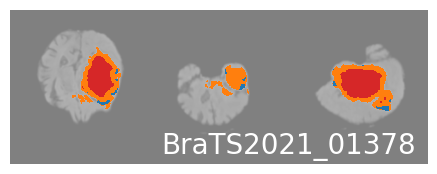

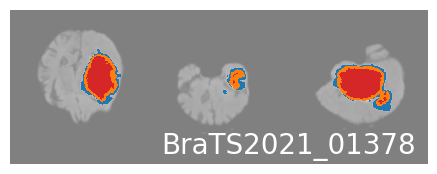

In [588]:
' Full segmentation '

verbose, plot = False, False

# Parameters
do_enhance = False         # Preprocess, apply enhancement or not
normalize= 'max'           # Preprocess, divide by max or 255
sigma = 1                  # Preprocess, Gaussian blur
dt_threshold = 1           # Step 1, threshold for suggest_t
H2_features_max = 2        # Step 2, number of H2 bars to consider
alpha_boundary = None      # Step 3, parameter to consider inside/outside

# Open image
pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma=sigma,normalize=normalize,do_enhance=do_enhance)
    
# Segmentation
seg_union   = Step1(img_flair,dt_threshold=dt_threshold,seg_medecin=seg_medecin,verbose=verbose,plot=plot)
seg_contour = Step2(img_t1ce,seg_union,H2_features_max=H2_features_max,verbose=verbose,plot=plot)
seg_final   = Step3(seg_union,seg_contour,verbose=verbose)

# Plot
GetDICEs(seg_final,seg_medecin,verbose=True);
PlotSegmentation(pb,img_flair,seg_final,figsize=(6,2))
PlotSegmentation(pb,img_flair,seg_medecin,figsize=(6,2))

In [589]:
# ' Full segmentation '

# verbose = True
# plot = True

# # Parameters
# # do_enhance = [False,True]  # Preprocess, apply enhancement or not
# do_enhance = [True,True]   # Preprocess, apply enhancement or not
# normalize= 'max'           # Preprocess, divide by max or 255
# sigma = 1                  # Preprocess, Gaussian blur
# dt_threshold = 1           # Step 1, threshold for suggest_t
# H2_features_max = 1        # Step 2, number of H2 bars to consider
# alpha_boundary = None      # Step 3, parameter to consider inside/outside

# # Open image
# pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
# img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma=sigma,normalize=normalize,do_enhance=do_enhance)

# # # Morpho
# # iterations = 2
# # structure = scipy.ndimage.generate_binary_structure(rank=3, connectivity=1)
# # for i in range(iterations): 
# #     img_flair = scipy.ndimage.grey_dilation(img_flair,structure=structure)
# #     img_t1ce = scipy.ndimage.grey_dilation(img_t1ce,structure=structure)
# # for i in range(iterations): 
# #     img_flair = scipy.ndimage.grey_erosion(img_flair,structure=structure)
# #     img_t1ce = scipy.ndimage.grey_erosion(img_t1ce,structure=structure)
    
# # Segmentation
# seg_union   = Step1(img_flair,dt_threshold=dt_threshold,seg_medecin=seg_medecin,verbose=verbose,plot=plot)
# seg_contour = Step2(img_t1ce,seg_union,H2_features_max=H2_features_max,verbose=verbose,plot=plot)

# # iterations = 2
# # for i in range(iterations): seg_contour = scipy.ndimage.binary_dilation(seg_contour,structure=structure)
# # for i in range(iterations): seg_contour = scipy.ndimage.binary_erosion(seg_contour,structure=structure)
# # seg_contour = seg_contour*1

# seg_final   = Step3(seg_union,seg_contour,verbose=verbose)

# # Plot
# GetDICEs(seg_final,seg_medecin,verbose=True);
# PlotSegmentation(pb,img_flair,seg_final,figsize=(6,2))
# PlotSegmentation(pb,img_flair,seg_medecin,figsize=(6,2))

/home/raph/GoogleDrive/Professionnel/TDA+Brains/Code Python/parse_brats_for_raph.py:77: UserWarning: It is not recommended to set brats_list to None with BraTS2021database. It can lead to errors because ventricule segmentations where not made for all data.
  warnings.warn("It is not recommended to set brats_list to None with BraTS2021"


Sørensen–Dice coefficients: {1: 0.0, 2: 0.122, 4: 0.181}


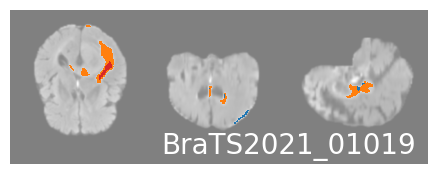

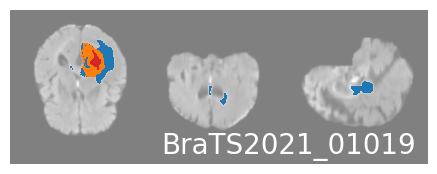

Sørensen–Dice coefficients: {1: 0.0, 2: 0.0, 4: 0.0}


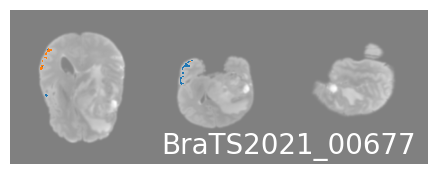

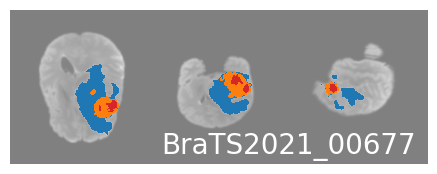

Sørensen–Dice coefficients: {1: 0.0, 2: 0.0, 4: 0.002}


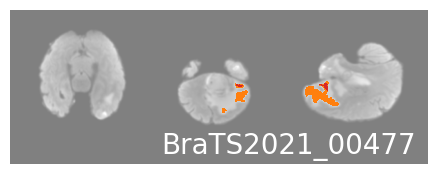

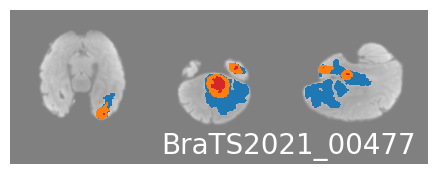

Sørensen–Dice coefficients: {1: 0.0, 2: 0.789, 4: 0.41}


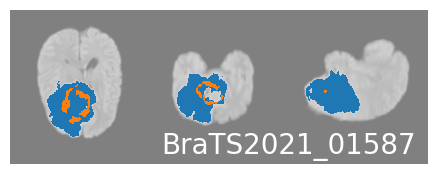

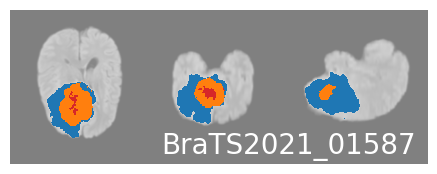

Sørensen–Dice coefficients: {1: 0.135, 2: 0.429, 4: 0.248}


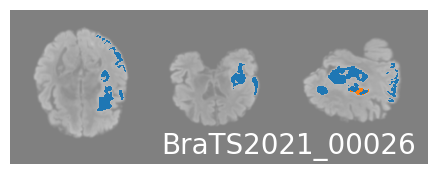

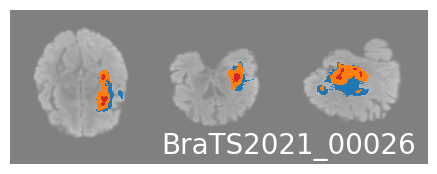

In [10]:
' Full segmentation '

verbose = False
plot = False

# Parameters
sigma = 1
dt_threshold = 1
H2_features_max = 1
alpha_boundary = None #value to consider inside/outside

for i in [10,13,24,29,105]:
    # Open image
    pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
    img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma)

    # Segmentation
    seg_union   = Step1(img_flair,dt_threshold=dt_threshold,seg_medecin=seg_medecin,verbose=verbose,plot=plot)
    seg_contour = Step2(img_t1ce,seg_union,H2_features_max=H2_features_max,verbose=verbose,plot=plot)
    seg_final   = Step3(seg_union,seg_contour,verbose=verbose)

    # Plot
    GetDICEs(seg_final,seg_medecin,verbose=True);
    PlotSegmentation(pb,img_flair,seg_final,figsize=(6,2))
    PlotSegmentation(pb,img_flair,seg_medecin,figsize=(6,2))
    plt.show()

# Batch images

In [222]:
' Full segmentation - batch '

pb = parse_brats(brats_list=None,brats_folder='2021',modality='flair')
i_list = range(len(pb.brats_list))

# Parameters
do_enhance = False       # Preprocess, apply enhancement or not
normalize= 'max'         # Preprocess, divide by max or 255
sigma = 1                # Preprocess, Gaussian blur
dt_threshold = 1         # Step 1, threshold for suggest_t
H2_features_max = 5      # Step 2, number of H2 bars to consider
alpha_boundary = None    # Step 3, parameter to consider inside/outside
parameters = [do_enhance,normalize,sigma,dt_threshold,H2_features_max,alpha_boundary]

# Find last updated file
files = glob.glob('results/TDAseg_scores_*')
files = [file for file in files if file[0:len('results/TDAseg_scores_')+len(str(parameters))]=='results/TDAseg_scores_'+str(parameters)]
files_length = [int(file[len('results/TDAseg_scores_')+len(str(parameters))+4:-4]) for file in files]
if len(files) is not 0:
    ind = np.argmax(files_length)
    file, i_min = files[ind], files_length[ind]
    print('Found file', file, '- i_min =', i_min)
else: 
    i_min = 0
    print('No files found')
    
DICEs = dict()

msg = 'Compute DICEs... '
start_time = ChronometerStart(msg)
for i in range(i_min,len(i_list)):
    # Open image
    pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i_list[i])
    img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma,normalize,do_enhance)

    # Segmentation
    seg_union   = Step1(img_flair,dt_threshold=dt_threshold,seg_medecin=seg_medecin,verbose=False,plot=False)
    seg_contour = Step2(img_t1ce,seg_union,H2_features_max=H2_features_max,verbose=False,plot=False)
    seg_final   = Step3(seg_union,seg_contour,verbose=False)
    DICEs[pb.brats_list[i_list[i]]] = GetDICEs(seg_final,seg_medecin,verbose=False);
    DICEs[pb.brats_list[i_list[i]]]['brats_name'] = pb.brats_list[i_list[i]]
    ChronometerTick(start_time, i-i_min, len(i_list)-i_min, msg)
    
# Save
df = pd.DataFrame.from_dict(DICEs, orient='index')
df = df.rename(columns={0: "WT", 1: "TC", 2: "ED", 4: "ET"}, errors="raise")
if i_min>0:
    df_old = pd.read_csv(file)
    df = pd.concat([df_old[['brats_name','TC','ED','ET','WT']],\
                    df[['brats_name','TC','ED','ET','WT']] ])
df.to_csv('results/TDAseg_scores_'+str(parameters)+'_len'+repr(len(df))+'.csv')

Found file results/TDAseg_scores_[False, 'max', 1, 1, 5, None]_len1010.csv - i_min = 1010
Compute DICEs... It 241/241. Duration 2:27:56 Expected remaining time 0:00:00.


### New implementation, with radius_ball

In [814]:
' Full segmentation - batch '

pb = parse_brats(brats_list=None,brats_folder='2021',modality='flair')
i_list = range(len(pb.brats_list))

# Parameters
do_enhance = False       # Preprocess, apply enhancement or not
normalize= 'max'         # Preprocess, divide by max or 255
sigma = 1                # Preprocess, Gaussian blur
dt_threshold = 'oracle'  # Step 1, threshold for suggest_t
H2_features_max = 1      # Step 2, number of H2 bars to consider
alpha_boundary = None    # Step 3, parameter to consider inside/outside
radius_ball = 3          # Step 2, dilation parameter
parameters = [do_enhance,normalize,sigma,dt_threshold,H2_features_max,alpha_boundary,radius_ball]

# Find last updated file
files = glob.glob('results/TDAseg_scores_*')
files = [file for file in files if file[0:len('results/TDAseg_scores_')+len(str(parameters))]=='results/TDAseg_scores_'+str(parameters)]
files_length = [int(file[len('results/TDAseg_scores_')+len(str(parameters))+4:-4]) for file in files]
if len(files) is not 0:
    ind = np.argmax(files_length)
    file, i_min = files[ind], files_length[ind]
    print('Found file', file, '- i_min =', i_min)
else: 
    i_min = 0
    print('No files found')
    
DICEs = dict()

msg = 'Compute DICEs... '
start_time = ChronometerStart(msg)
for i in range(i_min,len(i_list)):
    # Open image
    pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i_list[i])
    img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma,normalize,do_enhance)

    # Segmentation
    if dt_threshold == 'oracle':
        seg_union   = (seg_medecin>0)*1
    else:
        seg_union   = Step1(img_flair,dt_threshold=dt_threshold,seg_medecin=seg_medecin,verbose=False,plot=False)

    if radius_ball==0: 
        seg_contour = Step2(img_t1ce,seg_union,H2_features_max=H2_features_max,verbose=verbose,plot=plot)
        seg_final   = Step3(seg_union,seg_contour,verbose=verbose)
    else:
        img_t1ce_dilation = skimage.morphology.dilation(img_t1ce, footprint=skimage.morphology.ball(radius_ball), out=None, shift_x=False, shift_y=False)
        seg_contour = Step2(img_t1ce_dilation,seg_union,H2_features_max=H2_features_max,verbose=verbose,plot=plot)
        seg_final_dilation   = Step3(seg_union,seg_contour,verbose=verbose)

        # ED
        seg_final = seg_union.copy()*2    
        # ET
        im = img_t1ce_dilation*seg_contour; im[im==0]=1
        seg_ET_erode = seg_contour*(img_t1ce>np.min(im))*1
        seg_final[seg_ET_erode>0] = 4
        # TC
        seg_TC_erode = skimage.morphology.dilation((seg_final_dilation==1)*1, footprint=skimage.morphology.ball(radius_ball))*seg_union
        seg_final[seg_TC_erode>0] = 1
    
    DICEs[pb.brats_list[i_list[i]]] = GetDICEs(seg_final,seg_medecin,verbose=False);
    DICEs[pb.brats_list[i_list[i]]]['brats_name'] = pb.brats_list[i_list[i]]
    ChronometerTick(start_time, i-i_min, len(i_list)-i_min, msg)
    
# Save
df = pd.DataFrame.from_dict(DICEs, orient='index')
df = df.rename(columns={0: "WT", 1: "TC", 2: "ED", 4: "ET"}, errors="raise")
if i_min>0:
    df_old = pd.read_csv(file)
    df = pd.concat([df_old[['brats_name','TC','ED','ET','WT']],\
                    df[['brats_name','TC','ED','ET','WT']] ])
df.to_csv('results/TDAseg_scores_'+str(parameters)+'_len'+repr(len(df))+'.csv')

Found file results/TDAseg_scores_[False, 'max', 1, 'oracle', 1, None, 3]_len234.csv - i_min = 234
Compute DICEs... It 1017/1017. Duration 7:05:34 Expected remaining time 0:00:00.


In [815]:
# Save
df = pd.DataFrame.from_dict(DICEs, orient='index')
df = df.rename(columns={0: "WT", 1: "TC", 2: "ED", 4: "ET"}, errors="raise")
if i_min>0:
    df_old = pd.read_csv(file)
    df = pd.concat([df_old[['brats_name','TC','ED','ET','WT']],\
                    df[['brats_name','TC','ED','ET','WT']] ])
df.to_csv('results/TDAseg_scores_'+str(parameters)+'_len'+repr(len(df))+'.csv')

In [780]:
def Plot_CompareParameters():
    # Plot
    fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(20, 5))
    segmentation_labels = ['WT','TC','ED','ET']
    for label_i, label in enumerate(segmentation_labels):
        seg_1       = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))
                                         if names[df_parameters1['brats_name'][i]]]
        seg_2       = [df_parameters2.iloc[i][label] for i in range(len(df_parameters2))
                                         if names[df_parameters2['brats_name'][i]]]
        seg_3       = [df_parameters3.iloc[i][label] for i in range(len(df_parameters3))
                                         if names[df_parameters3['brats_name'][i]]]
        seg_4       = [df_parameters4.iloc[i][label] for i in range(len(df_parameters4))
                                         if names[df_parameters4['brats_name'][i]]]
        seg_5       = [df_parameters5.iloc[i][label] for i in range(len(df_parameters5))
                                         if names[df_parameters5['brats_name'][i]]]
        seg_1_model = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))    \
                                         if names[df_parameters1['brats_name'][i]]            \
                                        and names_verify_model[df_parameters1['brats_name'][i]] ]
        seg_2_model = [df_parameters2.iloc[i][label] for i in range(len(df_parameters2))      \
                                         if names[df_parameters2['brats_name'][i]]            \
                                        and names_verify_model[df_parameters2['brats_name'][i]] ]
        seg_3_model = [df_parameters3.iloc[i][label] for i in range(len(df_parameters3))      \
                                         if names[df_parameters3['brats_name'][i]]            \
                                        and names_verify_model[df_parameters3['brats_name'][i]] ]
        seg_4_model = [df_parameters4.iloc[i][label] for i in range(len(df_parameters4))      \
                                         if names[df_parameters4['brats_name'][i]]            \
                                        and names_verify_model[df_parameters4['brats_name'][i]] ]
        seg_5_model = [df_parameters5.iloc[i][label] for i in range(len(df_parameters5))      \
                                         if names[df_parameters5['brats_name'][i]]            \
                                        and names_verify_model[df_parameters5['brats_name'][i]] ]

        axs[label_i].boxplot([seg_1,seg_2,seg_3,seg_4,seg_5,seg_1_model,seg_2_model,seg_3_model,seg_4_model,seg_5_model], notch=True, showmeans=True);
        axs[label_i].set_title(label)
        axs[label_i].set_ylim(0,1)
        axs[label_i].set_xticklabels(['p1','p2','p3', 'p4', 'p5', 'p1 mdl', 'p2 mdl', 'p3 mdl', 'p4 mdl', 'p5 mdl'])

Found results/TDAseg_scores_[False, 'max', 1, 1, 1, None]_len1251.csv
Found results/TDAseg_scores_[False, 'max', 1, 1, 2, None, 3]_len1251.csv
Found results/TDAseg_scores_[False, 'max', 1, 1, 1, None, 1]_len1251.csv
Found results/TDAseg_scores_[False, 'max', 1, 1, 1, None, 3]_len1251.csv
Found results/TDAseg_scores_[False, 'max', 1, 'oracle', 1, None, 3]_len1251.csv
Brains satisfying the model: 301 = 24.061 %
Brains satisfying the model: 364 = 29.097 %
Brains satisfying the model: 238 = 19.025 %
Number satisfying model OLD: 119 = 9.51 %
Number satisfying model ORACLE: 331 = 26.46 %


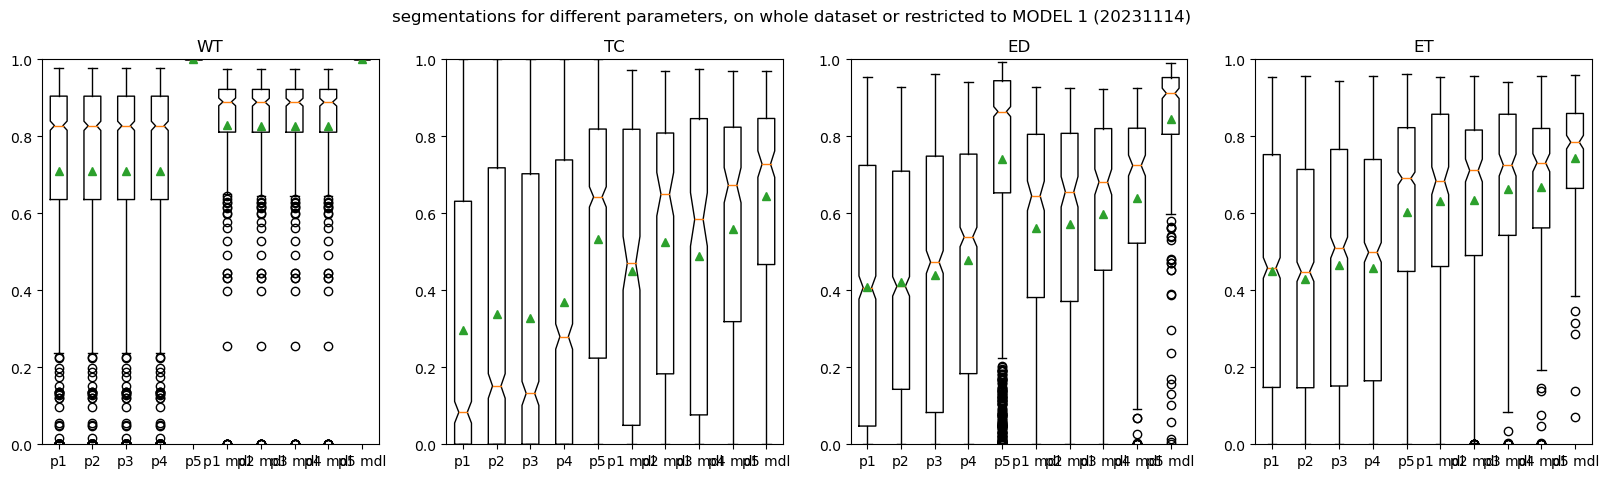

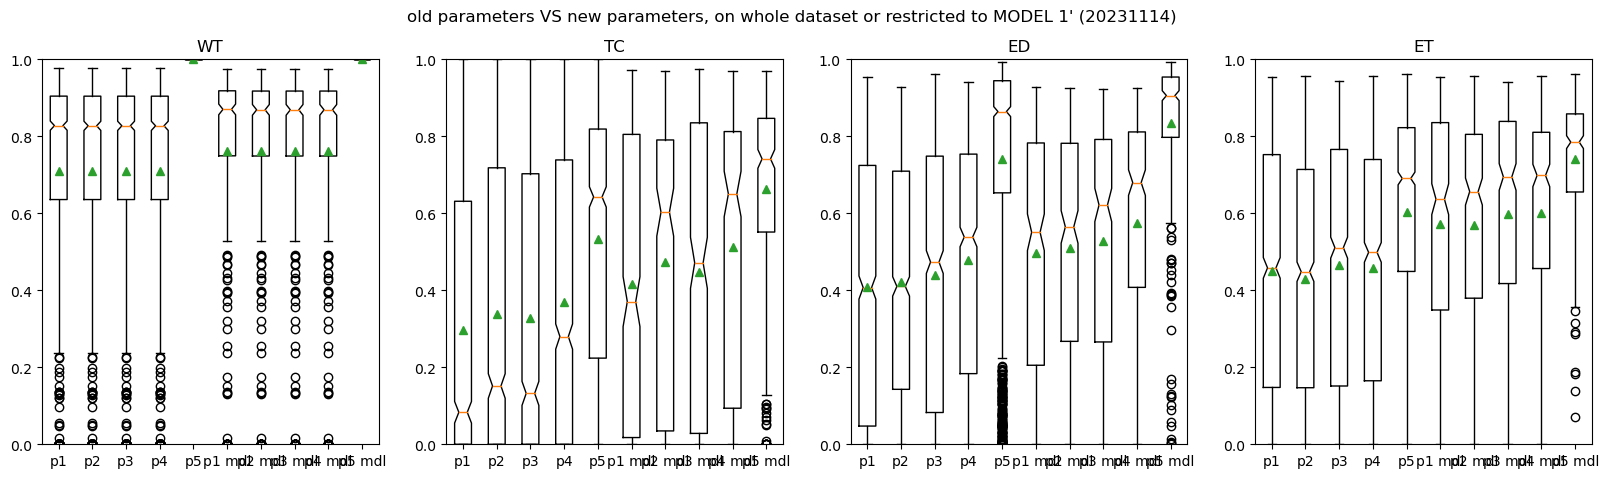

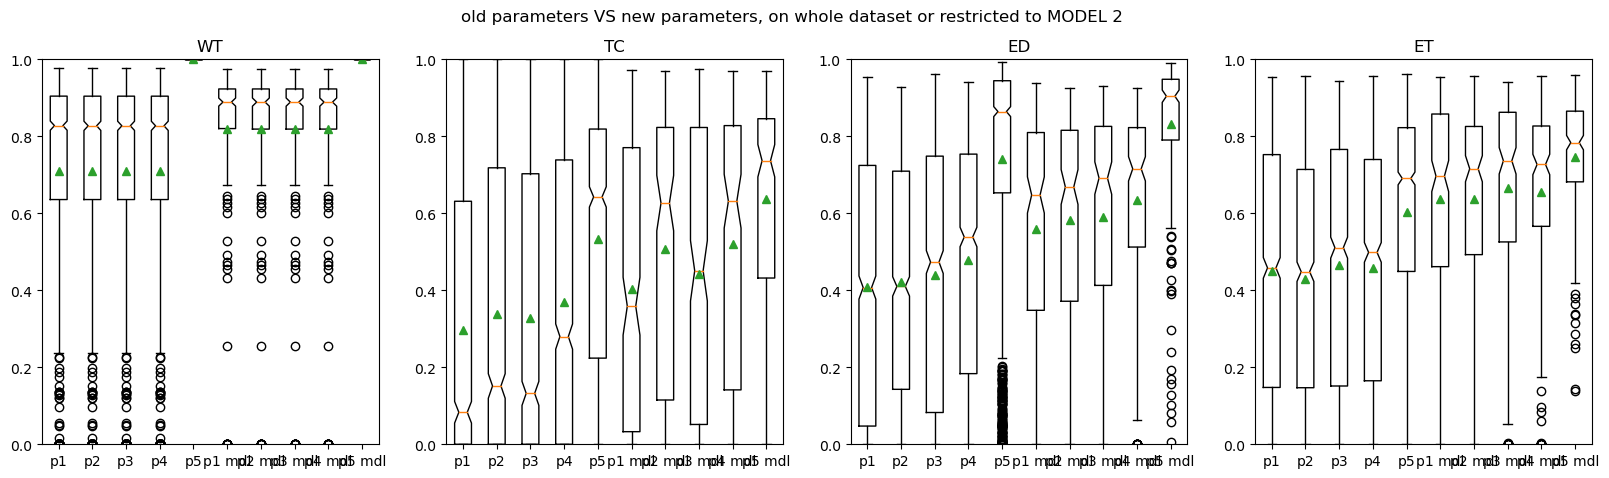

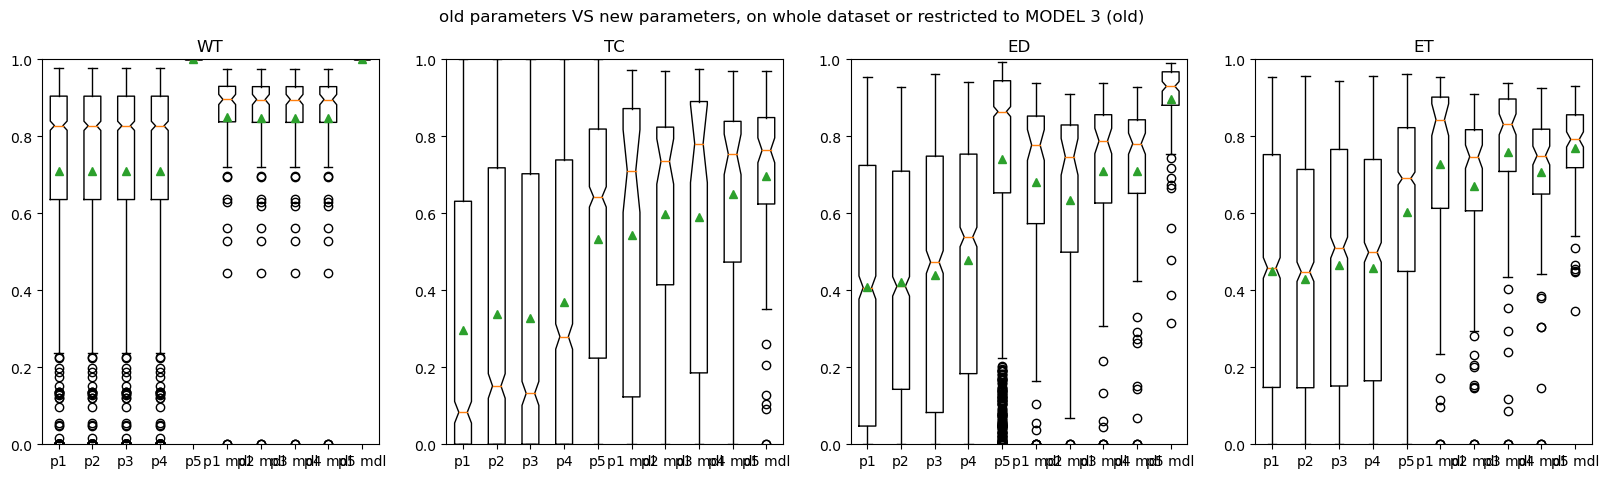

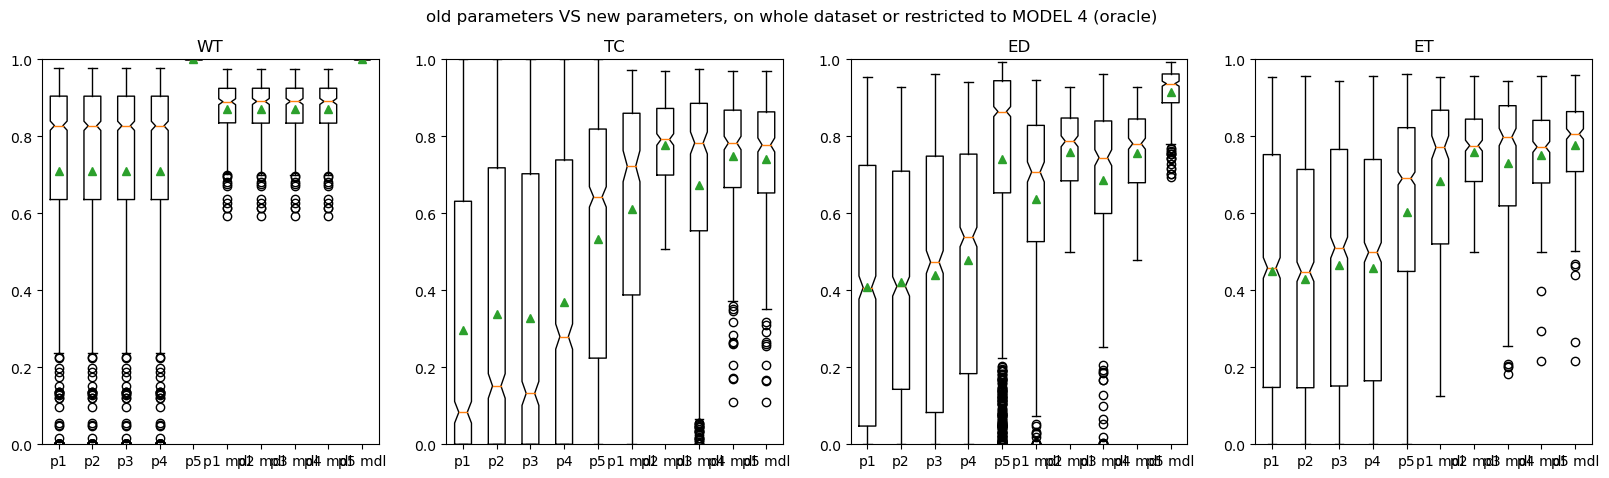

In [816]:
' Compare dataframes '

# Open first dataframe

do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur
dt_threshold = 1       # Step 1, threshold for suggest_t
H2_features_max = 1    # Step 2, number of H2 bars to consider
alpha_boundary = None  # Step 3, parameter to consider inside/outside

parameters = [do_enhance,normalize,sigma,dt_threshold,H2_features_max,alpha_boundary]
files = glob.glob('results/TDAseg_scores_*')
files = [file for file in files if file[0:len('results/TDAseg_scores_')+len(str(parameters))]=='results/TDAseg_scores_'+str(parameters)]
files_length = [int(file[len('results/TDAseg_scores_')+len(str(parameters))+4:-4]) for file in files]
ind = np.argmax(files_length)
file, i_min = files[ind], files_length[ind]
print('Found', file)
df_parameters1 = pd.read_csv(file)

# Open second dataframe

do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur
dt_threshold = 1       # Step 1, threshold for suggest_t
H2_features_max = 2    # Step 2, number of H2 bars to consider
alpha_boundary = None  # Step 3, parameter to consider inside/outside
radius_ball = 3            # Step 2, dilation parameter

parameters = [do_enhance,normalize,sigma,dt_threshold,H2_features_max,alpha_boundary,radius_ball]
files = glob.glob('results/TDAseg_scores_*')
files = [file for file in files if file[0:len('results/TDAseg_scores_')+len(str(parameters))]=='results/TDAseg_scores_'+str(parameters)]
files_length = [int(file[len('results/TDAseg_scores_')+len(str(parameters))+4:-4]) for file in files]
ind = np.argmax(files_length)
file, i_min = files[ind], files_length[ind]
print('Found', file)
df_parameters2 = pd.read_csv(file)

# Open third dataframe 

do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur
dt_threshold = 1       # Step 1, threshold for suggest_t
H2_features_max = 1    # Step 2, number of H2 bars to consider
alpha_boundary = None  # Step 3, parameter to consider inside/outside
radius_ball = 1        # Step 2, dilation parameter

parameters = [do_enhance,normalize,sigma,dt_threshold,H2_features_max,alpha_boundary,radius_ball]
files = glob.glob('results/TDAseg_scores_*')
files = [file for file in files if file[0:len('results/TDAseg_scores_')+len(str(parameters))]=='results/TDAseg_scores_'+str(parameters)]
files_length = [int(file[len('results/TDAseg_scores_')+len(str(parameters))+4:-4]) for file in files]
ind = np.argmax(files_length)
file, i_min = files[ind], files_length[ind]
print('Found', file)
df_parameters3 = pd.read_csv(file)

# Open fourth dataframe 

do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur
dt_threshold = 1       # Step 1, threshold for suggest_t
H2_features_max = 1    # Step 2, number of H2 bars to consider
alpha_boundary = None  # Step 3, parameter to consider inside/outside
radius_ball = 3        # Step 2, dilation parameter

parameters = [do_enhance,normalize,sigma,dt_threshold,H2_features_max,alpha_boundary,radius_ball]
files = glob.glob('results/TDAseg_scores_*')
files = [file for file in files if file[0:len('results/TDAseg_scores_')+len(str(parameters))]=='results/TDAseg_scores_'+str(parameters)]
files_length = [int(file[len('results/TDAseg_scores_')+len(str(parameters))+4:-4]) for file in files]
ind = np.argmax(files_length)
file, i_min = files[ind], files_length[ind]
print('Found', file)
df_parameters4 = pd.read_csv(file)

# Open fifth dataframe (the newest one)

do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur
dt_threshold = 'oracle'       # Step 1, threshold for suggest_t
H2_features_max = 1    # Step 2, number of H2 bars to consider
alpha_boundary = None  # Step 3, parameter to consider inside/outside
radius_ball = 3        # Step 2, dilation parameter

parameters = [do_enhance,normalize,sigma,dt_threshold,H2_features_max,alpha_boundary,radius_ball]
files = glob.glob('results/TDAseg_scores_*')
files = [file for file in files if file[0:len('results/TDAseg_scores_')+len(str(parameters))]=='results/TDAseg_scores_'+str(parameters)]
files_length = [int(file[len('results/TDAseg_scores_')+len(str(parameters))+4:-4]) for file in files]
ind = np.argmax(files_length)
file, i_min = files[ind], files_length[ind]
print('Found', file)
df_parameters5 = pd.read_csv(file)

# Get common names
names = {name:False for name in df_parameters1['brats_name']}
for i in range(len(df_parameters5)): names[df_parameters5['brats_name'][i]] = True
    
' Model 1 '    
    
# Get brains verify model 

thresh_score = 0.0           # lower bound on the scores
thresh_smallTC = 50          # upper bound on the ratio WT/TC, which should be small
thresh_WTconnected = 10      # lower bound on the ratio first/second largest CC, should be high
admissible_argmax = [4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT)

df_VerifyModel = pd.read_csv('results/VerifyModel_20231114_dilation3_len1251.csv')
names_verify_model = {name:False for name in df_VerifyModel['brats_name']}
for i in range(len(df_VerifyModel)):
    names_verify_model[df_VerifyModel['brats_name'][i]] =                                             \
                           (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>thresh_score) \
                       and df_VerifyModel['nonempty'][i]==True                                        \
                       and df_VerifyModel['smallTC'][i]<=thresh_smallTC                               \
                       and df_VerifyModel['WTconnected'][i]>=thresh_WTconnected                       \
                       and df_VerifyModel['argmax'][i] in admissible_argmax \
                       and df_VerifyModel['boundary_TC'][i] > 0.5 \
                       and df_VerifyModel['boundary_ET'][i] < 0.5 \
#                        and df_VerifyModel['mean_ET_t1ce'][i] > 1.2*max(df_VerifyModel['mean_TC_t1ce'][i],df_VerifyModel['mean_ED_t1ce'][i])
                         
print('Brains satisfying the model:' , np.sum(list(names_verify_model.values())), '=', \
      round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel)*100,3), '%')
    
Plot_CompareParameters()
plt.suptitle('segmentations for different parameters, on whole dataset or restricted to MODEL 1 (20231114)')

' Model 1 prime '    
    
# Get brains verify model 

thresh_score = 0.0           # lower bound on the scores
thresh_smallTC = 50          # upper bound on the ratio WT/TC, which should be small
thresh_WTconnected = 10      # lower bound on the ratio first/second largest CC, should be high
admissible_argmax = [0,4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT)

df_VerifyModel = pd.read_csv('results/VerifyModel_20231114_dilation3_len1251.csv')
names_verify_model = {name:False for name in df_VerifyModel['brats_name']}
for i in range(len(df_VerifyModel)):
    names_verify_model[df_VerifyModel['brats_name'][i]] =                                             \
                           (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>thresh_score) \
                       and df_VerifyModel['nonempty'][i]==True                                        \
                       and df_VerifyModel['smallTC'][i]<=thresh_smallTC                               \
                       and df_VerifyModel['WTconnected'][i]>=thresh_WTconnected                       \
                       and df_VerifyModel['argmax'][i] in admissible_argmax \
                       and df_VerifyModel['boundary_TC'][i] > 0.75 \
                       and df_VerifyModel['boundary_ET'][i] < 0.5 
print('Brains satisfying the model:' , np.sum(list(names_verify_model.values())), '=', \
      round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel)*100,3), '%')
    
Plot_CompareParameters()
plt.suptitle('old parameters VS new parameters, on whole dataset or restricted to MODEL 1\' (20231114)')
    
' Model 2 '

# Get brains verify model 

thresh_score = 0.0           # lower bound on the scores
thresh_smallTC = 50          # upper bound on the ratio WT/TC, which should be small
thresh_WTconnected = 0      # lower bound on the ratio first/second largest CC, should be high
admissible_argmax = [1,2,4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT)
admissible_argmax = [0,2,4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT)

df_VerifyModel = pd.read_csv('results/VerifyModel_dilatation0_len1251.csv')
names_verify_model = {name:False for name in df_VerifyModel['brats_name']}
for i in range(len(df_VerifyModel)):
    names_verify_model[df_VerifyModel['brats_name'][i]] =                                             \
                           (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>thresh_score) \
                       and df_VerifyModel['nonempty'][i]==True                                        \
                       and df_VerifyModel['smallTC'][i]<=thresh_smallTC                               \
                       and df_VerifyModel['WTconnected'][i]>=thresh_WTconnected                       \
                       and df_VerifyModel['argmax'][i] in admissible_argmax \
                            and VerifyModel_neighbor2[df_VerifyModel['brats_name'][i]]==4\
#                             and VerifyModel[df_VerifyModel['brats_name'][i]] > 0.1
print('Brains satisfying the model:' , np.sum(list(names_verify_model.values())), '=', \
      round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel)*100,3), '%')
    
Plot_CompareParameters()
plt.suptitle('old parameters VS new parameters, on whole dataset or restricted to MODEL 2')
    
' Model 3 '

# Get brains verify model OLD

names_verify_model = {df_unet['brats_name'][i]:df_unet['verify_model'][i] for i in range(len(df_unet))}
names_verify_model['BraTS2021_00789'] = False
print('Number satisfying model OLD:' , np.sum(list(names_verify_model.values())), '=', round(np.sum(list(names_verify_model.values()))/len(names_verify_model)*100,2), '%')    

Plot_CompareParameters()
plt.suptitle('old parameters VS new parameters, on whole dataset or restricted to MODEL 3 (old)')
    
' Model 4 '

# Get brains verify model - oracle

alpha = 0.5
# names_verify_model = {df_parameters1['brats_name'][i]:df_parameters1['ET'][i]>alpha for i in range(len(df_parameters1))}
names_verify_model = {df_parameters2['brats_name'][i]:np.min(df_parameters2.iloc[i][2:6])>alpha for i in range(len(df_parameters2))}
names_verify_model['BraTS2021_01340'] = False
names_verify_model['BraTS2021_01601'] = False
names_verify_model['BraTS2021_01030'] = False
names_verify_model['BraTS2021_01112'] = False
names_verify_model['BraTS2021_00152'] = False
print('Number satisfying model ORACLE:' , np.sum(list(names_verify_model.values())), '=', round(np.sum(list(names_verify_model.values()))/len(names_verify_model)*100,2), '%')

Plot_CompareParameters()
plt.suptitle('old parameters VS new parameters, on whole dataset or restricted to MODEL 4 (oracle)');

Number satisfying model OLD: 119 = 9.52 %
Found results/TDAseg_scores_[False, 'max', 1, 1, 1, None, 3]_len1251.csv
Brains satisfying the model: 301 = 24.061 %
Brains satisfying the model: 364 = 29.097 %


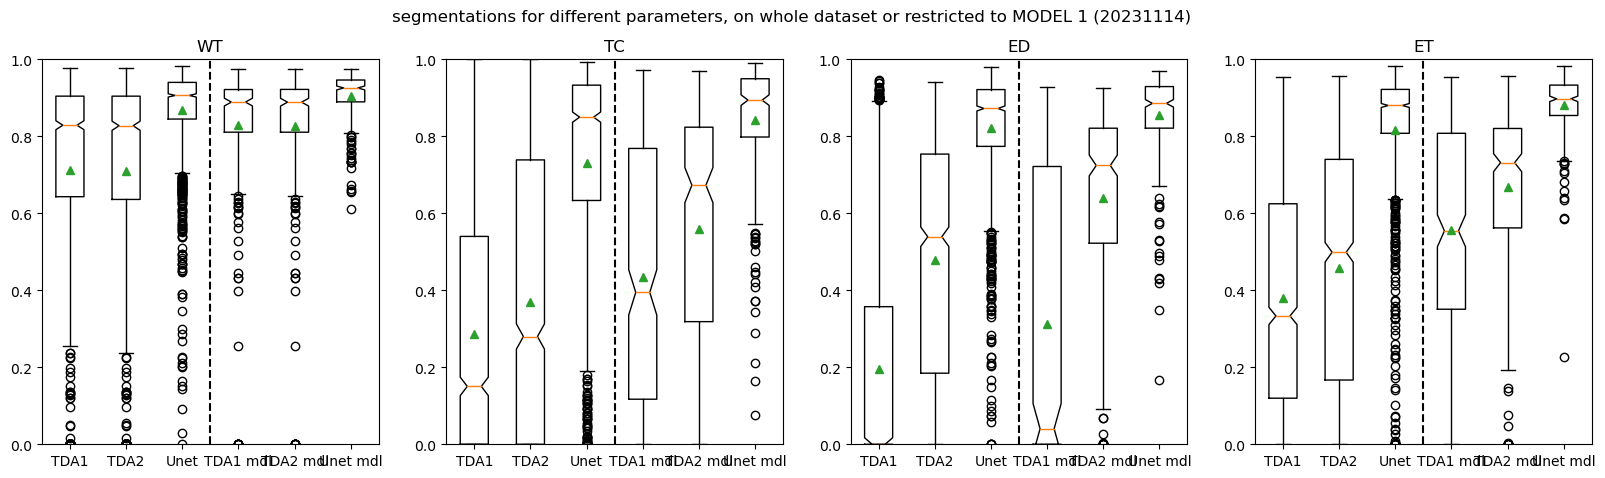

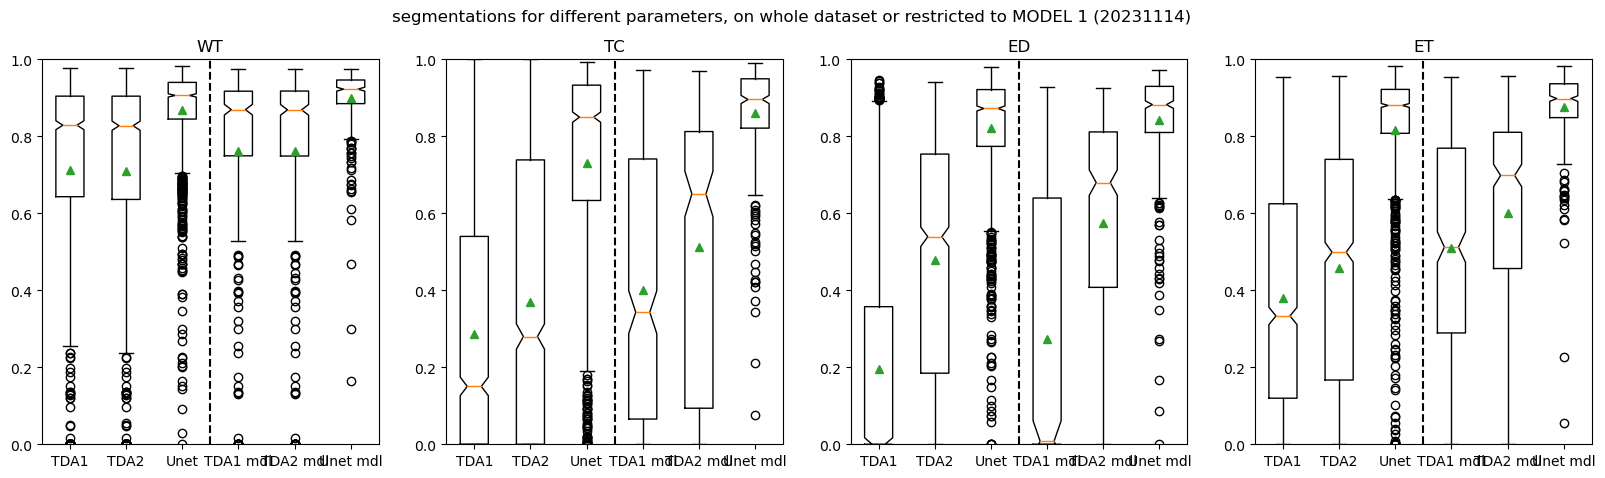

In [807]:
' Compare unet and TDAseg on old model (image article 12/10/2023) and add new parameters '

# Get brains verify model OLD

names_verify_model_old = {df_unet['brats_name'][i]:df_unet['verify_model'][i] for i in range(len(df_unet))}
print('Number satisfying model OLD:' , np.sum(list(names_verify_model_old.values())), '=', round(np.sum(list(names_verify_model_old.values()))/len(names_verify_model_old)*100,2), '%')

# Open first dataframe

df_parameters1 = pd.read_csv('results/summary_cmp_unet_pp.csv')

# Open second dataframe

do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur
dt_threshold = 1       # Step 1, threshold for suggest_t
H2_features_max = 1    # Step 2, number of H2 bars to consider
alpha_boundary = None  # Step 3, parameter to consider inside/outside
radius_ball = 3            # Step 2, dilation parameter

parameters = [do_enhance,normalize,sigma,dt_threshold,H2_features_max,alpha_boundary,radius_ball]
files = glob.glob('results/TDAseg_scores_*')
files = [file for file in files if file[0:len('results/TDAseg_scores_')+len(str(parameters))]=='results/TDAseg_scores_'+str(parameters)]
files_length = [int(file[len('results/TDAseg_scores_')+len(str(parameters))+4:-4]) for file in files]
ind = np.argmax(files_length)
file, i_min = files[ind], files_length[ind]
print('Found', file)
df_parameters2 = pd.read_csv(file)

# Open third dataframe 

df_parameters3 = pd.read_csv('results/summary_cmp_unet_pp.csv')

# Get common names
names = {name:False for name in df_parameters1['brats_name']}
for i in range(len(df_parameters3)): names[df_parameters2['brats_name'][i]] = True
    
' Model 1 '    
    
# Get brains verify model 

thresh_score = 0.0           # lower bound on the scores
thresh_smallTC = 50          # upper bound on the ratio WT/TC, which should be small
thresh_WTconnected = 10      # lower bound on the ratio first/second largest CC, should be high
admissible_argmax = [4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT)

df_VerifyModel = pd.read_csv('results/VerifyModel_20231114_dilation3_len1251.csv')
names_verify_model = {name:False for name in df_VerifyModel['brats_name']}
for i in range(len(df_VerifyModel)):
    names_verify_model[df_VerifyModel['brats_name'][i]] =                                             \
                           (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>thresh_score) \
                       and df_VerifyModel['nonempty'][i]==True                                        \
                       and df_VerifyModel['smallTC'][i]<=thresh_smallTC                               \
                       and df_VerifyModel['WTconnected'][i]>=thresh_WTconnected                       \
                       and df_VerifyModel['argmax'][i] in admissible_argmax \
                       and df_VerifyModel['boundary_TC'][i] > 0.5 \
                       and df_VerifyModel['boundary_ET'][i] < 0.5 \
#                        and df_VerifyModel['mean_ET_t1ce'][i] > 1.2*max(df_VerifyModel['mean_TC_t1ce'][i],df_VerifyModel['mean_ED_t1ce'][i])
                         
print('Brains satisfying the model:' , np.sum(list(names_verify_model.values())), '=', \
      round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel)*100,3), '%')
    
# Plot
fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(20, 5))
segmentation_labels = ['WT','TC','ED','ET']
for label_i, label in enumerate(segmentation_labels):
    seg_1       = [df_parameters1.iloc[i][label+'_allblur1'] for i in range(len(df_parameters1)) \
                                     if names[df_parameters1['brats_name'][i]]]
    seg_2       = [df_parameters2.iloc[i][label] for i in range(len(df_parameters2)) \
                                     if names[df_parameters2['brats_name'][i]]]
    seg_3       = [df_parameters3.iloc[i][label+'_unet'] for i in range(len(df_parameters3)) \
                                     if names[df_parameters3['brats_name'][i]]]
    seg_1_model = [df_parameters1.iloc[i][label+'_allblur1'] for i in range(len(df_parameters1))    \
                                     if names[df_parameters1['brats_name'][i]]            \
                                    and names_verify_model[df_parameters1['brats_name'][i]] ]
    seg_2_model = [df_parameters2.iloc[i][label] for i in range(len(df_parameters2))      \
                                     if names[df_parameters2['brats_name'][i]]            \
                                    and names_verify_model[df_parameters2['brats_name'][i]] ]
    seg_3_model = [df_parameters3.iloc[i][label+'_unet'] for i in range(len(df_parameters3))      \
                                     if names[df_parameters3['brats_name'][i]]            \
                                    and names_verify_model[df_parameters3['brats_name'][i]] ]

    axs[label_i].boxplot([seg_1,seg_2,seg_3,seg_1_model,seg_2_model,seg_3_model], notch=True, showmeans=True);
    axs[label_i].set_title(label)
    axs[label_i].set_ylim(0,1)
    axs[label_i].set_xticklabels(['TDA1','TDA2','Unet', 'TDA1 mdl', 'TDA2 mdl', 'Unet mdl'], fontsize=10)
    
    axs[label_i].axvline(3.5, color='black',ls='--')    
    
plt.suptitle('segmentations for different parameters, on whole dataset or restricted to MODEL 1 (20231114)');


' Model 2 '    
    
# Get brains verify model 

thresh_score = 0.0           # lower bound on the scores
thresh_smallTC = 50          # upper bound on the ratio WT/TC, which should be small
thresh_WTconnected = 10      # lower bound on the ratio first/second largest CC, should be high
admissible_argmax = [0,4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT)

df_VerifyModel = pd.read_csv('results/VerifyModel_20231114_dilation3_len1251.csv')
names_verify_model = {name:False for name in df_VerifyModel['brats_name']}
for i in range(len(df_VerifyModel)):
    names_verify_model[df_VerifyModel['brats_name'][i]] =                                             \
                           (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>thresh_score) \
                       and df_VerifyModel['nonempty'][i]==True                                        \
                       and df_VerifyModel['smallTC'][i]<=thresh_smallTC                               \
                       and df_VerifyModel['WTconnected'][i]>=thresh_WTconnected                       \
                       and df_VerifyModel['argmax'][i] in admissible_argmax \
                       and df_VerifyModel['boundary_TC'][i] > 0.75 \
                       and df_VerifyModel['boundary_ET'][i] < 0.5 
print('Brains satisfying the model:' , np.sum(list(names_verify_model.values())), '=', \
      round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel)*100,3), '%')

# Plot
fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(20, 5))
segmentation_labels = ['WT','TC','ED','ET']
for label_i, label in enumerate(segmentation_labels):
    seg_1       = [df_parameters1.iloc[i][label+'_allblur1'] for i in range(len(df_parameters1)) \
                                     if names[df_parameters1['brats_name'][i]]]
    seg_2       = [df_parameters2.iloc[i][label] for i in range(len(df_parameters2)) \
                                     if names[df_parameters2['brats_name'][i]]]
    seg_3       = [df_parameters3.iloc[i][label+'_unet'] for i in range(len(df_parameters3)) \
                                     if names[df_parameters3['brats_name'][i]]]
    seg_1_model = [df_parameters1.iloc[i][label+'_allblur1'] for i in range(len(df_parameters1))    \
                                     if names[df_parameters1['brats_name'][i]]            \
                                    and names_verify_model[df_parameters1['brats_name'][i]] ]
    seg_2_model = [df_parameters2.iloc[i][label] for i in range(len(df_parameters2))      \
                                     if names[df_parameters2['brats_name'][i]]            \
                                    and names_verify_model[df_parameters2['brats_name'][i]] ]
    seg_3_model = [df_parameters3.iloc[i][label+'_unet'] for i in range(len(df_parameters3))      \
                                     if names[df_parameters3['brats_name'][i]]            \
                                    and names_verify_model[df_parameters3['brats_name'][i]] ]

    axs[label_i].boxplot([seg_1,seg_2,seg_3,seg_1_model,seg_2_model,seg_3_model], notch=True, showmeans=True);
    axs[label_i].set_title(label)
    axs[label_i].set_ylim(0,1)
    axs[label_i].set_xticklabels(['TDA1','TDA2','Unet', 'TDA1 mdl', 'TDA2 mdl', 'Unet mdl'], fontsize=10)
    
    axs[label_i].axvline(3.5, color='black',ls='--')    
    
plt.suptitle('segmentations for different parameters, on whole dataset or restricted to MODEL 1 (20231114)');


# Old model - compute

In [721]:
' Benchmark - Verification of the model - old '

dilatation = 0
do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur

VerifyModel = dict()
pb = parse_brats(brats_list=None,brats_folder='2021',modality='flair')
i_list = range(len(pb.brats_list))

msg = 'Verify model... '
start_time = ChronometerStart(msg)
for i in i_list:
    # Open image
    pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
    img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma,normalize,do_enhance)
    seg_TC = (seg_medecin==1)*1 #TC
    seg_ED = (seg_medecin==2)*1 #ED
    seg_ET = (seg_medecin==4)*1 #ET
    seg_WT = (seg_medecin>0)*1  #WT    
    
    # Verify model new
    verify_model = VerifyHypotheses(seg_medecin,img_flair)
    verify_model['scores'] = QuantifySphericity(seg_medecin,dilatation=dilatation,plot=False)
    verify_model['brats_name'] = pb.brats_list[i]
    
    # Verify model old
    if np.sum(seg_TC)>0 and np.sum(seg_ED)>0 and np.sum(seg_ET)>0:
        # (H2') Compare voxels intensity
        mean_TC = np.mean(img_flair[np.where(seg_TC>0)])
        mean_ED = np.mean(img_flair[np.where(seg_ED>0)])
        mean_ET = np.mean(img_flair[np.where(seg_ET>0)]) 
        verify_model['mean_TC_flair'] = mean_TC
        verify_model['mean_ED_flair'] = mean_ED
        verify_model['mean_ET_flair'] = mean_ET

        mean_TC = np.mean(img_t1ce[np.where(seg_TC>0)])
        mean_ED = np.mean(img_t1ce[np.where(seg_ED>0)])
        mean_ET = np.mean(img_t1ce[np.where(seg_ET>0)]) 
        verify_model['mean_TC_t1ce'] = mean_TC
        verify_model['mean_ED_t1ce'] = mean_ED
        verify_model['mean_ET_t1ce'] = mean_ET
        
        # (H3') Boundary of TC (meanvalue should be > 0.5)
        componentdilated = scipy.ndimage.binary_dilation(seg_TC,iterations=1)
        componentcontour = componentdilated - seg_TC
        meanvalue = np.mean(seg_ET[np.where(componentcontour>0)])
        verify_model['boundary_TC'] = meanvalue
            
        # (H4') Boundary of ET (meanvalue should be < 0.5)
        componentdilated = scipy.ndimage.binary_dilation(seg_ED,iterations=1)
        componentcontour = componentdilated - seg_ED
        meanvalue = np.mean(seg_ET[np.where(componentcontour>0)])
        verify_model['boundary_ET'] = meanvalue
        
    else: 
        verify_model['mean_TC_flair'] = 0
        verify_model['mean_ED_flair'] = 0
        verify_model['mean_ET_flair'] = 0
        verify_model['mean_TC_t1ce'] = 0
        verify_model['mean_ED_t1ce'] = 0
        verify_model['mean_ET_t1ce'] = 0
        verify_model['boundary_TC'] = 0
        verify_model['boundary_ET'] = 0

    
    # Save
    VerifyModel[ pb.brats_list[i_list[i]] ] = verify_model
    ChronometerTick(start_time, i, len(i_list), msg)       
        
# Gather results
df = pd.DataFrame.from_dict(VerifyModel, orient='index')
df.to_csv('results/VerifyModel_20231114_dilation'+str(dilatation)+'_len'+repr(len(df))+'.csv')

Verify model... It 1251/1251. Duration 1:24:13 Expected remaining time 0:00:00.


In [722]:
' Benchmark - Verification of the model - old '

dilatation = 1
do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur

VerifyModel = dict()
pb = parse_brats(brats_list=None,brats_folder='2021',modality='flair')
i_list = range(len(pb.brats_list))

msg = 'Verify model... '
start_time = ChronometerStart(msg)
for i in i_list:
    # Open image
    pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
    img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma,normalize,do_enhance)
    seg_TC = (seg_medecin==1)*1 #TC
    seg_ED = (seg_medecin==2)*1 #ED
    seg_ET = (seg_medecin==4)*1 #ET
    seg_WT = (seg_medecin>0)*1  #WT    
    
    # Verify model new
    verify_model = VerifyHypotheses(seg_medecin,img_flair)
    verify_model['scores'] = QuantifySphericity(seg_medecin,dilatation=dilatation,plot=False)
    verify_model['brats_name'] = pb.brats_list[i]
    
    # Verify model old
    if np.sum(seg_TC)>0 and np.sum(seg_ED)>0 and np.sum(seg_ET)>0:
        # (H2') Compare voxels intensity
        mean_TC = np.mean(img_flair[np.where(seg_TC>0)])
        mean_ED = np.mean(img_flair[np.where(seg_ED>0)])
        mean_ET = np.mean(img_flair[np.where(seg_ET>0)]) 
        verify_model['mean_TC_flair'] = mean_TC
        verify_model['mean_ED_flair'] = mean_ED
        verify_model['mean_ET_flair'] = mean_ET

        mean_TC = np.mean(img_t1ce[np.where(seg_TC>0)])
        mean_ED = np.mean(img_t1ce[np.where(seg_ED>0)])
        mean_ET = np.mean(img_t1ce[np.where(seg_ET>0)]) 
        verify_model['mean_TC_t1ce'] = mean_TC
        verify_model['mean_ED_t1ce'] = mean_ED
        verify_model['mean_ET_t1ce'] = mean_ET
        
        # (H3') Boundary of TC (meanvalue should be > 0.5)
        componentdilated = scipy.ndimage.binary_dilation(seg_TC,iterations=1)
        componentcontour = componentdilated - seg_TC
        meanvalue = np.mean(seg_ET[np.where(componentcontour>0)])
        verify_model['boundary_TC'] = meanvalue
            
        # (H4') Boundary of ET (meanvalue should be < 0.5)
        componentdilated = scipy.ndimage.binary_dilation(seg_ED,iterations=1)
        componentcontour = componentdilated - seg_ED
        meanvalue = np.mean(seg_ET[np.where(componentcontour>0)])
        verify_model['boundary_ET'] = meanvalue
        
    else: 
        verify_model['mean_TC_flair'] = 0
        verify_model['mean_ED_flair'] = 0
        verify_model['mean_ET_flair'] = 0
        verify_model['mean_TC_t1ce'] = 0
        verify_model['mean_ED_t1ce'] = 0
        verify_model['mean_ET_t1ce'] = 0
        verify_model['boundary_TC'] = 0
        verify_model['boundary_ET'] = 0

    
    # Save
    VerifyModel[ pb.brats_list[i_list[i]] ] = verify_model
    ChronometerTick(start_time, i, len(i_list), msg)       
        
# Gather results
df = pd.DataFrame.from_dict(VerifyModel, orient='index')
df.to_csv('results/VerifyModel_20231114_dilation'+str(dilatation)+'_len'+repr(len(df))+'.csv')

Verify model... It 1251/1251. Duration 1:27:42 Expected remaining time 0:00:00.


In [723]:
' Benchmark - Verification of the model - old '

dilatation = 2
do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur

VerifyModel = dict()
pb = parse_brats(brats_list=None,brats_folder='2021',modality='flair')
i_list = range(len(pb.brats_list))

msg = 'Verify model... '
start_time = ChronometerStart(msg)
for i in i_list:
    # Open image
    pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
    img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma,normalize,do_enhance)
    seg_TC = (seg_medecin==1)*1 #TC
    seg_ED = (seg_medecin==2)*1 #ED
    seg_ET = (seg_medecin==4)*1 #ET
    seg_WT = (seg_medecin>0)*1  #WT    
    
    # Verify model new
    verify_model = VerifyHypotheses(seg_medecin,img_flair)
    verify_model['scores'] = QuantifySphericity(seg_medecin,dilatation=dilatation,plot=False)
    verify_model['brats_name'] = pb.brats_list[i]
    
    # Verify model old
    if np.sum(seg_TC)>0 and np.sum(seg_ED)>0 and np.sum(seg_ET)>0:
        # (H2') Compare voxels intensity
        mean_TC = np.mean(img_flair[np.where(seg_TC>0)])
        mean_ED = np.mean(img_flair[np.where(seg_ED>0)])
        mean_ET = np.mean(img_flair[np.where(seg_ET>0)]) 
        verify_model['mean_TC_flair'] = mean_TC
        verify_model['mean_ED_flair'] = mean_ED
        verify_model['mean_ET_flair'] = mean_ET

        mean_TC = np.mean(img_t1ce[np.where(seg_TC>0)])
        mean_ED = np.mean(img_t1ce[np.where(seg_ED>0)])
        mean_ET = np.mean(img_t1ce[np.where(seg_ET>0)]) 
        verify_model['mean_TC_t1ce'] = mean_TC
        verify_model['mean_ED_t1ce'] = mean_ED
        verify_model['mean_ET_t1ce'] = mean_ET
        
        # (H3') Boundary of TC (meanvalue should be > 0.5)
        componentdilated = scipy.ndimage.binary_dilation(seg_TC,iterations=1)
        componentcontour = componentdilated - seg_TC
        meanvalue = np.mean(seg_ET[np.where(componentcontour>0)])
        verify_model['boundary_TC'] = meanvalue
            
        # (H4') Boundary of ET (meanvalue should be < 0.5)
        componentdilated = scipy.ndimage.binary_dilation(seg_ED,iterations=1)
        componentcontour = componentdilated - seg_ED
        meanvalue = np.mean(seg_ET[np.where(componentcontour>0)])
        verify_model['boundary_ET'] = meanvalue
        
    else: 
        verify_model['mean_TC_flair'] = 0
        verify_model['mean_ED_flair'] = 0
        verify_model['mean_ET_flair'] = 0
        verify_model['mean_TC_t1ce'] = 0
        verify_model['mean_ED_t1ce'] = 0
        verify_model['mean_ET_t1ce'] = 0
        verify_model['boundary_TC'] = 0
        verify_model['boundary_ET'] = 0

    
    # Save
    VerifyModel[ pb.brats_list[i_list[i]] ] = verify_model
    ChronometerTick(start_time, i, len(i_list), msg)       
        
# Gather results
df = pd.DataFrame.from_dict(VerifyModel, orient='index')
df.to_csv('results/VerifyModel_20231114_dilation'+str(dilatation)+'_len'+repr(len(df))+'.csv')

Verify model... It 1251/1251. Duration 1:29:00 Expected remaining time 0:00:00.


In [ ]:
# ' Benchmark - Verification of the model '

# verbose = False

# pb = parse_brats(brats_list=None,brats_folder='2021',modality='flair')
# i_list = range(len(pb.brats_list))

# VerifyModel, VerifyModel_list = dict(), list()

# msg = 'Verify model... '
# start_time = ChronometerStart(msg)
# for i in i_list:
#     ChronometerTick(start_time, i, len(i_list), msg)   
#     if verbose: print(); print();
    
#     # Open image
#     sigma = 1
#     pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
#     img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma)

#     # Define components 
#     seg_TC = (seg_medecin==1)*1 #TC
#     seg_ED = (seg_medecin==2)*1 #ED
#     seg_ET = (seg_medecin==4)*1 #ET
#     seg_WT = (seg_medecin>0)*1  #WT
    
#     filename = pb.brats_list[i]
#     VerifyModel[filename] = [None,None,None,None]
#     if np.sum(seg_TC)>0 and np.sum(seg_ED)>0 and np.sum(seg_ET)>0:
#         if verbose: print('Image', filename)

#         # (H1') Verify if exactly one CC
#         max_cardinal_smallcomponents = 100   #only CC of cardinal at least 100
#         labels = skimage.measure.label(seg_WT, background=0)
#         components = [(labels==l)*1 for l in range(1,np.max(labels)+1)]
#         n_components = len([component for component in components if np.sum(component)>=max_cardinal_smallcomponents])                    
#         VerifyModel[filename][0] = n_components==1
#         if verbose: print('WT, nb of CCs:', len(components), '- big CCs:', n_components, '-', sorted([np.sum(component) for component in components if np.sum(component)>=max_cardinal_smallcomponents])[::-1])

#         if False in VerifyModel[filename]: continue    
            
#         # (H1') Verify if argmax is in ET
#         VerifyModel[filename][0] = VerifyModel[filename][0] and seg_ET[argmax_image(img_flair)]
            
#         if False in VerifyModel[filename]: continue    
            
#         # (H2') Verify if exactly one CC
#         max_cardinal_smallcomponents = 100   #only CC of cardinal at least 100
#         labels = skimage.measure.label(seg_ET, background=0)
#         components = [(labels==l)*1 for l in range(1,np.max(labels)+1)]
#         n_components = len([component for component in components if np.sum(component)>=max_cardinal_smallcomponents])                    
#         VerifyModel[filename][1] = n_components==1
#         if verbose: print('ET, nb of CCs:', len(components), '- big CCs:', n_components, '-', sorted([np.sum(component) for component in components if np.sum(component)>=max_cardinal_smallcomponents])[::-1])

#         if False in VerifyModel[filename]: continue    
            
#         # (H2') Compare voxels intensity
#         mean_TC = np.mean(img_t1ce[np.where(seg_TC>0)])
#         mean_ED = np.mean(img_t1ce[np.where(seg_ED>0)])
#         mean_ET = np.mean(img_t1ce[np.where(seg_ET>0)])      
#         VerifyModel[filename][1] = VerifyModel[filename][1] and (mean_ET>mean_TC) and (mean_ET>mean_ED)
#         if verbose: print('Mean TC, ED & ET:', mean_TC, mean_ED, mean_ET)
        
#         if False in VerifyModel[filename]: continue
        
#         # (H2') Test sphericity
#         min_cardinal_interiorcomponents = 500   #only CC of cardinal at least 500
# #         seg_complement = (seg_ET*0+1)-seg_ET
#         seg_complement = (seg_ET*0+1)-scipy.ndimage.binary_dilation(seg_ET,iterations=1)
#         labels = skimage.measure.label(seg_complement, background=0)
#         components = [(labels==l)*1 for l in range(1,np.max(labels)+1)]
#         components_len = sorted([np.sum(component) for component in components])[::-1]
#         components_len.pop(0)
#         VerifyModel[filename][1] = VerifyModel[filename][1] and (np.sum(components_len)>=min_cardinal_interiorcomponents)
# #         print('Complementary ET, nb of CCs:', len(components), ' size of complement', np.sum(components_len), '-', sorted([np.sum(component) for component in components])[::-1])        
# #         print(i,np.sum(seg_TC))
        
#         if False in VerifyModel[filename]: continue
    
#         # (H3')
#         componentdilated = scipy.ndimage.binary_dilation(seg_TC,iterations=1)
#         componentcontour = componentdilated - seg_TC
#         meanvalue = np.mean(seg_ET[np.where(componentcontour>0)])
#         VerifyModel[filename][2] = meanvalue>0.5
#         if verbose: print('TC, indise/outside:', meanvalue, '> 0.5')

#         if False in VerifyModel[filename]: continue
            
#         # (H4')
#         componentdilated = scipy.ndimage.binary_dilation(seg_ED,iterations=1)
#         componentcontour = componentdilated - seg_ED
#         meanvalue = np.mean(seg_ET[np.where(componentcontour>0)])
#         VerifyModel[filename][3] = meanvalue<0.5
#         if verbose: print('TC, indise/outside:', meanvalue, '< 0.5')
            
#         if VerifyModel[filename]==[True,True,True,True]: VerifyModel_list.append(i)
        
# # Gather results
# VerifyModel = {filename:(VerifyModel[filename]==[True,True,True,True]) for filename in VerifyModel}
# mean_verifymodel = np.mean(list(VerifyModel.values()))
# print('Proportion of images verifying the model:', mean_verifymodel)

# New model - characteristics

In [665]:
' Verify model - characteristics on dataframe '

# Open model

df_VerifyModel = pd.read_csv('results/VerifyModel_dilatation1_len1251.csv')

# Open dataframe

do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur
dt_threshold = 1       # Step 1, threshold for suggest_t
H2_features_max = 2    # Step 2, number of H2 bars to consider
alpha_boundary = None  # Step 3, parameter to consider inside/outside
radius_ball = 3            # Step 2, dilation parameter

parameters = [do_enhance,normalize,sigma,dt_threshold,H2_features_max,alpha_boundary,radius_ball]
files = glob.glob('results/TDAseg_scores_*')
files = [file for file in files if file[0:len('results/TDAseg_scores_')+len(str(parameters))]=='results/TDAseg_scores_'+str(parameters)]
files_length = [int(file[len('results/TDAseg_scores_')+len(str(parameters))+4:-4]) for file in files]
ind = np.argmax(files_length)
file, i_min = files[ind], files_length[ind]
print('Found', file)
df_parameters = pd.read_csv(file)

# Get common names
# names = {df_VerifyModel['brats_name'][i]:False for i in range(len(df_VerifyModel))}
# for i in range(len(df_parameters)): names[df_parameters['brats_name'][i]] = True    
names_df = [df_parameters['brats_name'][i] for i in range(len(df_parameters))]
indices_df = list(range(len(df_parameters)))
indices_model = [df_VerifyModel.index[df_VerifyModel['brats_name']==names_df[i]][0] for i in range(len(df_parameters))]

Found results/TDAseg_scores_[False, 'max', 1, 1, 2, None, 3]_len431.csv


In [692]:
# With oracle (names_verify_model)
names_df = [name for name in names_verify_model if names_verify_model[name]]
indices_df = [df_parameters.index[df_parameters['brats_name']==names_df[i]][0] for i in range(len(names_df))]
indices_model = [df_VerifyModel.index[df_VerifyModel['brats_name']==names_df[i]][0] for i in range(len(names_df))]

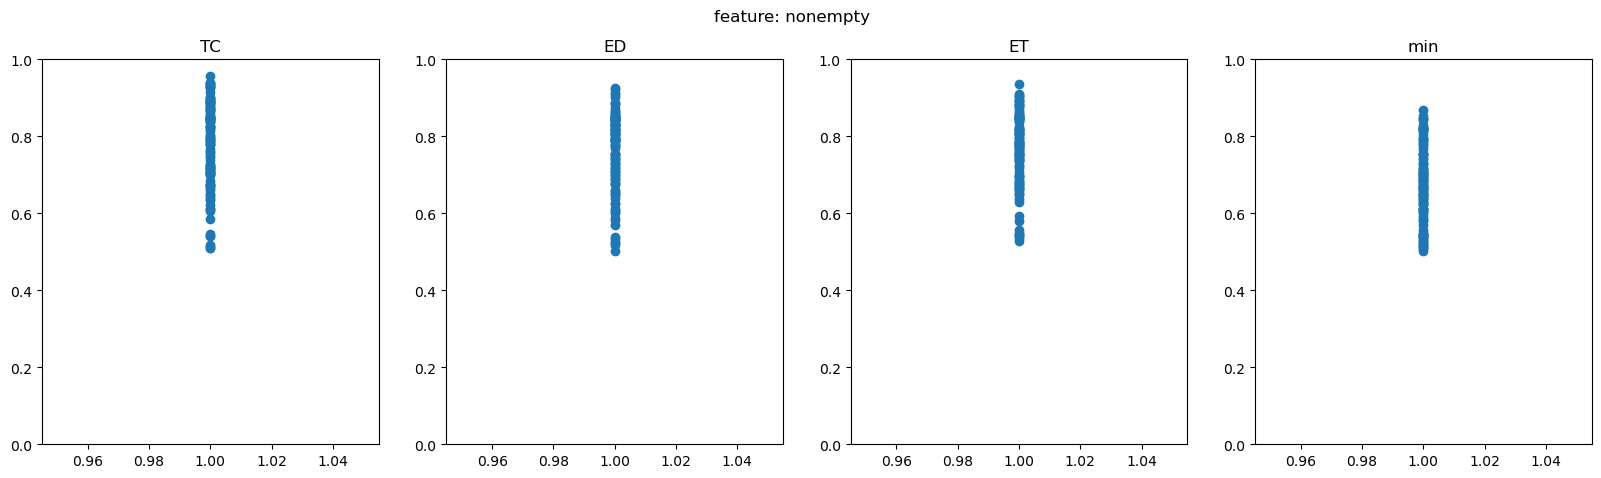

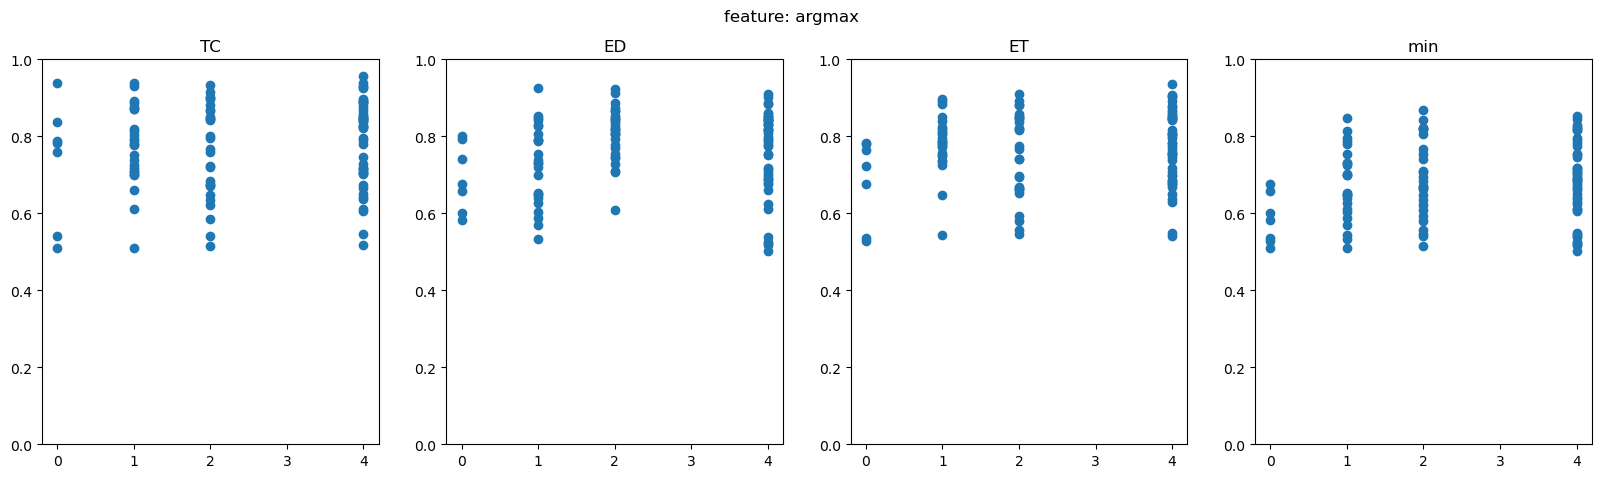

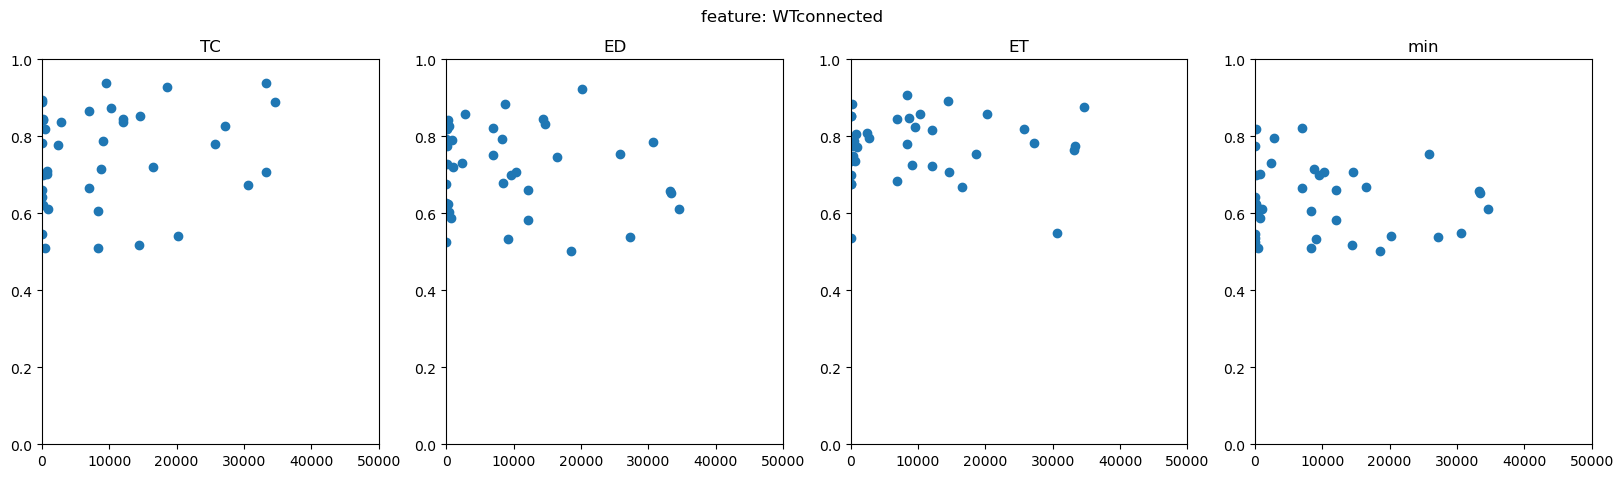

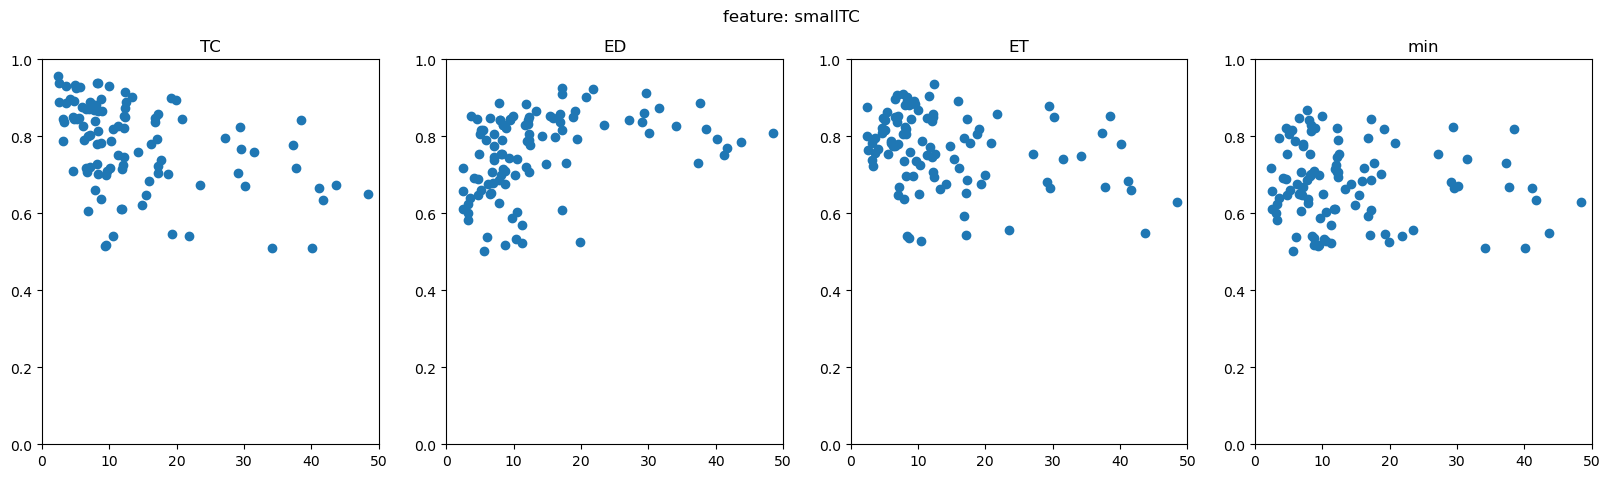

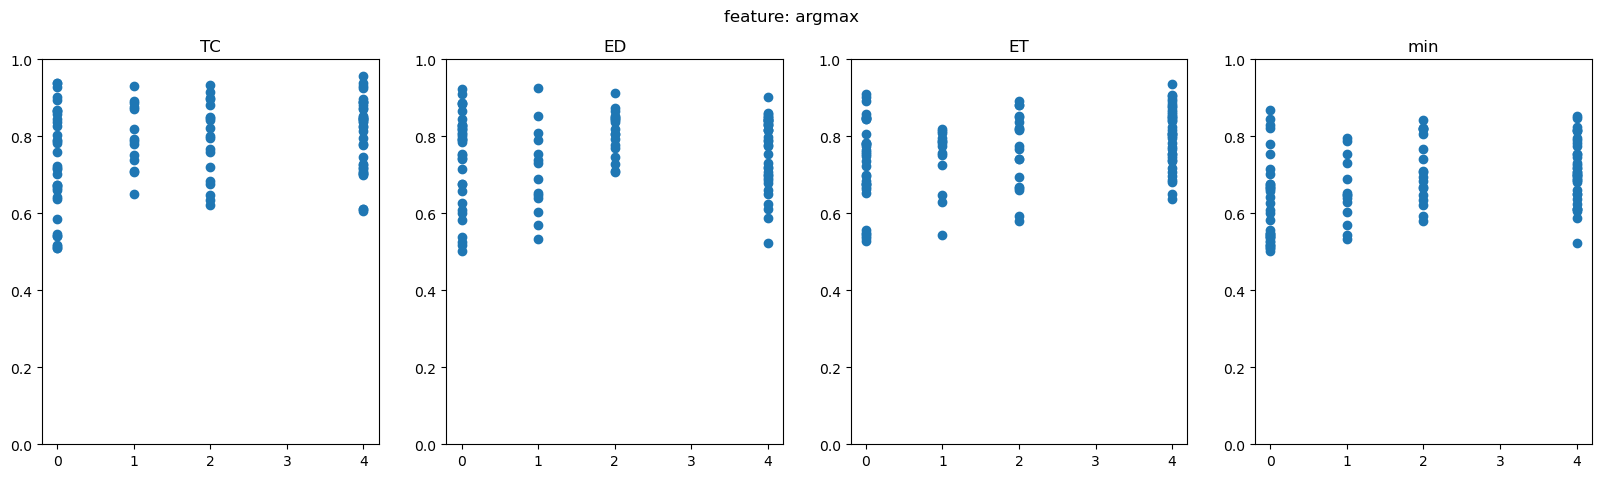

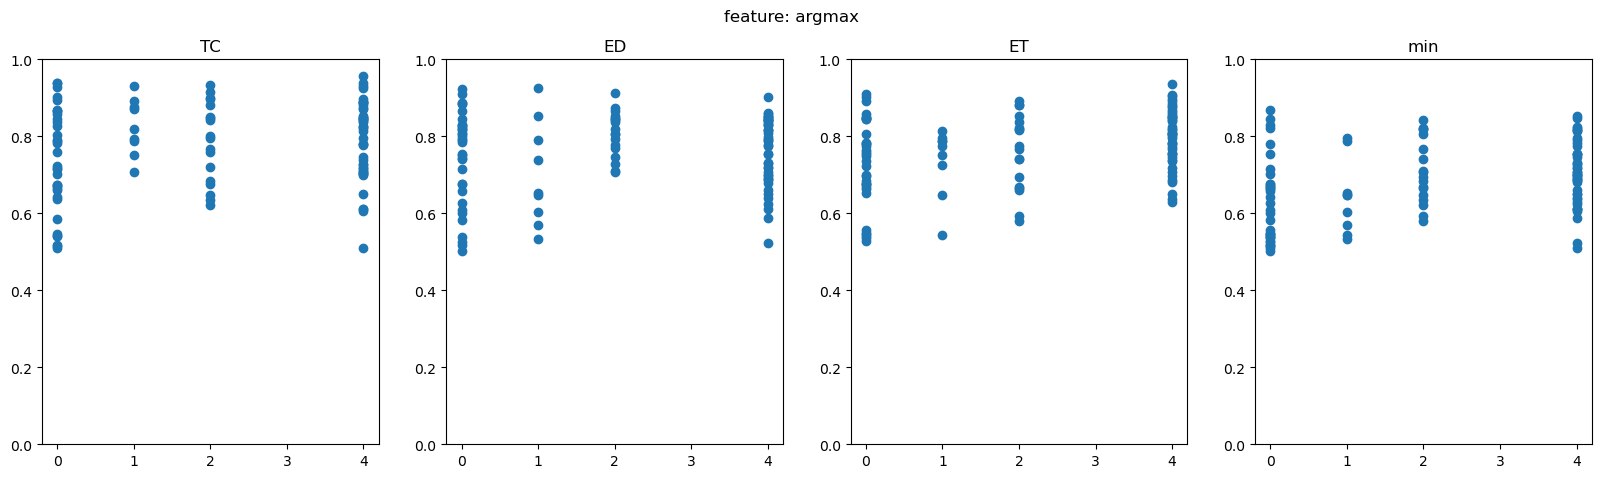

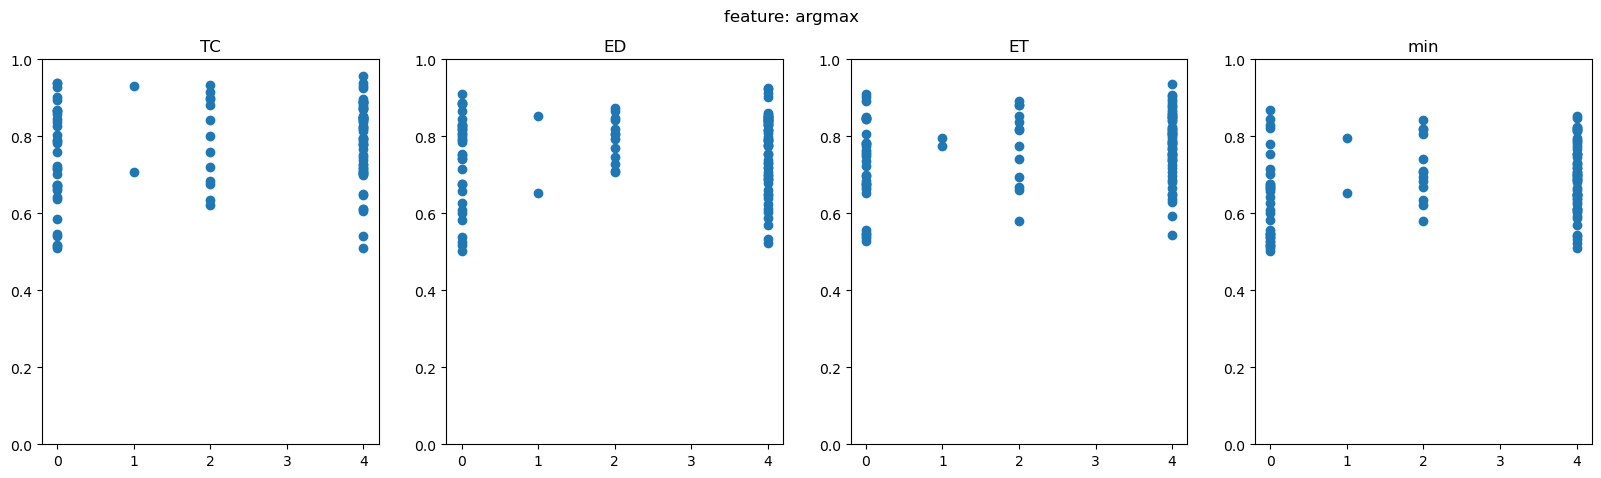

In [702]:
for feature in ['nonempty','argmax','WTconnected','smallTC']:
    model_x = [df_VerifyModel[feature][i] for i in indices_model]
    model_TC = [df_parameters['TC'][i] for i in indices_df]
    model_ED = [df_parameters['ED'][i] for i in indices_df]
    model_ET = [df_parameters['ET'][i] for i in indices_df]
    model_min = [min(model_TC[i],model_ED[i],model_ET[i]) for i in range(len(indices_df))]
    model_y = [model_TC,model_ED,model_ET,model_min]

    # Plot
    fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(20, 5))
    segmentation_labels = ['TC','ED','ET', 'min']
    for label_i, label in enumerate(segmentation_labels):
        axs[label_i].scatter(model_x,model_y[label_i])
        axs[label_i].set_title(label)
        axs[label_i].set_ylim(0,1)
        if feature=='WTconnected': axs[label_i].set_xlim(0,50000)
        if feature=='smallTC': axs[label_i].set_xlim(0,50)
    plt.suptitle('feature: '+feature)
    
for VerifyModel_neighbor in [VerifyModel_neighbor0,VerifyModel_neighbor1,VerifyModel_neighbor2]:
    feature = 'argmax'    
    model_x = [VerifyModel_neighbor[name] for name in names_df]
    model_TC = [df_parameters['TC'][i] for i in indices_df]
    model_ED = [df_parameters['ED'][i] for i in indices_df]
    model_ET = [df_parameters['ET'][i] for i in indices_df]
    model_min = [min(model_TC[i],model_ED[i],model_ET[i]) for i in range(len(indices_df))]
    model_y = [model_TC,model_ED,model_ET,model_min]

    # Plot
    fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(20, 5))
    segmentation_labels = ['TC','ED','ET', 'min']
    for label_i, label in enumerate(segmentation_labels):
        axs[label_i].scatter(model_x,model_y[label_i])
        axs[label_i].set_title(label)
        axs[label_i].set_ylim(0,1)
    plt.suptitle('feature: '+feature)

# Get images that satisfy the model

In [717]:
def VerifyHypotheses(seg_medecin,img_flair):
    verify_model = {'nonempty':None, 'WTconnected':None, 'argmax':None}
    # Define components 
    seg_TC = (seg_medecin==1)*1 #TC
    seg_ED = (seg_medecin==2)*1 #ED
    seg_ET = (seg_medecin==4)*1 #ET
    seg_WT = (seg_medecin>0)*1  #WT
    
    # Components are nonempty
    verify_model['nonempty'] = (np.sum(seg_TC)>0 and np.sum(seg_ED)>0 and np.sum(seg_ET)>0) 

    # Size of TC relative to WT (should be lower than 50)
    if np.sum(seg_TC)==0: verify_model['smallTC'] = np.inf
    else:                 verify_model['smallTC'] = np.sum(seg_WT)/np.sum(seg_TC)
    
    # CC of WT (ratio of largest CC over second largest, should be at least 10)
    labels = skimage.measure.label(seg_WT, background=0)
    components = [(labels==l)*1 for l in range(1,np.max(labels)+1)]
    size_components = np.flip(np.sort([np.sum(component) for component in components]))
    if len(size_components)==1: verify_model['WTconnected'] = np.inf
    else:                       verify_model['WTconnected'] = size_components[0]/size_components[1]
        
    # Verify if argmax is in ET (should be 1 for ET, >0 for WT)
    verify_model['argmax'] = seg_medecin[argmax_image(img_flair)]      
    
    return verify_model

def QuantifySphericity(seg_medecin,dilatation=0,plot=False,verbose=False):
    # Define components 
    seg_TC = (seg_medecin==1)*1 #TC
    seg_ED = (seg_medecin==2)*1 #ED
    seg_ET = (seg_medecin==4)*1 #ET
    seg_WT = (seg_medecin>0)*1  #WT
    
    # Dilate
    for i in range(dilatation): seg_ET = scipy.ndimage.binary_dilation(seg_ET,iterations=1)
    seg_medecin[seg_ET>0] = 4 #/!\ modification of seg_medecin here, to get fair results

    # Extract CC
    seg_complement = 1 - seg_ET
    labels = skimage.measure.label(seg_complement, background=0)
    components = [(labels==i)*1 for i in range(1,np.max(labels)+1)]

    # Define ED
    components_len = [np.sum(component) for component in components]
    imax_comp = np.argmax(components_len)
    component_ED = components[imax_comp]*seg_WT
    components.pop(imax_comp)

    # Define TC
    component_TC = np.sum(components,0)

    # Define seg and plot
    seg_final = seg_ET.copy()*4    #define seg_final
    seg_final[component_ED>0] = 2
    seg_final[component_TC>0] = 1
    
    scores = GetDICEs(seg_final,seg_medecin,verbose=verbose)
    
    # Plot 
    if plot: PlotSegmentation(pb,img_flair,seg_final,figsize=(6,2))
    
    return scores

In [195]:
' Benchmark - Verification of the model '

dilatation = 0
do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur

VerifyModel = dict()
pb = parse_brats(brats_list=None,brats_folder='2021',modality='flair')
i_list = range(len(pb.brats_list))

msg = 'Verify model... '
start_time = ChronometerStart(msg)
for i in i_list:
    # Open image
    pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
    img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma,normalize,do_enhance)

    # Verify model
    verify_model = VerifyHypotheses(seg_medecin,img_flair)
    verify_model['scores'] = QuantifySphericity(seg_medecin,dilatation=dilatation,plot=False)
    verify_model['brats_name'] = pb.brats_list[i]
    VerifyModel[ pb.brats_list[i_list[i]] ] = verify_model

    ChronometerTick(start_time, i, len(i_list), msg)       
        
# Gather results
df = pd.DataFrame.from_dict(VerifyModel, orient='index')
df.to_csv('results/VerifyModel_dilatation'+str(dilatation)+'_len'+repr(len(df))+'.csv')

Verify model... It 1251/1251. Duration 1:04:18 Expected remaining time 0:00:00.


# Boxplot - reproduce image article 12/10/2023

In [14]:
# Open dataframes

df_unet = pd.read_csv('results/summary_cmp_unet_pp.csv')
df_VerifyModel = pd.read_csv('results/VerifyModel_dilatation0_len1251_old.csv')

Number satisfying model OLD: 119 = 9.52 %


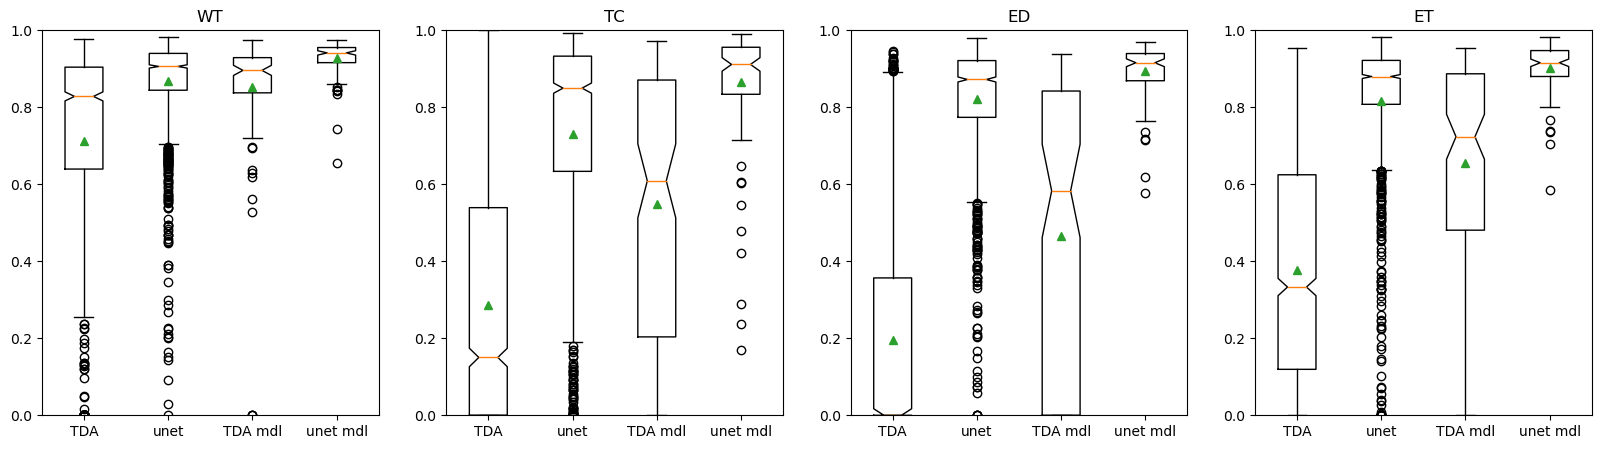

In [17]:
' Compare unet and TDAseg on old model (Reproduce image article 12/10/2023) '

# Get brains verify model OLD

names_verify_model_old = {df_unet['brats_name'][i]:df_unet['verify_model'][i] for i in range(len(df_unet))}
print('Number satisfying model OLD:' , np.sum(list(names_verify_model_old.values())), '=', round(np.sum(list(names_verify_model_old.values()))/len(names_verify_model_old)*100,2), '%')

# Boxplots OLD

fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(20, 5))

segmentation_labels = ['WT','TC','ED','ET']
for label_i, label in enumerate(segmentation_labels):
    seg_tda        = [df_unet.iloc[i][label+'_allblur1'] for i in range(len(df_unet))]
    seg_unet       = [df_unet.iloc[i][label+'_unet'] for i in range(len(df_unet))]

    seg_tda_model  = [df_unet.iloc[i][label+'_allblur1'] for i in range(len(df_unet)) 
                                     if names_verify_model_old[df_unet['brats_name'][i]]]
    seg_unet_model = [df_unet.iloc[i][label+'_unet'] for i in range(len(df_unet))
                                     if names_verify_model_old[df_unet['brats_name'][i]]]
    
    axs[label_i].boxplot([seg_tda,seg_unet,seg_tda_model,seg_unet_model], notch=True, showmeans=True);
    axs[label_i].set_title(label)
    axs[label_i].set_ylim(0,1)
    axs[label_i].set_xticklabels(['TDA','unet', 'TDA mdl', 'unet mdl'])

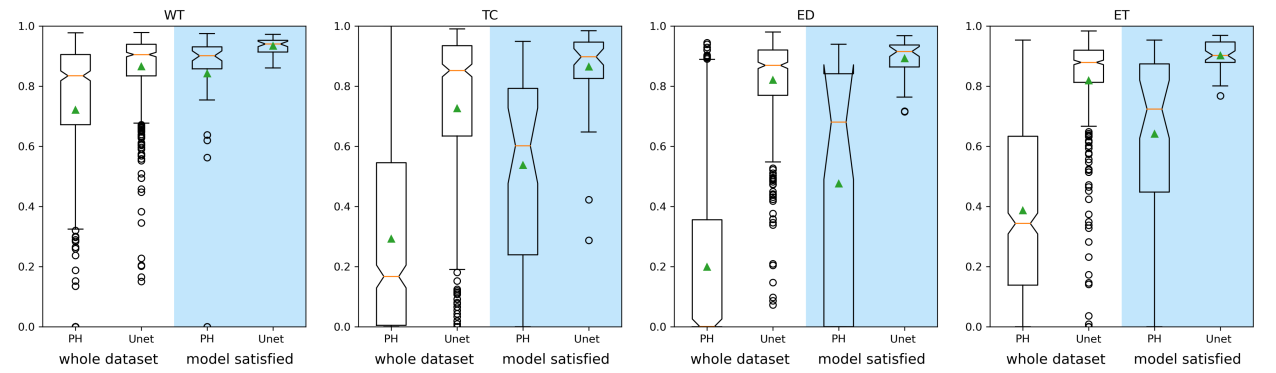

### New figure - Compare with unet

In [576]:
# Open dataframe unet

df_unet = pd.read_csv('results/summary_cmp_unet_pp.csv')
df_parameters2 = df_unet.iloc[:,[0,1,2,3,4]].rename(columns={'brats_name':'brats_name','WT_unet':'WT', \
                                            'TC_unet': 'TC',  'ET_unet': 'ET',  'ED_unet': 'ED'})

# Open dataframe PH

do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur
dt_threshold = 1       # Step 1, threshold for suggest_t
H2_features_max = 5    # Step 2, number of H2 bars to consider
alpha_boundary = None  # Step 3, parameter to consider inside/outside

parameters = [do_enhance,normalize,sigma,dt_threshold,H2_features_max,alpha_boundary]
files = glob.glob('results/TDAseg_scores_*')
files = [file for file in files if file[0:len('results/TDAseg_scores_')+len(str(parameters))]=='results/TDAseg_scores_'+str(parameters)]
files_length = [int(file[len('results/TDAseg_scores_')+len(str(parameters))+4:-4]) for file in files]
ind = np.argmax(files_length)
file, i_min = files[ind], files_length[ind]
print('Found', file)
df_parameters1 = pd.read_csv(file)

# Get names step3
names = {name:False for name in df_parameters1['brats_name']}
for i in range(len(df_parameters2)): names[df_parameters2['brats_name'][i]] = True

Found results/TDAseg_scores_[False, 'max', 1, 1, 5, None]_len1251.csv


In [124]:
# Open dataframe PH

do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur
dt_threshold = 1       # Step 1, threshold for suggest_t
H2_features_max = 5    # Step 2, number of H2 bars to consider
alpha_boundary = None  # Step 3, parameter to consider inside/outside

parameters = [do_enhance,normalize,sigma,dt_threshold,H2_features_max,alpha_boundary]
files = glob.glob('results/TDAseg_scores_*')
files = [file for file in files if file[0:len('results/TDAseg_scores_')+len(str(parameters))]=='results/TDAseg_scores_'+str(parameters)]
files_length = [int(file[len('results/TDAseg_scores_')+len(str(parameters))+4:-4]) for file in files]
ind = np.argmax(files_length)
file, i_min = files[ind], files_length[ind]
print('Found', file)
df_parameters1 = pd.read_csv(file)

# Get names step3
names = {name:False for name in df_parameters1['brats_name']}
for i in range(len(df_parameters2)): names[df_parameters2['brats_name'][i]] = True

Found results/TDAseg_scores_[False, 'max', 1, 1, 5, None]_len1251.csv


In [141]:
# Get brains verify model OLD

names_verify_model = {df_unet['brats_name'][i]:df_unet['verify_model'][i] for i in range(len(df_unet))}
print('Number satisfying model OLD:' , np.sum(list(names_verify_model.values())), '=', round(np.sum(list(names_verify_model.values()))/len(names_verify_model)*100,2), '%')

Number satisfying model OLD: 119 = 9.52 %


In [276]:
# Get brains verify model - new 12/10/ - 0 dilatation

thresh_score = 0.9           # lower bound on the scores
thresh_smallTC = 50          # upper bound on the ratio WT/TC, which should be small
thresh_WTconnected = 10      # lower bound on the ratio first/second largest CC, should be high
admissible_argmax = [1,2,4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT)

# thresh_score = 0.0           # lower bound on the scores
# thresh_smallTC = 10          # upper bound on the ratio WT/TC, which should be small
# thresh_WTconnected = 10      # lower bound on the ratio first/second largest CC, should be high
# admissible_argmax = [1,2,4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT)

df_VerifyModel = pd.read_csv('results/VerifyModel_dilatation0_len1251.csv')
names_verify_model = {name:False for name in df_VerifyModel['brats_name']}
for i in range(len(df_VerifyModel)):
    names_verify_model[df_VerifyModel['brats_name'][i]] =                                             \
                           (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>thresh_score) \
                       and df_VerifyModel['nonempty'][i]==True                                        \
                       and df_VerifyModel['smallTC'][i]<=thresh_smallTC                               \
                       and df_VerifyModel['WTconnected'][i]>=thresh_WTconnected                       \
                       and df_VerifyModel['argmax'][i] in admissible_argmax

print('Brains satisfying the model:' , np.sum(list(names_verify_model.values())), '=', \
      round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel)*100,3), '%')

Brains satisfying the model: 145 = 11.591 %


In [348]:
# Get brains verify model - circle

alpha = 0.5
alpha2 = 0.1
names_verify_model = {name:(VerifyModel[name]>alpha and \
                            df_parameters1[df_parameters1['brats_name']==name].iloc[0]['ET']>alpha2) \
                      for name in VerifyModel}

print('Number satisfying model CIRCLE:' , np.sum(list(names_verify_model.values())), '=', round(np.sum(list(names_verify_model.values()))/len(names_verify_model)*100,2), '%')

Number satisfying model CIRCLE: 256 = 20.46 %


In [384]:
# Get brains verify model - circle

alpha = 0.2
alpha2 = 0.25
names_verify_model = {name:(VerifyModel[name]>alpha and \
                            df_parameters1[df_parameters1['brats_name']==name].iloc[0]['ET']>alpha2) \
                      for name in VerifyModel}

print('Number satisfying model CIRCLE:' , np.sum(list(names_verify_model.values())), '=', round(np.sum(list(names_verify_model.values()))/len(names_verify_model)*100,2), '%')

Number satisfying model CIRCLE: 394 = 31.49 %


In [380]:
# Get brains verify model - circle

alpha = 0.8
names_verify_model = {name:(VerifyModel[name]>alpha and \
                            df_VerifyModel[df_VerifyModel['brats_name']==name].iloc[0]['argmax']==4) \
                      for name in VerifyModel}

print('Number satisfying model CIRCLE:' , np.sum(list(names_verify_model.values())), '=', round(np.sum(list(names_verify_model.values()))/len(names_verify_model)*100,2), '%')

Number satisfying model CIRCLE: 208 = 16.63 %


In [417]:
VerifyModel = pd.read_csv('results/VerifyModel_separatingcircle_len1251_dilate1.csv').set_index('Unnamed: 0').to_dict()['0']
# VerifyModel = pd.read_csv('results/VerifyModel_separatingcircle_len1251_dilate0.csv').set_index('Unnamed: 0').to_dict()['0']

In [565]:
# Get brains verify model - oracle

alpha = 0.5
names_verify_model = {df_parameters1['brats_name'][i]:\
#                       (df_parameters1['TC'][i]>alpha and df_parameters1['ED'][i]>alpha) \
                      df_parameters1['ET'][i]>alpha \
                      for i in range(len(df_parameters1))}
names_verify_model['BraTS2021_01340'] = False
names_verify_model['BraTS2021_01601'] = False
names_verify_model['BraTS2021_01030'] = False
names_verify_model['BraTS2021_01112'] = False
names_verify_model['BraTS2021_00152'] = False
print('Number satisfying model ORACLE:' , np.sum(list(names_verify_model.values())), '=', round(np.sum(list(names_verify_model.values()))/len(names_verify_model)*100,2), '%')

Number satisfying model ORACLE: 418 = 33.41 %


In [578]:
# Get brains verify model - 1 dilatation - circle 

# thresh_score = 0.0           # lower bound on the scores
# thresh_smallTC = 50          # upper bound on the ratio WT/TC, which should be small
# thresh_WTconnected = 10      # lower bound on the ratio first/second largest CC, should be high
# admissible_argmax = [1,2,4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT)

thresh_score = 0.0           # lower bound on the scores
thresh_smallTC = 50          # upper bound on the ratio WT/TC, which should be small
thresh_WTconnected = 10      # lower bound on the ratio first/second largest CC, should be high
admissible_argmax = [1,2,4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT)

df_VerifyModel = pd.read_csv('results/VerifyModel_dilatation0_len1251.csv')
names_verify_model = {name:False for name in df_VerifyModel['brats_name']}
for i in range(len(df_VerifyModel)):
    names_verify_model[df_VerifyModel['brats_name'][i]] =                                             \
                           (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>thresh_score) \
                       and df_VerifyModel['nonempty'][i]==True                                        \
                       and df_VerifyModel['smallTC'][i]<=thresh_smallTC                               \
                       and df_VerifyModel['WTconnected'][i]>=thresh_WTconnected                       \
                       and df_VerifyModel['argmax'][i] in admissible_argmax \
                            and VerifyModel_neighbor2[df_VerifyModel['brats_name'][i]]==4\
                            and VerifyModel[df_VerifyModel['brats_name'][i]] > 0.1

print('Brains satisfying the model:' , np.sum(list(names_verify_model.values())), '=', \
      round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel)*100,3), '%')

Brains satisfying the model: 179 = 14.309 %


1251 1250
1250 1250
179 179


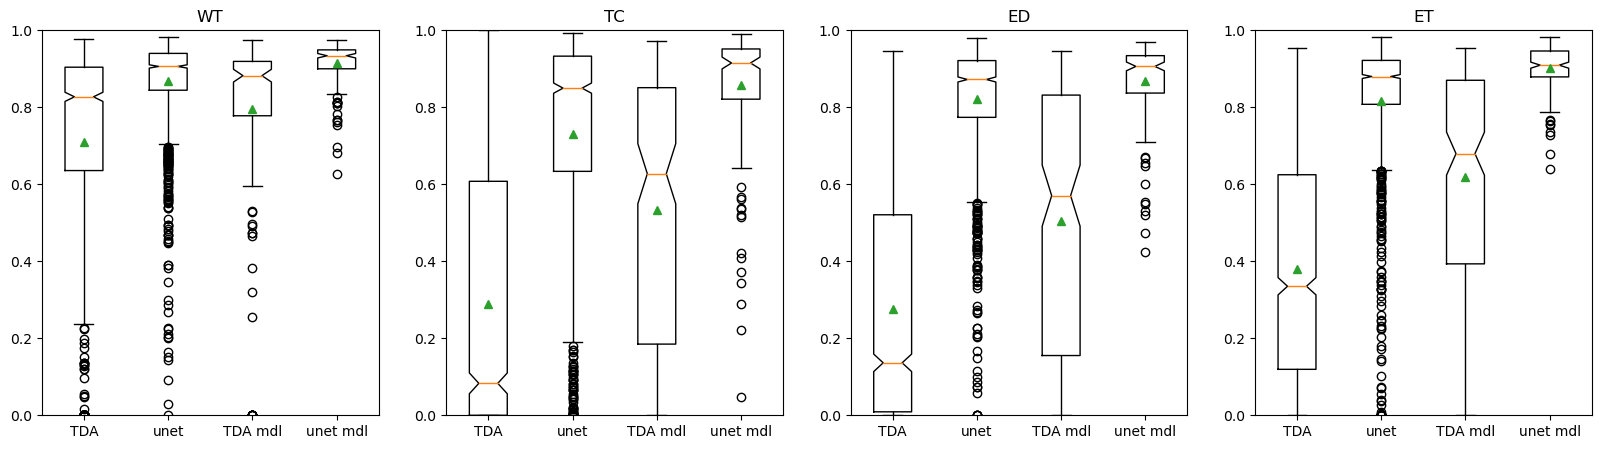

In [579]:
# Boxplots - restricted to indices of df_parameters2

fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(20, 5))

segmentation_labels = ['WT','TC','ED','ET']
for label_i, label in enumerate(segmentation_labels):
    seg_1       = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))
                                     if names[df_parameters1['brats_name'][i]]]
    seg_2       = [df_parameters2.iloc[i][label] for i in range(len(df_parameters2))
                                     if names[df_parameters2['brats_name'][i]]]
    seg_1_model = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))    \
                                     if names[df_parameters1['brats_name'][i]]            \
                                    and names_verify_model[df_parameters1['brats_name'][i]] ]
    seg_2_model = [df_parameters2.iloc[i][label] for i in range(len(df_parameters2))      \
                                     if names[df_parameters2['brats_name'][i]]            \
                                    and names_verify_model[df_parameters2['brats_name'][i]] ]
    
    axs[label_i].boxplot([seg_1,seg_2,seg_1_model,seg_2_model], notch=True, showmeans=True);
    axs[label_i].set_title(label)
    axs[label_i].set_ylim(0,1)
    axs[label_i].set_xticklabels(['TDA','unet', 'TDA mdl', 'unet mdl'])
#     plt.suptitle('old parameters VS new parameters, on whole dataset or restricted to model')

print(len(df_parameters1),len(df_parameters2))
print(len(seg_1),len(seg_2))
print(len(seg_1_model),len(seg_2_model))

1251 1250
1250 1250
50 50


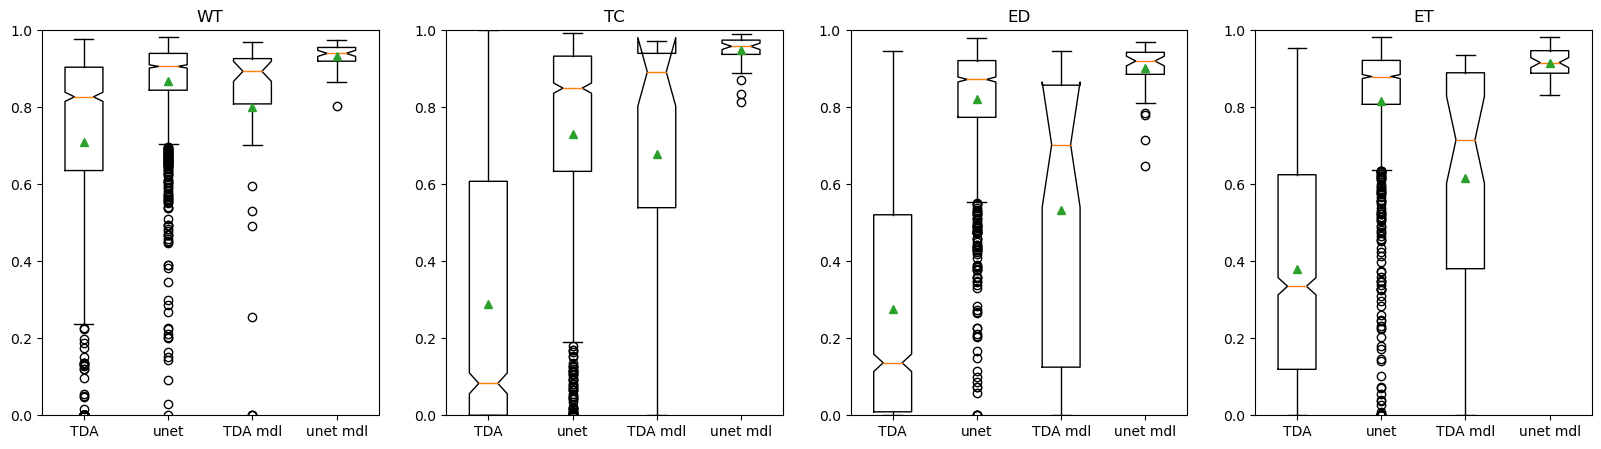

In [575]:
# Boxplots - restricted to indices of df_parameters2

fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(20, 5))

segmentation_labels = ['WT','TC','ED','ET']
for label_i, label in enumerate(segmentation_labels):
    seg_1       = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))
                                     if names[df_parameters1['brats_name'][i]]]
    seg_2       = [df_parameters2.iloc[i][label] for i in range(len(df_parameters2))
                                     if names[df_parameters2['brats_name'][i]]]
    seg_1_model = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))    \
                                     if names[df_parameters1['brats_name'][i]]            \
                                    and names_verify_model[df_parameters1['brats_name'][i]] ]
    seg_2_model = [df_parameters2.iloc[i][label] for i in range(len(df_parameters2))      \
                                     if names[df_parameters2['brats_name'][i]]            \
                                    and names_verify_model[df_parameters2['brats_name'][i]] ]
    
    axs[label_i].boxplot([seg_1,seg_2,seg_1_model,seg_2_model], notch=True, showmeans=True);
    axs[label_i].set_title(label)
    axs[label_i].set_ylim(0,1)
    axs[label_i].set_xticklabels(['TDA','unet', 'TDA mdl', 'unet mdl'])
#     plt.suptitle('old parameters VS new parameters, on whole dataset or restricted to model')

print(len(df_parameters1),len(df_parameters2))
print(len(seg_1),len(seg_2))
print(len(seg_1_model),len(seg_2_model))

1251 1250
1250 1250
332 332


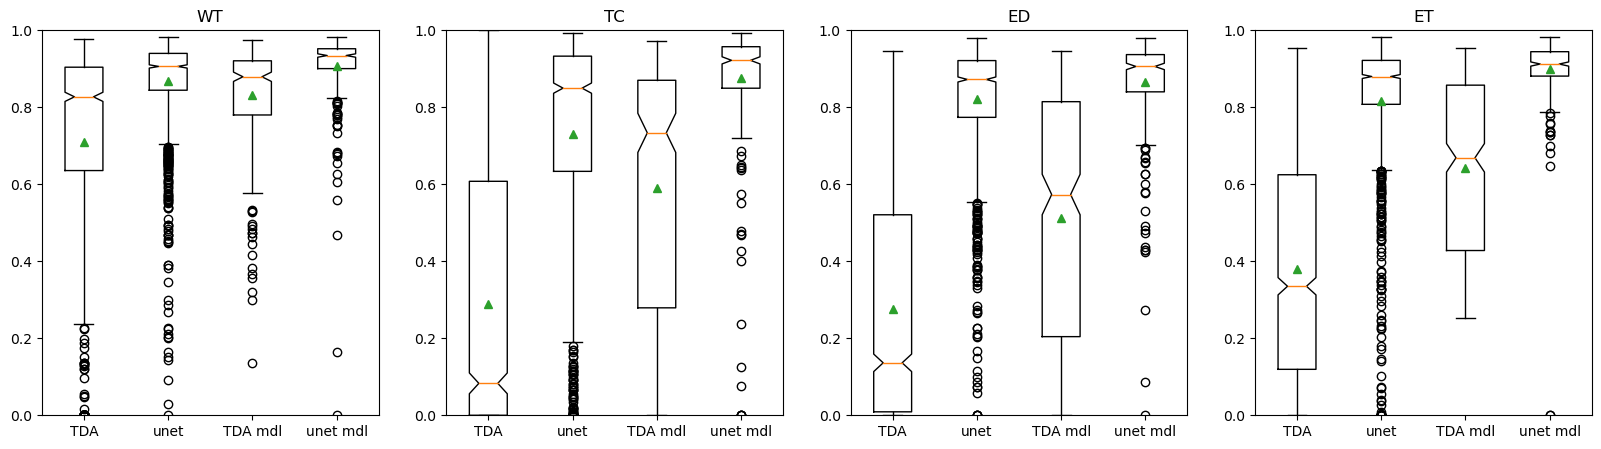

In [373]:
# Boxplots - restricted to indices of df_parameters2

fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(20, 5))

segmentation_labels = ['WT','TC','ED','ET']
for label_i, label in enumerate(segmentation_labels):
    seg_1       = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))
                                     if names[df_parameters1['brats_name'][i]]]
    seg_2       = [df_parameters2.iloc[i][label] for i in range(len(df_parameters2))
                                     if names[df_parameters2['brats_name'][i]]]
    seg_1_model = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))    \
                                     if names[df_parameters1['brats_name'][i]]            \
                                    and names_verify_model[df_parameters1['brats_name'][i]] ]
    seg_2_model = [df_parameters2.iloc[i][label] for i in range(len(df_parameters2))      \
                                     if names[df_parameters2['brats_name'][i]]            \
                                    and names_verify_model[df_parameters2['brats_name'][i]] ]
    
    axs[label_i].boxplot([seg_1,seg_2,seg_1_model,seg_2_model], notch=True, showmeans=True);
    axs[label_i].set_title(label)
    axs[label_i].set_ylim(0,1)
    axs[label_i].set_xticklabels(['TDA','unet', 'TDA mdl', 'unet mdl'])
#     plt.suptitle('old parameters VS new parameters, on whole dataset or restristed to model')

print(len(df_parameters1),len(df_parameters2))
print(len(seg_1),len(seg_2))
print(len(seg_1_model),len(seg_2_model))

1251 1250
1250 1250
256 256


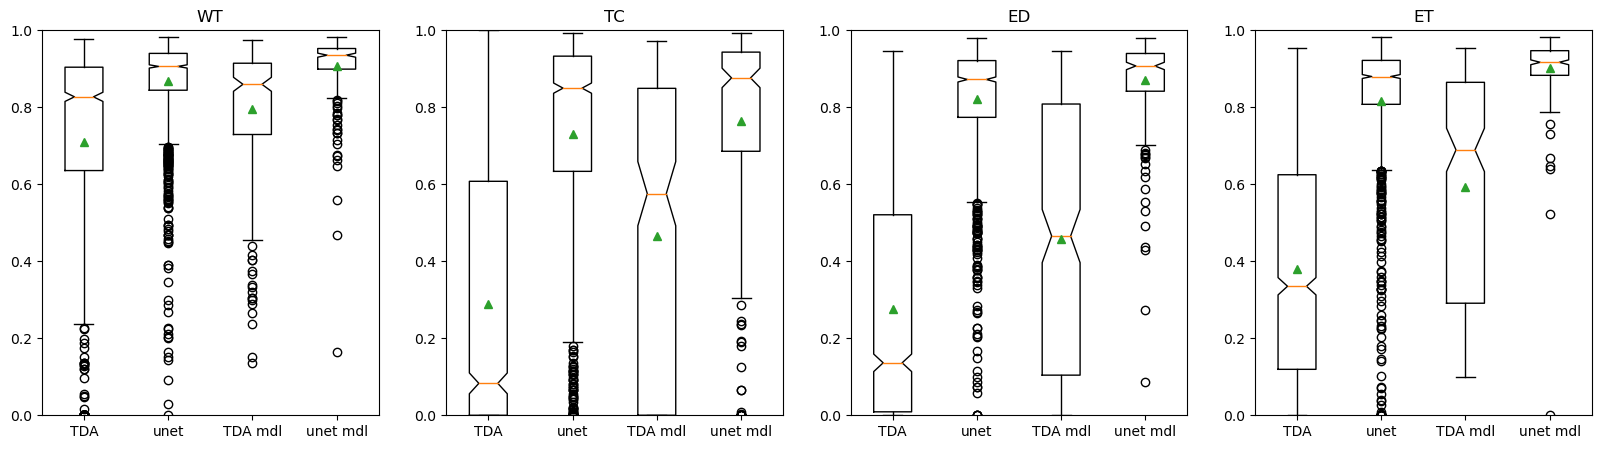

In [349]:
# Boxplots - restricted to indices of df_parameters2

fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(20, 5))

segmentation_labels = ['WT','TC','ED','ET']
for label_i, label in enumerate(segmentation_labels):
    seg_1       = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))
                                     if names[df_parameters1['brats_name'][i]]]
    seg_2       = [df_parameters2.iloc[i][label] for i in range(len(df_parameters2))
                                     if names[df_parameters2['brats_name'][i]]]
    seg_1_model = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))    \
                                     if names[df_parameters1['brats_name'][i]]            \
                                    and names_verify_model[df_parameters1['brats_name'][i]] ]
    seg_2_model = [df_parameters2.iloc[i][label] for i in range(len(df_parameters2))      \
                                     if names[df_parameters2['brats_name'][i]]            \
                                    and names_verify_model[df_parameters2['brats_name'][i]] ]
    
    axs[label_i].boxplot([seg_1,seg_2,seg_1_model,seg_2_model], notch=True, showmeans=True);
    axs[label_i].set_title(label)
    axs[label_i].set_ylim(0,1)
    axs[label_i].set_xticklabels(['TDA','unet', 'TDA mdl', 'unet mdl'])
#     plt.suptitle('old parameters VS new parameters, on whole dataset or restristed to model')

print(len(df_parameters1),len(df_parameters2))
print(len(seg_1),len(seg_2))
print(len(seg_1_model),len(seg_2_model))

In [581]:
df_parameters1.iloc[5:10]

,Unnamed: 0,brats_name,TC,ED,ET,WT
5,5,BraTS2021_01591,0.000000,0.341004,0.119790,0.859226
6,6,BraTS2021_00545,0.007123,0.047752,0.167180,0.742754
7,7,BraTS2021_01266,0.072168,0.004331,0.126156,0.836807
8,8,BraTS2021_01391,0.191990,0.244398,0.300109,0.911499
9,9,BraTS2021_01378,0.961989,0.317899,0.624717,0.939964


In [585]:
df_parameters1.iloc[10:15]

,Unnamed: 0,brats_name,TC,ED,ET,WT
10,10,BraTS2021_01019,0.000000,0.170719,0.180906,0.679256
11,11,BraTS2021_01305,0.163808,0.801478,0.937388,0.944536
12,12,BraTS2021_00207,0.201802,0.848975,0.603443,0.877825
13,13,BraTS2021_00677,0.000000,0.000174,0.000000,0.000140
14,14,BraTS2021_01475,0.246179,0.002976,0.337199,0.924813


# New model (neighbor most luminous pixel)

In [528]:
' Benchmark - Verification of the model '


VerifyModel_neighbor0 = dict()
VerifyModel_neighbor1 = dict()
VerifyModel_neighbor2 = dict()
pb = parse_brats(brats_list=None,brats_folder='2021',modality='flair')
i_list = range(len(pb.brats_list))

msg = 'Verify model... '
start_time = ChronometerStart(msg)
for i in i_list:
    # Open image
    pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
    coords = argmax_image(img_flair)

    h = 0
    VerifyModel_neighbor0[ pb.brats_list[i_list[i]] ] = int(np.max(seg_medecin[max(0,(coords[0]-h)):min(coords[0]+h+1,np.shape(seg_medecin)[0]-1),max(0,(coords[1]-h)):min(coords[1]+h+1,np.shape(seg_medecin)[1]-1),max(0,(coords[2]-h)):min(coords[2]+h+1,np.shape(seg_medecin)[2]-1)]))
    h = 1
    VerifyModel_neighbor1[ pb.brats_list[i_list[i]] ] = int(np.max(seg_medecin[max(0,(coords[0]-h)):min(coords[0]+h+1,np.shape(seg_medecin)[0]-1),max(0,(coords[1]-h)):min(coords[1]+h+1,np.shape(seg_medecin)[1]-1),max(0,(coords[2]-h)):min(coords[2]+h+1,np.shape(seg_medecin)[2]-1)]))
    h = 2
    VerifyModel_neighbor2[ pb.brats_list[i_list[i]] ] = int(np.max(seg_medecin[max(0,(coords[0]-h)):min(coords[0]+h+1,np.shape(seg_medecin)[0]-1),max(0,(coords[1]-h)):min(coords[1]+h+1,np.shape(seg_medecin)[1]-1),max(0,(coords[2]-h)):min(coords[2]+h+1,np.shape(seg_medecin)[2]-1)]))

    ChronometerTick(start_time, i, len(i_list), msg)       

Verify model... It 1251/1251. Duration 0:07:17 Expected remaining time 0:00:00.


In [531]:
VerifyModel_neighbor2

{'BraTS2021_01053': 0,
 'BraTS2021_01159': 2,
 'BraTS2021_00016': 4,
 'BraTS2021_01251': 4,
 'BraTS2021_01143': 4,
 'BraTS2021_01591': 2,
 'BraTS2021_00545': 4,
 'BraTS2021_01266': 0,
 'BraTS2021_01391': 0,
 'BraTS2021_01378': 4,
 'BraTS2021_01019': 0,
 'BraTS2021_01305': 4,
 'BraTS2021_00207': 0,
 'BraTS2021_00677': 0,
 'BraTS2021_01475': 0,
 'BraTS2021_00756': 0,
 'BraTS2021_01106': 0,
 'BraTS2021_01532': 4,
 'BraTS2021_00293': 0,
 'BraTS2021_00668': 2,
 'BraTS2021_00532': 4,
 'BraTS2021_01118': 0,
 'BraTS2021_01188': 0,
 'BraTS2021_00263': 0,
 'BraTS2021_00477': 4,
 'BraTS2021_00211': 4,
 'BraTS2021_00618': 4,
 'BraTS2021_01490': 0,
 'BraTS2021_00201': 4,
 'BraTS2021_01587': 2,
 'BraTS2021_00556': 0,
 'BraTS2021_00140': 0,
 'BraTS2021_00144': 0,
 'BraTS2021_01276': 0,
 'BraTS2021_01372': 4,
 'BraTS2021_01451': 4,
 'BraTS2021_01230': 0,
 'BraTS2021_01461': 4,
 'BraTS2021_01402': 4,
 'BraTS2021_00444': 0,
 'BraTS2021_00130': 0,
 'BraTS2021_00159': 4,
 'BraTS2021_01615': 0,
 'BraTS2021

# New model (ET is a separating circle)

In [352]:
' Benchmark - Verification of the model '

dilatation = 0
do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur

dilatation = 1

VerifyModel = dict()
pb = parse_brats(brats_list=None,brats_folder='2021',modality='flair')
i_list = range(len(pb.brats_list))

msg = 'Verify model... '
start_time = ChronometerStart(msg)
for i in i_list:
    # Open image
    pb, img_flair, img_t1ce, seg_medecin = OpenBRATS(i)
    img_flair, img_t1ce = Preprocess(img_flair,img_t1ce,sigma,normalize,do_enhance)
    seg_TC = (seg_medecin==1)*1 #TC
    seg_ED = (seg_medecin==2)*1 #ED
    seg_ET = (seg_medecin==4)*1 #ET
    seg_WT = (seg_medecin>0)*1  #WT

    # Dilate 
    for i_dilate in range(dilatation): seg_ET = scipy.ndimage.binary_dilation(seg_ET,iterations=1)
    
    # Extract CC
    seg_complement = 1 - seg_ET
    labels = skimage.measure.label(seg_complement, background=0)
    components = [(labels==i)*1 for i in range(1,np.max(labels)+1)]

    # Define ED
    components_len = [np.sum(component) for component in components]
    imax_comp = np.argmax(components_len)
    component_ED = components[imax_comp]*seg_WT
    components.pop(imax_comp);

    # Define TC
    component_TC = np.sum(components,0)

    # Define oracle
    seg_oracle = seg_ET*4 + component_ED*2 +  component_TC*1
    scores = GetDICEs(seg_oracle,seg_medecin,verbose=False)
    
    # Save model
    VerifyModel[ pb.brats_list[i_list[i]] ] = min(scores[1],scores[2])
    ChronometerTick(start_time, i, len(i_list), msg)       
        
# Gather results
df = pd.DataFrame.from_dict(VerifyModel, orient='index')
df.to_csv('results/VerifyModel_separatingcircle_len'+repr(len(df))+'_dilate'+repr(dilatation)+'.csv')

Verify model... It 1251/1251. Duration 1:05:36 Expected remaining time 0:00:00.


In [351]:
VerifyModel

{'BraTS2021_01053': 0.0}

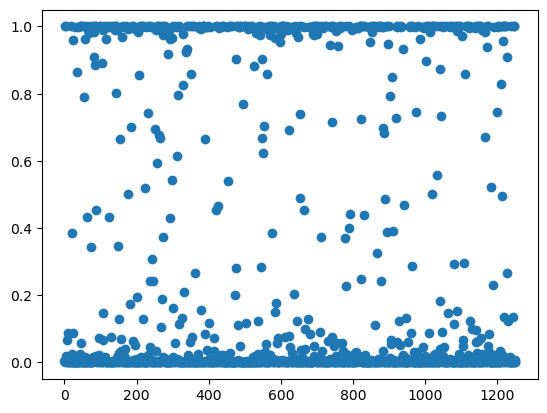

In [268]:
plt.scatter(range(len(VerifyModel)), VerifyModel.values())

# --- OLD ---

# Boxplots - new

### Comparison with unet, old and new model 06/10/2023

Number satisfying model: 19 = 0.02 %


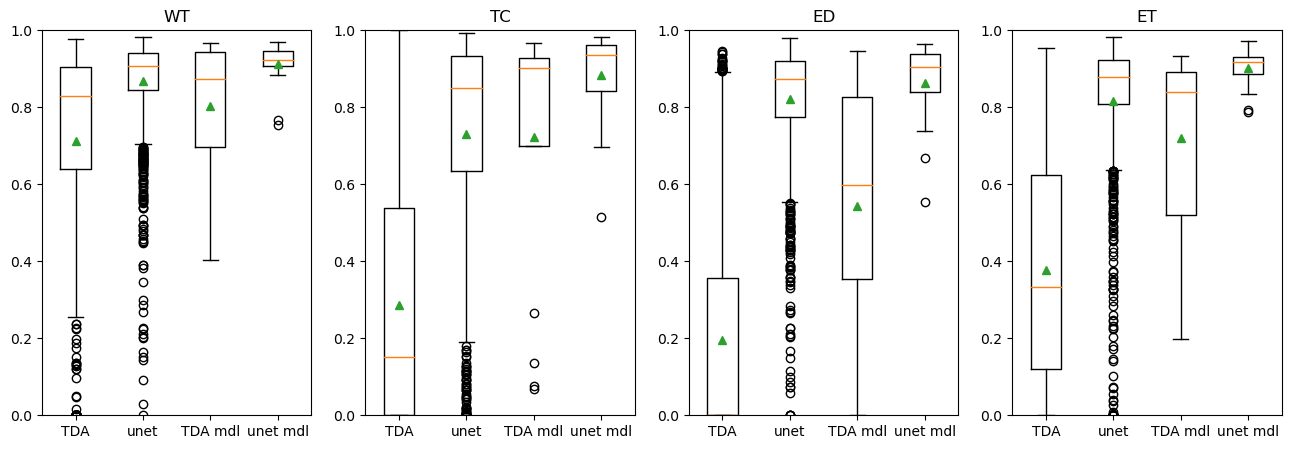

In [211]:
' Compare unet and TDAseg on new model '

# Open dataframes

df_unet = pd.read_csv('results/summary_cmp_unet_pp.csv')
df_VerifyModel = pd.read_csv('results/VerifyModel_dilatation0_len1251_old.csv')

# Get brains verify model
thresh = 0.6
names_verify_model = {name:False for name in df_unet['brats_name']}
for i in range(len(df_VerifyModel)):
    names_verify_model[df_VerifyModel['brats_name'][i]] = \
                       (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>thresh) \
                   and df_VerifyModel['nonempty'][i]==True \
                   and df_VerifyModel['WTconnected'][i]==True \
                   and df_VerifyModel['argmax'][i]==1 #>0
print('Number satisfying model:' , np.sum(list(names_verify_model.values())), '=', round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel),2), '%')

# Boxplots

fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(16, 5))

segmentation_labels = ['WT','TC','ED','ET']
for label_i, label in enumerate(segmentation_labels):
    seg_tda        = [df_unet.iloc[i][label+'_allblur1'] for i in range(len(df_unet))]
    seg_unet       = [df_unet.iloc[i][label+'_unet'] for i in range(len(df_unet))]

    seg_tda_model  = [df_unet.iloc[i][label+'_allblur1'] for i in range(len(df_unet)) 
                                     if names_verify_model[df_unet['brats_name'][i]]]
    seg_unet_model = [df_unet.iloc[i][label+'_unet'] for i in range(len(df_unet))
                                     if names_verify_model[df_unet['brats_name'][i]]]
    
    axs[label_i].boxplot([seg_tda,seg_unet,seg_tda_model,seg_unet_model], notch=False, showmeans=True);
    axs[label_i].set_title(label)
    axs[label_i].set_ylim(0,1)
    axs[label_i].set_xticklabels(['TDA','unet', 'TDA mdl', 'unet mdl'])

### Comparison new model 12/10/2023

Brains satisfying the model: 152 = 12.15 %


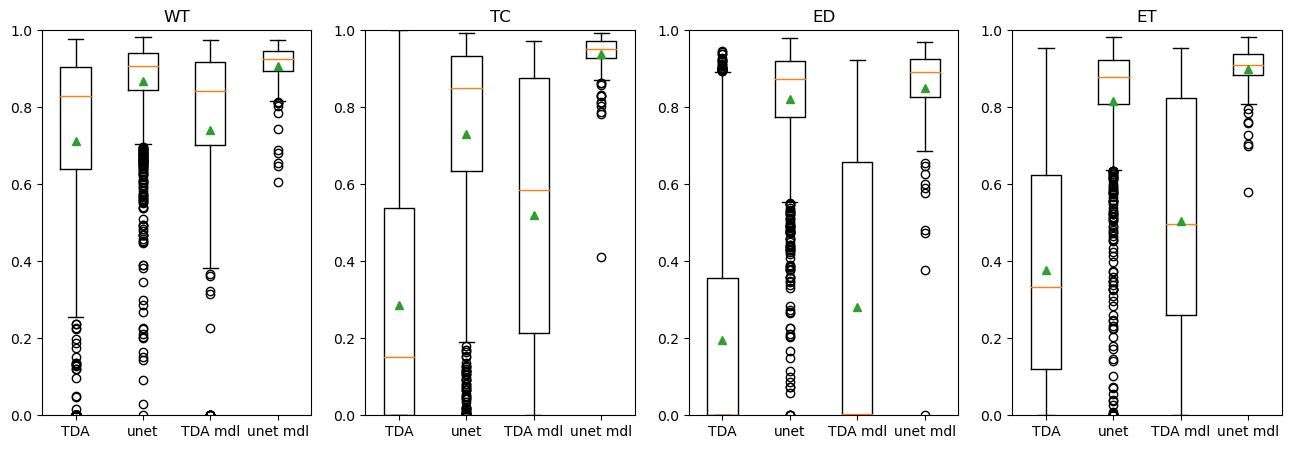

In [154]:
' Compare unet and TDAseg on new model 12/10/2023 '

# Open dataframes
df_unet = pd.read_csv('results/summary_cmp_unet_pp.csv')

# # Get brains verify model
# thresh = 0.6
# df_VerifyModel = pd.read_csv('results/VerifyModel_dilatation0_len1251.csv')
# names_verify_model = {name:False for name in df_unet['brats_name']}
# for i in range(len(df_VerifyModel)):
#     names_verify_model[df_VerifyModel['brats_name'][i]] = \
#                        (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>thresh) \
#                    and df_VerifyModel['nonempty'][i]==True \
#                    and df_VerifyModel['WTconnected'][i]==True \
#                    and df_VerifyModel['argmax'][i]>=1 #>0
# print('Number satisfying model:' , np.sum(list(names_verify_model.values())), '=', round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel),2), '%')

# Get brains verify model - new 12/10/2023
thresh_score = 0.9           # lower bound on the scores
thresh_smallTC = 10           # upper bound on the ratio TC/WT, which should be small. advised: 10
thresh_WTconnected = 10      # lower bound on the ratio first/second largest CC, should be high. advised: 50
admissible_argmax = [1,2,4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT)

df_VerifyModel = pd.read_csv('results/VerifyModel_dilatation1_len1251.csv')
names_verify_model = {name:False for name in df_VerifyModel['brats_name']}
for i in range(len(df_VerifyModel)):
    names_verify_model[df_VerifyModel['brats_name'][i]] =                                              \
                           (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>=thresh_score) \
                       and df_VerifyModel['nonempty'][i]==True                                         \
                       and df_VerifyModel['smallTC'][i]<=thresh_smallTC                                \
                       and df_VerifyModel['WTconnected'][i]>=thresh_WTconnected                        \
                       and df_VerifyModel['argmax'][i] in admissible_argmax
print('Brains satisfying the model:' , np.sum(list(names_verify_model.values())), '=', \
      round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel)*100,3), '%')

# Boxplots

fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(16, 5))

segmentation_labels = ['WT','TC','ED','ET']
for label_i, label in enumerate(segmentation_labels):
    seg_tda        = [df_unet.iloc[i][label+'_allblur1'] for i in range(len(df_unet))]
    seg_unet       = [df_unet.iloc[i][label+'_unet'] for i in range(len(df_unet))]

    seg_tda_model  = [df_unet.iloc[i][label+'_allblur1'] for i in range(len(df_unet)) 
                                     if names_verify_model[df_unet['brats_name'][i]]]
    seg_unet_model = [df_unet.iloc[i][label+'_unet'] for i in range(len(df_unet))
                                     if names_verify_model[df_unet['brats_name'][i]]]
    
    axs[label_i].boxplot([seg_tda,seg_unet,seg_tda_model,seg_unet_model], notch=False, showmeans=True);
    axs[label_i].set_title(label)
    axs[label_i].set_ylim(0,1)
    axs[label_i].set_xticklabels(['TDA','unet', 'TDA mdl', 'unet mdl'])

Found results/TDAseg_scores_[False, 'max', 1, 1, 1, None]_len1251.csv
Number satisfying model: 134 = 0.11 %


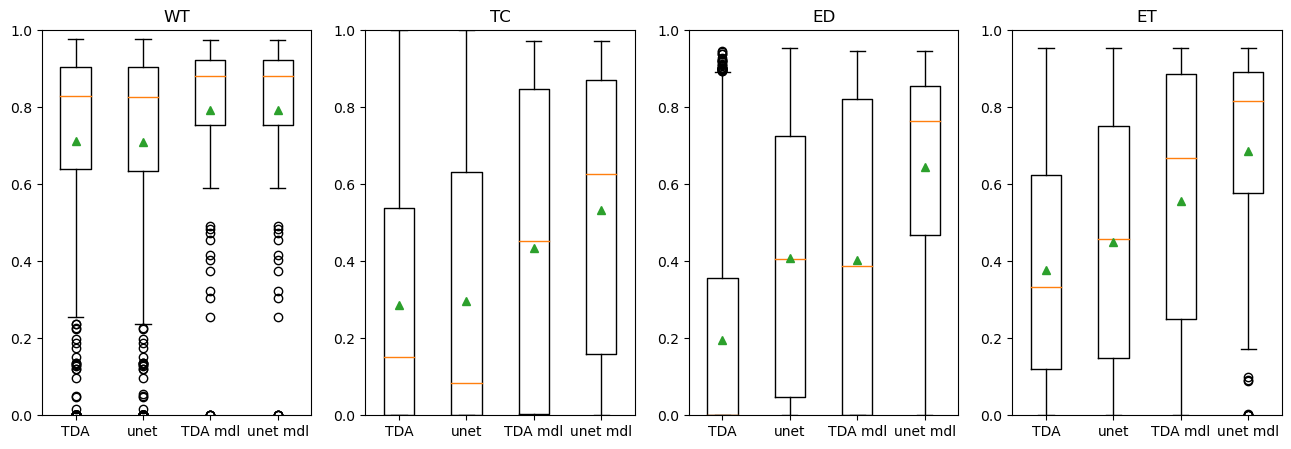

In [157]:
' Compare unet and TDAseg on new model 12/10/2023 and new parameters '

# Open unet dataframe
df_unet = pd.read_csv('results/summary_cmp_unet_pp.csv')

# Open TDAseg dataframe

do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur
dt_threshold = 1       # Step 1, threshold for suggest_t
H2_features_max = 1    # Step 2, number of H2 bars to consider
alpha_boundary = None  # Step 3, parameter to consider inside/outside
parameters = [do_enhance,normalize,sigma,dt_threshold,H2_features_max,alpha_boundary]
files = glob.glob('results/TDAseg_scores_*')
files = [file for file in files if file[0:len('results/TDAseg_scores_')+len(str(parameters))]=='results/TDAseg_scores_'+str(parameters)]
files_length = [int(file[len('results/TDAseg_scores_')+len(str(parameters))+4:-4]) for file in files]
ind = np.argmax(files_length)
file, i_min = files[ind], files_length[ind]
print('Found', file)
df_parameters1 = pd.read_csv(file)

# Get brains verify model
thresh = 0.6
df_VerifyModel = pd.read_csv('results/VerifyModel_dilatation0_len1251.csv')
names_verify_model = {name:False for name in df_unet['brats_name']}
for i in range(len(df_VerifyModel)):
    names_verify_model[df_VerifyModel['brats_name'][i]] = \
                       (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>thresh) \
                   and df_VerifyModel['nonempty'][i]==True \
                   and df_VerifyModel['WTconnected'][i]==True \
                   and df_VerifyModel['argmax'][i]>=1 #>0
print('Number satisfying model:' , np.sum(list(names_verify_model.values())), '=', round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel),2), '%')

# # Get brains verify model - new 12/10/2023
# thresh_score = 0.9           # lower bound on the scores
# thresh_smallTC = 10           # upper bound on the ratio TC/WT, which should be small. advised: 10
# thresh_WTconnected = 10      # lower bound on the ratio first/second largest CC, should be high. advised: 50
# admissible_argmax = [1,2,4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT)

# df_VerifyModel = pd.read_csv('results/VerifyModel_dilatation1_len1251.csv')
# names_verify_model = {name:False for name in df_VerifyModel['brats_name']}
# for i in range(len(df_VerifyModel)):
#     names_verify_model[df_VerifyModel['brats_name'][i]] =                                              \
#                            (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>=thresh_score) \
#                        and df_VerifyModel['nonempty'][i]==True                                         \
#                        and df_VerifyModel['smallTC'][i]<=thresh_smallTC                                \
#                        and df_VerifyModel['WTconnected'][i]>=thresh_WTconnected                        \
#                        and df_VerifyModel['argmax'][i] in admissible_argmax
# print('Brains satisfying the model:' , np.sum(list(names_verify_model.values())), '=', \
#       round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel)*100,3), '%')

# Boxplots

fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(16, 5))

segmentation_labels = ['WT','TC','ED','ET']
for label_i, label in enumerate(segmentation_labels):
    seg_tda        = [df_unet.iloc[i][label+'_allblur1'] for i in range(len(df_unet))]
    seg_unet       = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))]

    seg_tda_model  = [df_unet.iloc[i][label+'_allblur1'] for i in range(len(df_unet)) 
                                     if names_verify_model[df_unet['brats_name'][i]]]
    seg_unet_model = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))
                                     if names_verify_model[df_parameters1['brats_name'][i]]]
    
    axs[label_i].boxplot([seg_tda,seg_unet,seg_tda_model,seg_unet_model], notch=False, showmeans=True);
    axs[label_i].set_title(label)
    axs[label_i].set_ylim(0,1)
    axs[label_i].set_xticklabels(['TDA','unet', 'TDA mdl', 'unet mdl'])

### Comparison of parameters

In [223]:
# Open first dataframe

do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur
dt_threshold = 1       # Step 1, threshold for suggest_t
H2_features_max = 1    # Step 2, number of H2 bars to consider
alpha_boundary = None  # Step 3, parameter to consider inside/outside

parameters = [do_enhance,normalize,sigma,dt_threshold,H2_features_max,alpha_boundary]
files = glob.glob('results/TDAseg_scores_*')
files = [file for file in files if file[0:len('results/TDAseg_scores_')+len(str(parameters))]=='results/TDAseg_scores_'+str(parameters)]
files_length = [int(file[len('results/TDAseg_scores_')+len(str(parameters))+4:-4]) for file in files]
ind = np.argmax(files_length)
file, i_min = files[ind], files_length[ind]
print('Found', file)
df_parameters1 = pd.read_csv(file)

Found results/TDAseg_scores_[False, 'max', 1, 1, 1, None]_len1251.csv


In [158]:
# Open second dataframe

# do_enhance = False     # Preprocess, apply enhancement or not
do_enhance = [False,True]     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur
dt_threshold = 1       # Step 1, threshold for suggest_t
H2_features_max = 1    # Step 2, number of H2 bars to consider
alpha_boundary = None  # Step 3, parameter to consider inside/outside

parameters = [do_enhance,normalize,sigma,dt_threshold,H2_features_max,alpha_boundary]
files = glob.glob('results/TDAseg_scores_*')
files = [file for file in files if file[0:len('results/TDAseg_scores_')+len(str(parameters))]=='results/TDAseg_scores_'+str(parameters)]
files_length = [int(file[len('results/TDAseg_scores_')+len(str(parameters))+4:-4]) for file in files]
ind = np.argmax(files_length)
file, i_min = files[ind], files_length[ind]
print('Found', file)
df_parameters2 = pd.read_csv(file)

# Get names step3
names = {name:False for name in df_parameters1['brats_name']}
for i in range(len(df_parameters2)): names[df_parameters2['brats_name'][i]] = True

Found results/TDAseg_scores_[[False, True], 'max', 1, 1, 1, None]_len512.csv


In [224]:
# Open second dataframe

do_enhance = False     # Preprocess, apply enhancement or not
# do_enhance = [False,True]     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur
dt_threshold = 1       # Step 1, threshold for suggest_t
H2_features_max = 5    # Step 2, number of H2 bars to consider
alpha_boundary = None  # Step 3, parameter to consider inside/outside

parameters = [do_enhance,normalize,sigma,dt_threshold,H2_features_max,alpha_boundary]
files = glob.glob('results/TDAseg_scores_*')
files = [file for file in files if file[0:len('results/TDAseg_scores_')+len(str(parameters))]=='results/TDAseg_scores_'+str(parameters)]
files_length = [int(file[len('results/TDAseg_scores_')+len(str(parameters))+4:-4]) for file in files]
ind = np.argmax(files_length)
file, i_min = files[ind], files_length[ind]
print('Found', file)
df_parameters2 = pd.read_csv(file)

# Get names step3
names = {name:False for name in df_parameters1['brats_name']}
for i in range(len(df_parameters2)): names[df_parameters2['brats_name'][i]] = True

Found results/TDAseg_scores_[False, 'max', 1, 1, 5, None]_len1251.csv


In [225]:
# Get brains verify model - old

df_unet = pd.read_csv('results/summary_cmp_unet_pp.csv')
names_verify_model = {df_unet['brats_name'][i]:df_unet['verify_model'][i] for i in range(len(df_unet))}
names_verify_model['BraTS2021_00789'] = False
print('Brains satisfying the model:' , np.sum(list(names_verify_model.values())), '=', round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel)*100,3), '%')

Brains satisfying the model: 119 = 9.512 %


In [227]:
# Get brains verify model - new 06/10/2023
thresh = 0.8
df_VerifyModel = pd.read_csv('results/VerifyModel_dilatation0_len1251_old.csv')
names_verify_model = {name:False for name in df_VerifyModel['brats_name']}
for i in range(len(df_VerifyModel)):
    names_verify_model[df_VerifyModel['brats_name'][i]] = \
                       (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>thresh) \
                   and df_VerifyModel['nonempty'][i]==True \
                   and df_VerifyModel['WTconnected'][i]==True \
                   and df_VerifyModel['argmax'][i]>=1 #>0
print('Brains satisfying the model:' , np.sum(list(names_verify_model.values())), '=', round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel)*100,3), '%')

Brains satisfying the model: 122 = 9.752 %


In [217]:
# Get brains verify model - new 12/10/ - 0 dilatation

thresh_score = 0.9           # lower bound on the scores
thresh_smallTC = 50          # upper bound on the ratio WT/TC, which should be small
thresh_WTconnected = 10      # lower bound on the ratio first/second largest CC, should be high
admissible_argmax = [1,2,4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT)
# admissible_argmax = [1]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT)

df_VerifyModel = pd.read_csv('results/VerifyModel_dilatation0_len1251.csv')
names_verify_model = {name:False for name in df_VerifyModel['brats_name']}
for i in range(len(df_VerifyModel)):
    names_verify_model[df_VerifyModel['brats_name'][i]] =                                             \
                           (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>thresh_score) \
                       and df_VerifyModel['nonempty'][i]==True                                        \
                       and df_VerifyModel['smallTC'][i]<=thresh_smallTC                               \
                       and df_VerifyModel['WTconnected'][i]>=thresh_WTconnected                       \
                       and df_VerifyModel['argmax'][i] in admissible_argmax

print('Brains satisfying the model:' , np.sum(list(names_verify_model.values())), '=', \
      round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel)*100,3), '%')

Brains satisfying the model: 145 = 11.591 %


In [229]:
# Get brains verify model - new 12/10/2023 - 1 dilatation

thresh_score = 0.9           # lower bound on the scores
thresh_smallTC = 50          # upper bound on the ratio WT/TC, which should be small
thresh_WTconnected = 10      # lower bound on the ratio first/second largest CC, should be high
admissible_argmax = [1,2,4]  # seg values that argmax can take ([1] for TC, [1,2,4] for WT)

df_VerifyModel = pd.read_csv('results/VerifyModel_dilatation1_len1251.csv')
names_verify_model = {name:False for name in df_VerifyModel['brats_name']}
for i in range(len(df_VerifyModel)):
    names_verify_model[df_VerifyModel['brats_name'][i]] =                                             \
                           (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>thresh_score) \
                       and df_VerifyModel['nonempty'][i]==True                                        \
                       and df_VerifyModel['smallTC'][i]<=thresh_smallTC                               \
                       and df_VerifyModel['WTconnected'][i]>=thresh_WTconnected                       \
                       and df_VerifyModel['argmax'][i] in admissible_argmax

print('Brains satisfying the model:' , np.sum(list(names_verify_model.values())), '=', \
      round(np.sum(list(names_verify_model.values()))/len(df_VerifyModel)*100,3), '%')

Brains satisfying the model: 363 = 29.017 %


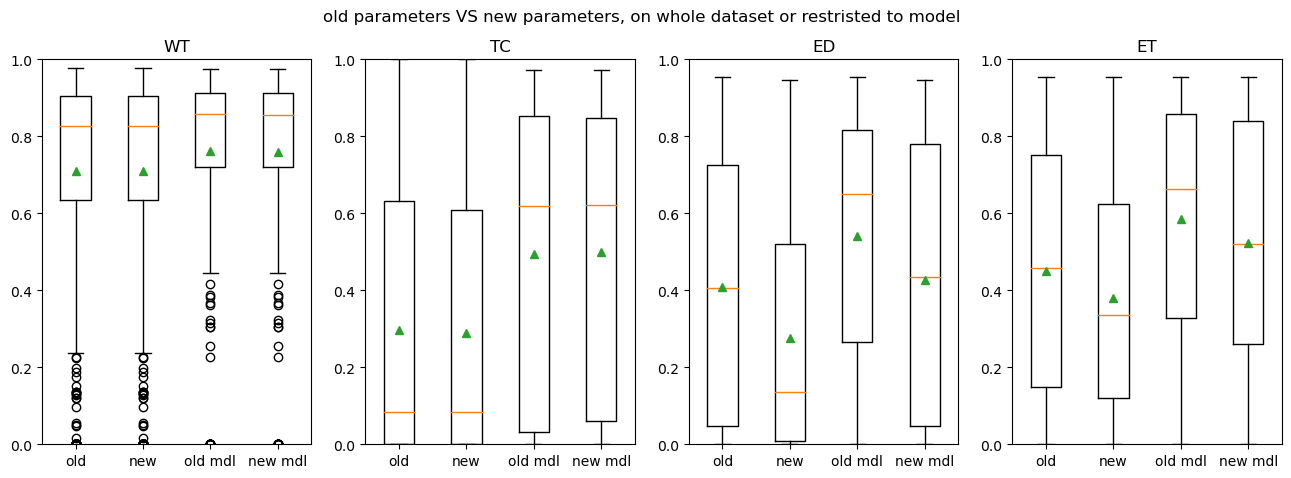

In [230]:
# Boxplots

fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(16, 5))

segmentation_labels = ['WT','TC','ED','ET']
for label_i, label in enumerate(segmentation_labels):
    seg_1       = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))
                                     if names[df_parameters1['brats_name'][i]]]
    seg_2       = [df_parameters2.iloc[i][label] for i in range(len(df_parameters2))
                                     if names[df_parameters2['brats_name'][i]]]
    seg_1_model = [df_parameters1.iloc[i][label] for i in range(len(df_parameters1))    \
                                     if names[df_parameters1['brats_name'][i]]            \
                                    and names_verify_model[df_parameters1['brats_name'][i]] ]
    seg_2_model = [df_parameters2.iloc[i][label] for i in range(len(df_parameters2))      \
                                     if names[df_parameters2['brats_name'][i]]            \
                                    and names_verify_model[df_parameters2['brats_name'][i]] ]
    
    axs[label_i].boxplot([seg_1,seg_2,seg_1_model,seg_2_model], notch=False, showmeans=True);
    axs[label_i].set_title(label)
    axs[label_i].set_ylim(0,1)
    axs[label_i].set_xticklabels(['old','new', 'old mdl', 'new mdl'])
    plt.suptitle('old parameters VS new parameters, on whole dataset or restristed to model')

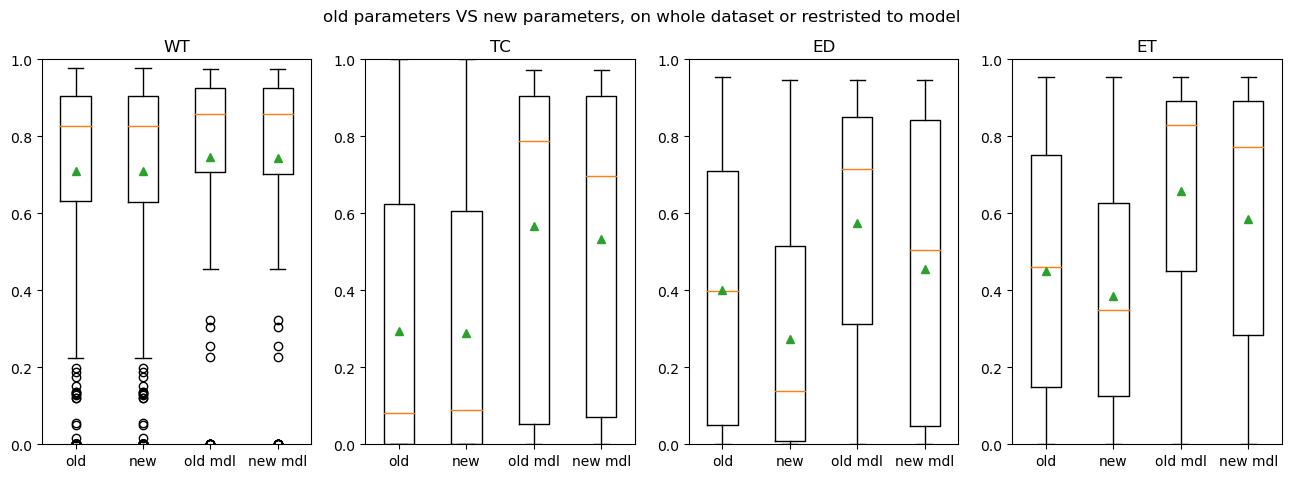

In [218]:
# Boxplots - restricted to indices of df_parameters2

fig, axs = plt.subplots(ncols=4, nrows=1, figsize=(16, 5))

segmentation_labels = ['WT','TC','ED','ET']
for label_i, label in enumerate(segmentation_labels):
    seg_1       = [df_parameters1.iloc[i][label] for i in range(len(df_parameters2))
                                     if names[df_parameters2['brats_name'][i]]]
    seg_2       = [df_parameters2.iloc[i][label] for i in range(len(df_parameters2))
                                     if names[df_parameters2['brats_name'][i]]]
    seg_1_model = [df_parameters1.iloc[i][label] for i in range(len(df_parameters2))    \
                                     if names[df_parameters2['brats_name'][i]]            \
                                    and names_verify_model[df_parameters2['brats_name'][i]] ]
    seg_2_model = [df_parameters2.iloc[i][label] for i in range(len(df_parameters2))      \
                                     if names[df_parameters2['brats_name'][i]]            \
                                    and names_verify_model[df_parameters2['brats_name'][i]] ]
    
    axs[label_i].boxplot([seg_1,seg_2,seg_1_model,seg_2_model], notch=False, showmeans=True);
    axs[label_i].set_title(label)
    axs[label_i].set_ylim(0,1)
    axs[label_i].set_xticklabels(['old','new', 'old mdl', 'new mdl'])
    plt.suptitle('old parameters VS new parameters, on whole dataset or restristed to model')

# Study model

In [298]:
# Get brains verify model

thresh = 0.6
names_verify_model = {name:False for name in df_unet['brats_name']}
for i in range(len(df_VerifyModel)):
    names_verify_model[df_VerifyModel['brats_name'][i]] = \
                       (min(ast.literal_eval(df_VerifyModel['scores'][i]).values())>thresh) \
                   and df_VerifyModel['nonempty'][i]==True \
                   and df_VerifyModel['WTconnected'][i]==True \
                   and df_VerifyModel['argmax'][i]==1 #>0
names_model = [name for name in names_verify_model if names_verify_model[name]==True]
print('Number satisfying model:' , len(names_model))

# Open dataframe scores

do_enhance = False     # Preprocess, apply enhancement or not
normalize= 'max'       # Preprocess, divide by max or 255
sigma = 1              # Preprocess, Gaussian blur
dt_threshold = 1       # Step 1, threshold for suggest_t
H2_features_max = 1    # Step 2, number of H2 bars to consider
alpha_boundary = None  # Step 3, parameter to consider inside/outside
parameters = [do_enhance,normalize,sigma,dt_threshold,H2_features_max,alpha_boundary]
files = glob.glob('results/TDAseg_scores_*')
files = [file for file in files if file[0:len('results/TDAseg_scores_')+len(str(parameters))]=='results/TDAseg_scores_'+str(parameters)]
files_length = [int(file[len('results/TDAseg_scores_')+len(str(parameters))+4:-4]) for file in files]
ind = np.argmax(files_length)
file, i_min = files[ind], files_length[ind]
print('Found', file)
df_step3 = pd.read_csv(file)

thresh_TDA = 0.5
names_TDA = [df_step3['brats_name'][i] for i in range(len(df_step3)) if \
                     min(df_step3.loc[i,['WT','TC','ED','ET']])>thresh_TDA ]
print('Number with good scores:' , len(names_TDA))

# In model and good score
names_common = set(names_TDA).intersection(names_model)
print('In model and good score:', len(names_common))
print(names_common)

# Good score, but not in model
names_onlyscore = set(names_TDA).difference(names_model)
print('Good score, but not in model:', len(names_onlyscore))
print(names_onlyscore)

# In model, but bad score
names_onlymodel = set(names_model).difference(names_TDA)
print('In model, but bad score:', len(names_onlymodel))
print(names_onlymodel)

Number satisfying model: 19
Found results/TDAseg_scores_[False, 'max', 1, 1, 1, None]_len718.csv
Number with good scores: 125
In model and good score: 8
{'BraTS2021_01028', 'BraTS2021_00058', 'BraTS2021_01001', 'BraTS2021_00300', 'BraTS2021_01564', 'BraTS2021_00020', 'BraTS2021_01321', 'BraTS2021_01134'}
Good score, but not in model: 116
{'BraTS2021_01362', 'BraTS2021_01092', 'BraTS2021_00349', 'BraTS2021_01307', 'BraTS2021_01389', 'BraTS2021_01029', 'BraTS2021_00834', 'BraTS2021_00343', 'BraTS2021_00132', 'BraTS2021_00100', 'BraTS2021_00403', 'BraTS2021_01312', 'BraTS2021_00433', 'BraTS2021_01286', 'BraTS2021_01577', 'BraTS2021_00104', 'BraTS2021_00830', 'BraTS2021_00192', 'BraTS2021_00195', 'BraTS2021_01073', 'BraTS2021_00217', 'BraTS2021_00096', 'BraTS2021_01005', 'BraTS2021_01323', 'BraTS2021_01024', 'BraTS2021_00376', 'BraTS2021_00051', 'BraTS2021_00426', 'BraTS2021_01337', 'BraTS2021_01465', 'BraTS2021_00191', 'BraTS2021_00267', 'BraTS2021_01401', 'BraTS2021_01119', 'BraTS2021_00